#WAV2VEC 2.0 on Da_Audio data set

Install and imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


Copy data

In [ ]:
drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    print("Copying data from Drive to local storage...")
    shutil.copytree(drive_path, local_path)
    print("Data copied!")
else:
    print("Data already exists locally")

train_path = os.path.join(local_path, "train")
val_path = os.path.join(local_path, "validation")
test_path = os.path.join(local_path, "test")

for split, path in [("Train", train_path), ("Val", val_path), ("Test", test_path)]:
    real_count = len([f for f in os.listdir(os.path.join(path, f"real_{split.lower()}_audio")) if f.endswith('.wav')])
    fake_count = len([f for f in os.listdir(os.path.join(path, f"fake_{split.lower()}_audio")) if f.endswith('.wav')])
    print(f"{split}: {real_count} real + {fake_count} fake = {real_count + fake_count} total")

Copying data from Drive to local storage...
Data copied!
Train: 5405 real + 5405 fake = 10810 total
Val: 1088 real + 1088 fake = 2176 total
Test: 1100 real + 1100 fake = 2200 total


Load Wav2Vec feature extractor

In [ ]:
model_name = "facebook/wav2vec2-large-xlsr-53"

print(f"Loading Wav2Vec 2.0 feature extractor from {model_name}...")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

print("Feature extractor loaded!")
print(f"   Sampling rate: {feature_extractor.sampling_rate}")
print(f"   Model: Wav2Vec 2.0 XLSR-53 (Multilingual, 317M parameters)")

Loading Wav2Vec 2.0 feature extractor from facebook/wav2vec2-large-xlsr-53...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Feature extractor loaded!
   Sampling rate: 16000
   Model: Wav2Vec 2.0 XLSR-53 (Multilingual, 317M parameters)


Dataset class

In [ ]:
class DanishDeepfakeDataset(Dataset):
    def __init__(self, data_path, split_name, feature_extractor, max_samples=None):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 10

        real_dir = os.path.join(data_path, f"real_{split_name}_audio")
        fake_dir = os.path.join(data_path, f"fake_{split_name}_audio")

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')]

        self.file_paths = real_files + fake_files
        self.labels = [1] * len(real_files) + [0] * len(fake_files)

        if max_samples:
            indices = np.random.choice(len(self.file_paths), min(max_samples, len(self.file_paths)), replace=False)
            self.file_paths = [self.file_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

        print(f"   Loaded {len(self.file_paths)} samples ({sum(self.labels)} real, {len(self.labels) - sum(self.labels)} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class defined!")

Dataset class defined!


Create datasets

In [ ]:
train_dataset = DanishDeepfakeDataset(train_path, "train", feature_extractor)
val_dataset = DanishDeepfakeDataset(val_path, "val", feature_extractor)
test_dataset = DanishDeepfakeDataset(test_path, "test", feature_extractor)

print(f"\nDatasets created!")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

   Loaded 10810 samples (5405 real, 5405 fake)
   Loaded 2176 samples (1088 real, 1088 fake)
   Loaded 2200 samples (1100 real, 1100 fake)

Datasets created!
   Train: 10810 samples
   Val:   2176 samples
   Test:  2200 samples


Load model

In [ ]:
print(f"\nLoading Wav2Vec 2.0 model from {model_name}...")

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("Model loaded!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


Loading Wav2Vec 2.0 model from facebook/wav2vec2-large-xlsr-53...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
   Parameters: 315,701,634


Compute metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )

    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    auc = roc_auc_score(labels, probs)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

print("Metrics function defined!")

Metrics function defined!


Training arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/wav2vec_danish_deepfake",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

Train

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("\n" + "="*70)
print("TRAINING WAV2VEC 2.0 ON DANISH DATA")
print("="*70)

trainer.train()

print("\nTraining complete!")

trainer.save_model("/content/drive/MyDrive/wav2vec_danish_deepfake_best")
print("Best model saved to Drive!")


TRAINING WAV2VEC 2.0 ON DANISH DATA


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.024927,0.000090,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.049885,0.000022,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.006942,0.000008,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.090804,0.001410,0.999081,0.998165,1.000000,0.999082,1.000000
5,0.000050,0.000003,1.000000,1.000000,1.000000,1.000000,1.000000
6,0.000025,0.000002,1.000000,1.000000,1.000000,1.000000,1.000000
7,0.024444,0.001223,0.999081,1.000000,0.998162,0.999080,1.000000
8,0.000027,0.000001,1.000000,1.000000,1.000000,1.000000,1.000000
9,0.000007,0.000001,1.000000,1.000000,1.000000,1.000000,1.000000
10,0.000022,0.000001,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to Drive!


Evaluation

In [ ]:
def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

print("\n" + "="*70)
print("EVALUATING WAV2VEC ON DANISH TEST SET")
print("="*70)

test_results = trainer.predict(test_dataset)
logits = test_results.predictions
y_test = test_results.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_prob = probs[:, 1]
y_pred = np.argmax(logits, axis=-1)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
eer = equal_error_rate(y_test, y_prob)
mean_acc, ci_low, ci_high = bootstrap_ci(y_test, y_prob)

print("\n" + "="*70)
print("=== Wav2Vec 2.0 Model - Danish Test Results ===")
print("="*70)
print(f"\nAccuracy:  {acc:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"EER:       {eer:.4f}")
print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

print("\n" + classification_report(y_test, y_pred, target_names=['Fake', 'Real'], digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\n" + "="*70)
print("CONFUSION MATRIX:")
print("="*70)
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Real   {cm[1,0]:<6}  {cm[1,1]:<6}")


EVALUATING WAV2VEC ON DANISH TEST SET



=== Wav2Vec 2.0 Model - Danish Test Results ===

Accuracy:  0.9973
Recall:    1.0000
Precision: 0.9946
F1-score:  0.9973
AUC-ROC:   0.9993
EER:       0.0027
Bootstrap: 0.9973 [0.9950, 0.9991]

              precision    recall  f1-score   support

        Fake     1.0000    0.9945    0.9973      1100
        Real     0.9946    1.0000    0.9973      1100

    accuracy                         0.9973      2200
   macro avg     0.9973    0.9973    0.9973      2200
weighted avg     0.9973    0.9973    0.9973      2200


CONFUSION MATRIX:
                Predicted
              Fake    Real
Actual Fake   1094    6     
       Real   0       1100  


#Validity checks on Da_Audio

##Basis validation

Mount drive and copy dataset locally

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    print("Copying data...")
    shutil.copytree(drive_path, local_path)
    print("Done!")
else:
    print("Data already exists!")

train_path = os.path.join(local_path, "train")
val_path = os.path.join(local_path, "validation")
test_path = os.path.join(local_path, "test")

Copying data...
Done!


Load pre-trained Wav2Vec2 model

In [ ]:
model_name = "facebook/wav2vec2-large-xlsr-53"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Create datasets that pad/truncate all audio to exactly 10 seconds

In [ ]:
class DanishDeepfakeDataset(Dataset):
    def __init__(self, data_path, split_name, feature_extractor, max_samples=None):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 10

        real_dir = os.path.join(data_path, f"real_{split_name}_audio")
        fake_dir = os.path.join(data_path, f"fake_{split_name}_audio")

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')]

        self.file_paths = real_files + fake_files
        self.labels = [1] * len(real_files) + [0] * len(fake_files)

        if max_samples:
            indices = np.random.choice(len(self.file_paths), min(max_samples, len(self.file_paths)), replace=False)
            self.file_paths = [self.file_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

        print(f"   Loaded {len(self.file_paths)} samples ({sum(self.labels)} real, {len(self.labels) - sum(self.labels)} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
train_dataset = DanishDeepfakeDataset(train_path, "train", feature_extractor)
val_dataset = DanishDeepfakeDataset(val_path, "val", feature_extractor)
test_dataset = DanishDeepfakeDataset(test_path, "test", feature_extractor)

   Loaded 10810 samples (5405 real, 5405 fake)
   Loaded 2176 samples (1088 real, 1088 fake)
   Loaded 2200 samples (1100 real, 1100 fake)


Load model

In [ ]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/wav2vec_danish_deepfake_best"
)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Parameters: 315,701,634


Setup evaluation

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    auc = roc_auc_score(labels, probs)
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc}

training_args = TrainingArguments(
    output_dir="/content/wav2vec_temp",
    per_device_eval_batch_size=8,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
)

Tests

In [ ]:
print("="*70)
print("RUNNING VALIDATION TESTS ON 99.73% RESULT")
print("="*70)

test_results = trainer.predict(test_dataset)
logits = test_results.predictions
y_test = test_results.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_prob = probs[:, 1]
y_pred = np.argmax(logits, axis=-1)

acc = accuracy_score(y_test, y_pred)
print(f"\nReproduced accuracy: {acc:.4f}")

print("\n" + "="*70)
print("TEST 1: DATA LEAKAGE CHECK")
print("="*70)
train_files = set([os.path.basename(f) for f in train_dataset.file_paths])
test_files = set([os.path.basename(f) for f in test_dataset.file_paths])
overlap = train_files.intersection(test_files)

print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")
print(f"Overlap: {len(overlap)}")

if len(overlap) > 0:
    print("\nCRITICAL: DATA LEAKAGE!")
    print("First 10 overlapping:")
    for f in list(overlap)[:10]:
        print(f"  {f}")
else:
    print("\nNo overlap - clean!")

print("\n" + "="*70)
print("TEST 2: LABEL ENCODING")
print("="*70)
import random
indices = random.sample(range(len(test_dataset)), 10)
all_correct = True
for i in indices:
    filepath = test_dataset.file_paths[i]
    label = test_dataset.labels[i]
    is_real_file = 'real_test_audio' in filepath
    is_real_label = label == 1
    match = '' if is_real_file == is_real_label else ''
    if not (is_real_file == is_real_label):
        all_correct = False
    print(f"{match} {os.path.basename(filepath)}: label={label}")

print(f"\n{'Labels correct!' if all_correct else 'LABEL MISMATCH!'}")

print("\n" + "="*70)
print("TEST 3: TEST SET IDENTITY")
print("="*70)
print(f"Test path: {test_path}")
fake_files = [f for f in test_dataset.file_paths if 'fake' in f]
print(f"\nFirst 5 fake test files:")
for f in fake_files[:5]:
    print(f"  {os.path.basename(f)}")

print("\n" + "="*70)
print("TEST 4: PREDICTIONS DISTRIBUTION")
print("="*70)
print(f"Mean prob: {y_prob.mean():.4f}")
print(f"Std prob: {y_prob.std():.4f}")
high_conf = ((y_prob > 0.9) | (y_prob < 0.1)).sum()
print(f"High confidence: {high_conf}/{len(y_prob)} ({high_conf/len(y_prob)*100:.1f}%)")

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)

RUNNING VALIDATION TESTS ON 99.73% RESULT



Reproduced accuracy: 0.9973

TEST 1: DATA LEAKAGE CHECK
Train files: 10810
Test files: 2200
Overlap: 0

No overlap - clean!

TEST 2: LABEL ENCODING
 eaa341af-6be3-4388-9198-e56a64beb303.wav: label=1
 dbc62e03-29ba-49c4-ad84-9c8024fc38fd.wav: label=1
 mathilde_238_701.wav: label=0
 1996ade0-1de3-40ab-9afa-c36b32057a15.wav: label=1
 755f85cd-da63-4ecb-83bd-ca76c9d77985.wav: label=1
 f51b48f4-5509-4236-bc21-194418069ab4.wav: label=1
 a5bdf913-a78b-4a79-ae82-9101639036fc.wav: label=1
 21b144d4-d42b-4e0f-8359-e2d547a83113.wav: label=1
 ask_427_1059.wav: label=0
 c518b940-7574-4593-b322-2c683fb8d380.wav: label=1

Labels correct!

TEST 3: TEST SET IDENTITY
Test path: /content/da_audio/test

First 5 fake test files:
  ida_90_85.wav
  clara_41_223.wav
  emil_190_789.wav
  martin_121_694.wav
  clara_163_535.wav

TEST 4: PREDICTIONS DISTRIBUTION
Mean prob: 0.5027
Std prob: 0.4999
High confidence: 2200/2200 (100.0%)

VALIDATION COMPLETE!


Audio length distribution analysis


AUDIO LENGTH DISTRIBUTION ANALYSIS

Analyzing test set audio lengths (this may take a minute)...
  Processed 200/2200 samples...
  Processed 400/2200 samples...
  Processed 600/2200 samples...
  Processed 800/2200 samples...
  Processed 1000/2200 samples...
  Processed 1200/2200 samples...
  Processed 1400/2200 samples...
  Processed 1600/2200 samples...
  Processed 1800/2200 samples...
  Processed 2000/2200 samples...
  Processed 2200/2200 samples...

STATISTICS:

Real samples (n=1100):
  Mean:   12.10s
  Median: 11.79s
  Std:    3.56s
  Min:    3.69s
  Max:    31.34s
  < 10s:  268 (24.4%)
  > 10s:  831 (75.5%)

Fake samples (n=1100):
  Mean:   12.49s
  Median: 12.32s
  Std:    3.08s
  Min:    3.60s
  Max:    20.00s
  < 10s:  196 (17.8%)
  > 10s:  894 (81.3%)

STATISTICAL TEST:
T-test comparing Real vs Fake lengths:
  t-statistic: -2.7494
  p-value:     0.006020

No significant difference - both classes have similar lengths


/tmp/ipykernel_7873/2628225918.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([real_lengths, fake_lengths], labels=['Real', 'Fake'], patch_artist=True)


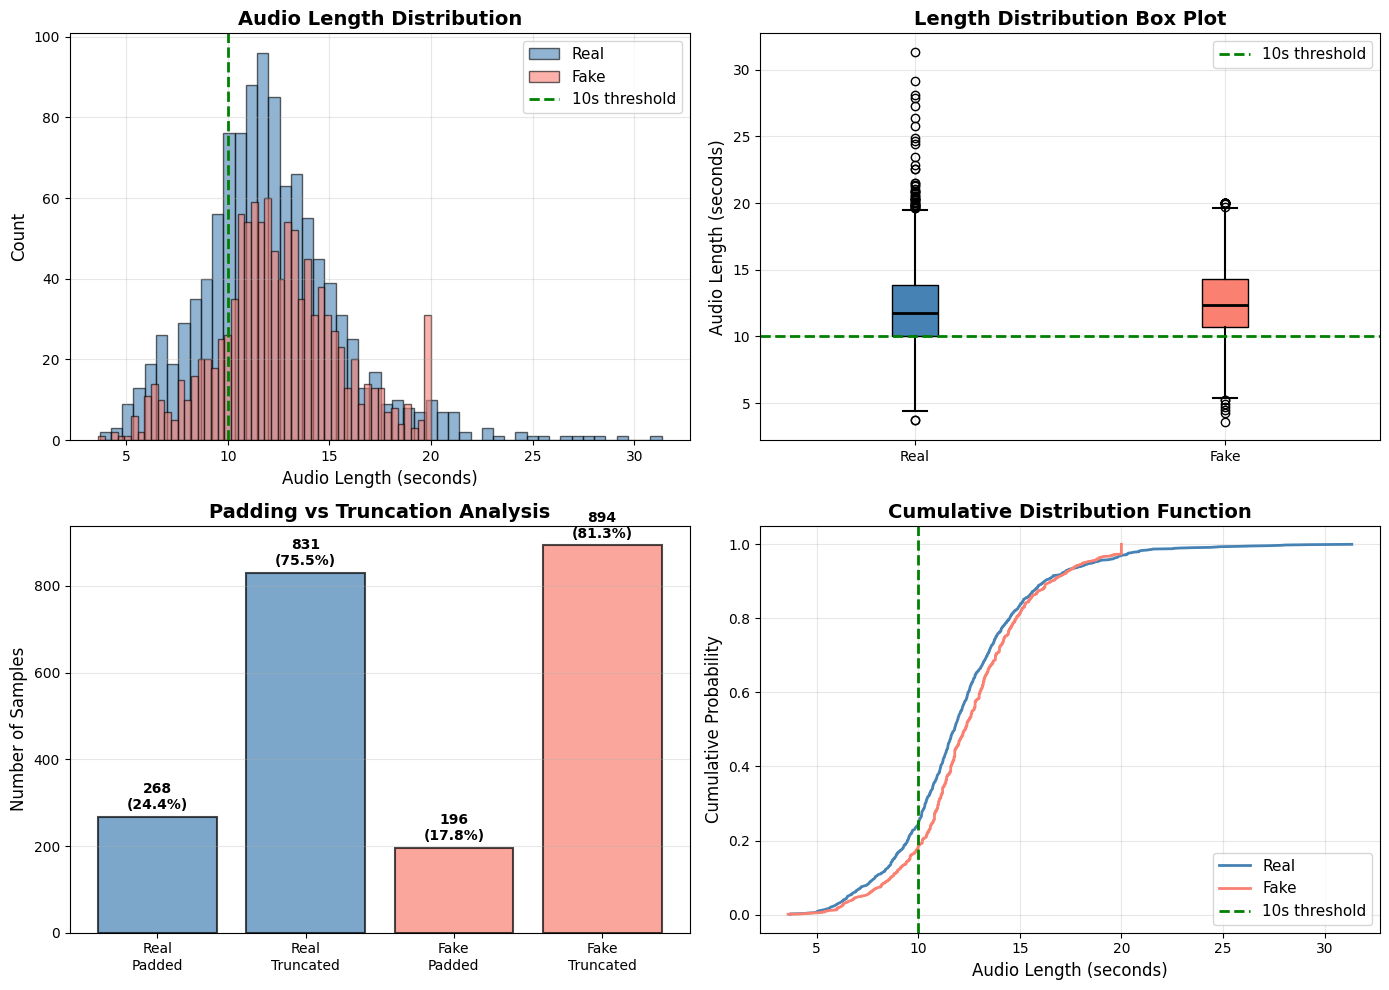


Visualization saved to Drive: audio_length_analysis.png


In [ ]:
from scipy import stats

print("\n" + "="*70)
print("AUDIO LENGTH DISTRIBUTION ANALYSIS")
print("="*70)

real_lengths = []
fake_lengths = []

print("\nAnalyzing test set audio lengths (this may take a minute)...")
for i in range(len(test_dataset)):
    filepath = test_dataset.file_paths[i]
    label = test_dataset.labels[i]

    audio, sr = librosa.load(filepath, sr=16000, mono=True)
    length_sec = len(audio) / sr

    if label == 1:
        real_lengths.append(length_sec)
    else:
        fake_lengths.append(length_sec)

    if (i + 1) % 200 == 0:
        print(f"  Processed {i + 1}/{len(test_dataset)} samples...")

print(f"\n{'='*70}")
print("STATISTICS:")
print(f"{'='*70}")
print(f"\nReal samples (n={len(real_lengths)}):")
print(f"  Mean:   {np.mean(real_lengths):.2f}s")
print(f"  Median: {np.median(real_lengths):.2f}s")
print(f"  Std:    {np.std(real_lengths):.2f}s")
print(f"  Min:    {np.min(real_lengths):.2f}s")
print(f"  Max:    {np.max(real_lengths):.2f}s")
print(f"  < 10s:  {sum(1 for x in real_lengths if x < 10)} ({sum(1 for x in real_lengths if x < 10)/len(real_lengths)*100:.1f}%)")
print(f"  > 10s:  {sum(1 for x in real_lengths if x > 10)} ({sum(1 for x in real_lengths if x > 10)/len(real_lengths)*100:.1f}%)")

print(f"\nFake samples (n={len(fake_lengths)}):")
print(f"  Mean:   {np.mean(fake_lengths):.2f}s")
print(f"  Median: {np.median(fake_lengths):.2f}s")
print(f"  Std:    {np.std(fake_lengths):.2f}s")
print(f"  Min:    {np.min(fake_lengths):.2f}s")
print(f"  Max:    {np.max(fake_lengths):.2f}s")
print(f"  < 10s:  {sum(1 for x in fake_lengths if x < 10)} ({sum(1 for x in fake_lengths if x < 10)/len(fake_lengths)*100:.1f}%)")
print(f"  > 10s:  {sum(1 for x in fake_lengths if x > 10)} ({sum(1 for x in fake_lengths if x > 10)/len(fake_lengths)*100:.1f}%)")

t_stat, p_value = stats.ttest_ind(real_lengths, fake_lengths)
print(f"\n{'='*70}")
print("STATISTICAL TEST:")
print(f"{'='*70}")
print(f"T-test comparing Real vs Fake lengths:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.6f}")

if p_value < 0.001:
    print("\nCRITICAL: Real and Fake have SIGNIFICANTLY different lengths!")
    print("Model could be learning padding patterns instead of deepfakes!")
else:
    print("\nNo significant difference - both classes have similar lengths")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.hist(real_lengths, bins=50, alpha=0.6, label='Real', color='steelblue', edgecolor='black')
ax1.hist(fake_lengths, bins=50, alpha=0.6, label='Fake', color='salmon', edgecolor='black')
ax1.axvline(x=10, color='green', linestyle='--', linewidth=2, label='10s threshold')
ax1.set_xlabel('Audio Length (seconds)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Audio Length Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
bp = ax2.boxplot([real_lengths, fake_lengths], labels=['Real', 'Fake'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5)
for cap in bp['caps']:
    cap.set(linewidth=1.5)
for median in bp['medians']:
    median.set(color='black', linewidth=2)
ax2.axhline(y=10, color='green', linestyle='--', linewidth=2, label='10s threshold')
ax2.set_ylabel('Audio Length (seconds)', fontsize=12)
ax2.set_title('Length Distribution Box Plot', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
real_padding = [10 - x if x < 10 else 0 for x in real_lengths]
real_truncation = [x - 10 if x > 10 else 0 for x in real_lengths]
fake_padding = [10 - x if x < 10 else 0 for x in fake_lengths]
fake_truncation = [x - 10 if x > 10 else 0 for x in fake_lengths]

categories = ['Real\nPadded', 'Real\nTruncated', 'Fake\nPadded', 'Fake\nTruncated']
values = [
    sum(1 for x in real_padding if x > 0),
    sum(1 for x in real_truncation if x > 0),
    sum(1 for x in fake_padding if x > 0),
    sum(1 for x in fake_truncation if x > 0)
]
colors = ['steelblue', 'steelblue', 'salmon', 'salmon']
bars = ax3.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)
ax3.set_ylabel('Number of Samples', fontsize=12)
ax3.set_title('Padding vs Truncation Analysis', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, values)):
    total = len(real_lengths) if 'Real' in categories[i] else len(fake_lengths)
    pct = (val / total) * 100
    ax3.text(bar.get_x() + bar.get_width()/2, val + 10,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4 = axes[1, 1]
real_sorted = np.sort(real_lengths)
fake_sorted = np.sort(fake_lengths)
real_cdf = np.arange(1, len(real_sorted)+1) / len(real_sorted)
fake_cdf = np.arange(1, len(fake_sorted)+1) / len(fake_sorted)
ax4.plot(real_sorted, real_cdf, label='Real', color='steelblue', linewidth=2)
ax4.plot(fake_sorted, fake_cdf, label='Fake', color='salmon', linewidth=2)
ax4.axvline(x=10, color='green', linestyle='--', linewidth=2, label='10s threshold')
ax4.set_xlabel('Audio Length (seconds)', fontsize=12)
ax4.set_ylabel('Cumulative Probability', fontsize=12)
ax4.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/audio_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to Drive: audio_length_analysis.png")

Test on 5 seconds audio

In [ ]:
print("="*70)
print("TESTING ON SHORTER AUDIO (5 SECONDS)")
print("="*70)

from sklearn.metrics import confusion_matrix

class CroppedDataset(Dataset):
    def __init__(self, original_dataset):
        self.file_paths = original_dataset.file_paths
        self.labels = original_dataset.labels
        self.feature_extractor = original_dataset.feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 5

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(audio, sampling_rate=self.sr, return_tensors="pt")
        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Creating 5-second test dataset...")
cropped_test = CroppedDataset(test_dataset)

print(f"\nDataset size: {len(cropped_test)}")

cropped_results = trainer.predict(cropped_test)
cropped_logits = cropped_results.predictions
cropped_y_pred = np.argmax(cropped_logits, axis=-1)
cropped_acc = accuracy_score(test_dataset.labels, cropped_y_pred)

print("\n" + "="*70)
print("RESULTS COMPARISON:")
print("="*70)
print(f"Original (10s): 99.73%")
print(f"\nCropped (5s):   {cropped_acc:.4f}")
print(f"\nDifference:     {(0.9973 - cropped_acc)*100:.2f}%")

cropped_cm = confusion_matrix(test_dataset.labels, cropped_y_pred)
print("\n" + "="*70)
print("5-SECOND CONFUSION MATRIX:")
print("="*70)
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cropped_cm[0,0]:<6}  {cropped_cm[0,1]:<6}")
print(f"       Real   {cropped_cm[1,0]:<6}  {cropped_cm[1,1]:<6}")

TESTING ON SHORTER AUDIO (5 SECONDS)
Creating 5-second test dataset...

Dataset size: 2200



RESULTS COMPARISON:
Original (10s): 99.73%

Cropped (5s):   0.9959

Difference:     0.14%

5-SECOND CONFUSION MATRIX:
                Predicted
              Fake    Real
Actual Fake   1091    9     
       Real   0       1100  


Testing padding dependency

In [ ]:
print("="*70)
print("FINDING SAMPLES THAT NEED NO PADDING")
print("="*70)

long_samples = []
long_labels = []

for i in range(len(test_dataset)):
    filepath = test_dataset.file_paths[i]
    label = test_dataset.labels[i]

    audio, sr = librosa.load(filepath, sr=16000, mono=True)
    length_sec = len(audio) / 16000

    if length_sec >= 7.0:
        long_samples.append(filepath)
        long_labels.append(label)

print(f"Found {len(long_samples)} samples >= 7 seconds")
print(f"  Real: {sum(long_labels)}")
print(f"  Fake: {len(long_labels) - sum(long_labels)}")

class NoPaddingDataset(Dataset):
    def __init__(self, file_paths, labels, feature_extractor):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 5

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        start = (len(audio) - self.target_length) // 2
        audio = audio[start:start + self.target_length]

        inputs = self.feature_extractor(audio, sampling_rate=self.sr, return_tensors="pt")
        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("\nCreating no-padding dataset (middle 5 seconds)...")
nopad_test = NoPaddingDataset(long_samples, long_labels, feature_extractor)

print(f"No-padding dataset size: {len(nopad_test)}")
print("\nRunning predictions (no padding at all)...")

nopad_results = trainer.predict(nopad_test)
nopad_logits = nopad_results.predictions
nopad_y_pred = np.argmax(nopad_logits, axis=-1)
nopad_acc = accuracy_score(long_labels, nopad_y_pred)

print("\n" + "="*70)
print("FINAL RESULTS COMPARISON:")
print("="*70)
print(f"Original (10s, some padding):     99.73%")
print(f"Cropped (5s, some padding):       99.59%")
print(f"No padding (middle 5s):           {nopad_acc:.4f}")
print(f"Drop from original:               {(0.9973 - nopad_acc)*100:.2f}%")

nopad_cm = confusion_matrix(long_labels, nopad_y_pred)
print("\n" + "="*70)
print("NO-PADDING CONFUSION MATRIX:")
print("="*70)
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {nopad_cm[0,0]:<6}  {nopad_cm[0,1]:<6}")
print(f"       Real   {nopad_cm[1,0]:<6}  {nopad_cm[1,1]:<6}")

FINDING SAMPLES THAT NEED NO PADDING
Found 2077 samples >= 7 seconds
  Real: 1028
  Fake: 1049

Creating no-padding dataset (middle 5 seconds)...
No-padding dataset size: 2077

Running predictions (no padding at all)...



FINAL RESULTS COMPARISON:
Original (10s, some padding):     99.73%
Cropped (5s, some padding):       99.59%
No padding (middle 5s):           0.9947
Drop from original:               0.26%

NO-PADDING CONFUSION MATRIX:
                Predicted
              Fake    Real
Actual Fake   1038    11    
       Real   0       1028  


##Cross-dataset generalization

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

Mounted at /content/drive


Copy FoR test data

In [ ]:
drive_path = "/content/drive/MyDrive/Speciale/for-rerecorded"
local_path = "/content/for_rerec"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

test_path = os.path.join(local_path, "testing")

real_count = len([f for f in os.listdir(os.path.join(test_path, "real")) if f.endswith('.wav')])
fake_count = len([f for f in os.listdir(os.path.join(test_path, "fake")) if f.endswith('.wav')])
print(f"FoR test set: {real_count} real + {fake_count} fake = {real_count + fake_count} total")

FoR test set: 408 real + 408 fake = 816 total


Load feature extractor

In [ ]:
model_name = "facebook/wav2vec2-large-xlsr-53"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Dataset class

In [ ]:
class FoRDeepfakeDataset(Dataset):
    def __init__(self, data_path, feature_extractor):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 2

        real_dir = os.path.join(data_path, "real")
        fake_dir = os.path.join(data_path, "fake")

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')]

        self.file_paths = real_files + fake_files
        self.labels = [1] * len(real_files) + [0] * len(fake_files)

        print(f"   Loaded {len(self.file_paths)} samples ({sum(self.labels)} real, {len(self.labels) - sum(self.labels)} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

Load FoR test dataset

In [ ]:
test_dataset = FoRDeepfakeDataset(test_path, feature_extractor)

   Loaded 816 samples (408 real, 408 fake)


Load wav2vec2 trained on Da_Audio

In [ ]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/wav2vec2_da_audio_best"
)
print(f"Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Model loaded!
Parameters: 315,701,634


In [ ]:
training_args = TrainingArguments(
    output_dir="/content/cross_dataset_eval",
    per_device_eval_batch_size=8,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
)

Evaluation


In [ ]:
print("=" * 70)
print("CROSS-DATASET EVALUATION: Da_Audio model → FoR test set")
print("=" * 70)

test_results = trainer.predict(test_dataset)
logits  = test_results.predictions
y_test  = test_results.label_ids
probs   = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_prob  = probs[:, 1]
y_pred  = np.argmax(logits, axis=-1)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)
cm        = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nConfusion Matrix:")
print(f"              Predicted")
print(f"            Fake    Real")
print(f"Actual Fake {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Real {cm[1,0]:<6}  {cm[1,1]:<6}")

print("\n" + "=" * 70)
print("INTERPRETATION:")
print("=" * 70)
if acc >= 0.85:
    print(f"Accuracy: {acc:.2%} — model generalizes well across datasets.")
    print("The Da_Audio model has learned features that transfer to FoR.")
elif acc >= 0.65:
    print(f"Accuracy: {acc:.2%} — moderate generalization.")
    print("Some transfer, but performance drops significantly.")
else:
    print(f"Accuracy: {acc:.2%} — poor generalization.")
    print("The Da_Audio model has learned dataset-specific artifacts,")
    print("not general deepfake features.")

CROSS-DATASET EVALUATION: Da_Audio model → FoR test set



Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
AUC:       0.4544

Confusion Matrix:
              Predicted
            Fake    Real
Actual Fake 408     0     
       Real 408     0     

INTERPRETATION:
Accuracy: 50.00% — poor generalization.
The Da_Audio model has learned dataset-specific artifacts,
not general deepfake features.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Linear probe

Mount and imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Mounted at /content/drive


Copy data

In [ ]:
drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    print("Copying data from Drive to local storage...")
    shutil.copytree(drive_path, local_path)
    print("Data copied!")
else:
    print("Data already exists locally")

train_path = os.path.join(local_path, "train")
val_path = os.path.join(local_path, "validation")
test_path = os.path.join(local_path, "test")

print(f"\nPaths set:")
print(f"  Train: {train_path}")
print(f"  Val:   {val_path}")
print(f"  Test:  {test_path}")

Copying data from Drive to local storage...
Data copied!

Paths set:
  Train: /content/da_audio/train
  Val:   /content/da_audio/validation
  Test:  /content/da_audio/test


Load feature extractor

In [ ]:
model_name = "facebook/wav2vec2-large-xlsr-53"

print(f"Loading Wav2Vec 2.0 feature extractor from {model_name}...")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

print("Feature extractor loaded!")
print(f"   Sampling rate: {feature_extractor.sampling_rate}")

Loading Wav2Vec 2.0 feature extractor from facebook/wav2vec2-large-xlsr-53...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Feature extractor loaded!
   Sampling rate: 16000


Dataset class

In [ ]:
class DanishDeepfakeDataset(Dataset):
    def __init__(self, data_path, split_name, feature_extractor, max_samples=None):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 10

        real_dir = os.path.join(data_path, f"real_{split_name}_audio")
        fake_dir = os.path.join(data_path, f"fake_{split_name}_audio")

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')]

        self.file_paths = real_files + fake_files
        self.labels = [1] * len(real_files) + [0] * len(fake_files)

        if max_samples:
            indices = np.random.choice(len(self.file_paths), min(max_samples, len(self.file_paths)), replace=False)
            self.file_paths = [self.file_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

        print(f"   Loaded {len(self.file_paths)} samples ({sum(self.labels)} real, {len(self.labels) - sum(self.labels)} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

Create datasets

In [ ]:
train_dataset = DanishDeepfakeDataset(train_path, "train", feature_extractor)
val_dataset = DanishDeepfakeDataset(val_path, "val", feature_extractor)
test_dataset = DanishDeepfakeDataset(test_path, "test", feature_extractor)

print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

   Loaded 10810 samples (5405 real, 5405 fake)
   Loaded 2176 samples (1088 real, 1088 fake)
   Loaded 2200 samples (1100 real, 1100 fake)
   Train: 10810 samples
   Val:   2176 samples
   Test:  2200 samples


 Load saved model

In [ ]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/wav2vec_danish_deepfake_best"
)

print("Model loaded from Drive!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"   Device: {device}")

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Model loaded from Drive!
   Parameters: 315,701,634
   Device: cuda


Linear probe test

LINEAR PROBE TEST - FROZEN WAV2VEC FEATURES

This tests if classes are trivially separable without fine-tuning
If accuracy > 98%, result is likely artifact-based

Step 1: Extracting features from TRAIN set (frozen Wav2Vec)...

Processing 10810 samples...
  Processed 2000/10810 samples...
  Processed 4000/10810 samples...
  Processed 6000/10810 samples...
  Processed 8000/10810 samples...
  Processed 10000/10810 samples...

Step 2: Extracting features from TEST set (frozen Wav2Vec)...

Processing 2200 samples...
  Processed 2000/2200 samples...

Feature shapes:
  Train: (10810, 1024)
  Test:  (2200, 1024)

Step 3: Standardizing features...

Step 4: Training logistic regression...

Step 5: Evaluating on test set...

LINEAR PROBE RESULTS (FROZEN FEATURES):

Accuracy:  0.9973
Precision: 0.9946
Recall:    1.0000
F1-score:  0.9973
AUC:       1.0000

Confusion Matrix:
                Predicted
              Fake    Real
Actual Fake   1094    6     
       Real   0       1100  

COMPARISON:
Fi

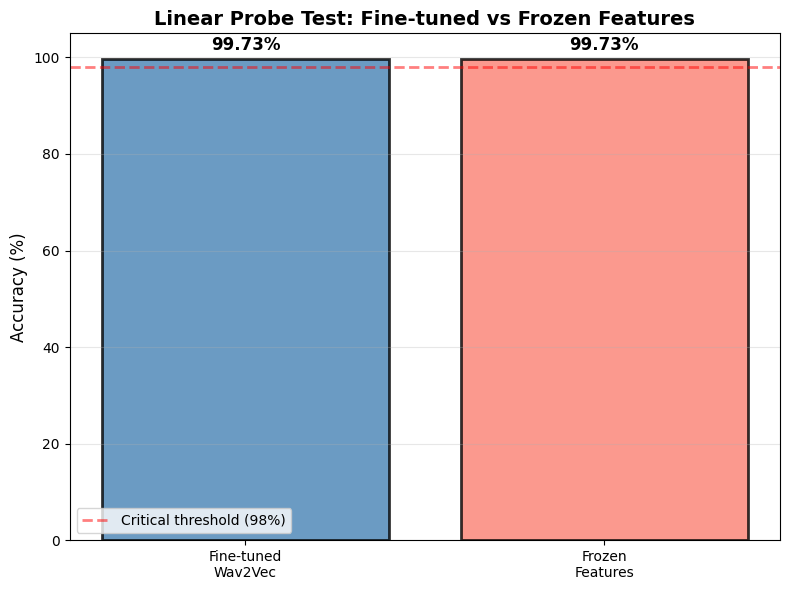


Visualization saved to Drive: linear_probe_test.png

Linear probe test complete!


In [ ]:
print("="*70)
print("LINEAR PROBE TEST - FROZEN WAV2VEC FEATURES")
print("="*70)
print("\nThis tests if classes are trivially separable without fine-tuning")
print("If accuracy > 98%, result is likely artifact-based")
print("="*70)

def extract_features(dataset, batch_size=16):
    features = []
    labels = []

    print(f"\nProcessing {len(dataset)} samples...")

    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_end = min(i + batch_size, len(dataset))
            batch_inputs = []
            batch_labels = []

            for j in range(i, batch_end):
                sample = dataset[j]
                batch_inputs.append(sample['input_values'])
                batch_labels.append(sample['labels'].item())

            batch_inputs = torch.stack(batch_inputs).to(device)

            outputs = model.wav2vec2(batch_inputs)
            hidden_states = outputs.last_hidden_state

            pooled = hidden_states.mean(dim=1)

            features.extend(pooled.cpu().numpy())
            labels.extend(batch_labels)

            if (batch_end) % 500 == 0:
                print(f"  Processed {batch_end}/{len(dataset)} samples...")

    return np.array(features), np.array(labels)

print("\nStep 1: Extracting features from TRAIN set (frozen Wav2Vec)...")
X_train, y_train = extract_features(train_dataset)

print("\nStep 2: Extracting features from TEST set (frozen Wav2Vec)...")
X_test, y_test_lr = extract_features(test_dataset)

print(f"\nFeature shapes:")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")

print("\nStep 3: Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStep 4: Training logistic regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print("\nStep 5: Evaluating on test set...")
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
precision_lr = precision_score(y_test_lr, y_pred_lr)
recall_lr = recall_score(y_test_lr, y_pred_lr)
f1_lr = f1_score(y_test_lr, y_pred_lr)
auc_lr = roc_auc_score(y_test_lr, y_prob_lr)

cm_lr = confusion_matrix(y_test_lr, y_pred_lr)

print("\n" + "="*70)
print("LINEAR PROBE RESULTS (FROZEN FEATURES):")
print("="*70)
print(f"\nAccuracy:  {acc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-score:  {f1_lr:.4f}")
print(f"AUC:       {auc_lr:.4f}")

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm_lr[0,0]:<6}  {cm_lr[0,1]:<6}")
print(f"       Real   {cm_lr[1,0]:<6}  {cm_lr[1,1]:<6}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"Fine-tuned Wav2Vec:  99.73%")
print(f"Frozen features:     {acc_lr:.2%}")
print(f"Improvement:         {(0.9973 - acc_lr)*100:.2f} percentage points")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)

if acc_lr > 0.98:
    print("\nCRITICAL PROBLEM:")
    print("Accuracy > 98% with frozen features!")
    print("Classes are trivially linearly separable in pretrained space")
    print("STRONG indication of dataset artifacts")
    print("The 99.73% fine-tuned result is likely artifact-based, not genuine detection")
elif acc_lr > 0.90:
    print("\nCONCERNING:")
    print("Accuracy > 90% with frozen features")
    print("Significant linear separability exists in pretrained space")
    print("May indicate dataset artifacts")
    print("Further investigation needed")
elif acc_lr > 0.75:
    print("\nMODERATE:")
    print("Accuracy 75-90% with frozen features")
    print("Some separability exists, but fine-tuning adds substantial value")
    print("Results are partially legitimate")
else:
    print("\nGOOD:")
    print("Accuracy < 75% with frozen features")
    print("Fine-tuning is necessary for high performance")
    print("The 99.73% result likely represents genuine deepfake detection")
    print("Classes are not trivially separable")

print("="*70)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
categories = ['Fine-tuned\nWav2Vec', 'Frozen\nFeatures']
values = [99.73, acc_lr * 100]
colors = ['steelblue', 'salmon']
bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=2, alpha=0.8)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Linear Probe Test: Fine-tuned vs Frozen Features', fontsize=14, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=98, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Critical threshold (98%)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/linear_probe_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to Drive: linear_probe_test.png")
print("\nLinear probe test complete!")

#Artifact detection and analysis

##Metadata analysis

###H1: File metadata

Mount and imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import wave
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

print("Imports complete!")

Mounted at /content/drive
Imports complete!


File metadata extraction function

In [ ]:
def get_file_metadata(filepath):
    """Extract file metadata without loading audio content"""

    file_size = os.path.getsize(filepath)

    with wave.open(filepath, 'rb') as wav:
        n_channels = wav.getnchannels()
        sample_width = wav.getsampwidth()
        framerate = wav.getframerate()
        n_frames = wav.getnframes()
        duration = n_frames / framerate

    return np.array([
        file_size,
        n_channels,
        sample_width,
        framerate,
        n_frames,
        duration
    ])

print("Metadata extraction function defined!")
print("\nFeatures extracted:")
print("  1. File size (bytes)")
print("  2. Number of channels")
print("  3. Sample width (bytes)")
print("  4. Frame rate (Hz)")
print("  5. Number of frames")
print("  6. Duration (seconds)")

Metadata extraction function defined!

Features extracted:
  1. File size (bytes)
  2. Number of channels
  3. Sample width (bytes)
  4. Frame rate (Hz)
  5. Number of frames
  6. Duration (seconds)


Process Da_Audio

In [ ]:
print("="*70)
print("FILE METADATA TEST - DANISH DATA (WAV2VEC DATASET)")
print("="*70)

import librosa

def get_file_metadata_fast(filepath):
    """Extract metadata quickly using librosa"""
    file_size = os.path.getsize(filepath)

    info = librosa.get_samplerate(filepath)
    duration = librosa.get_duration(path=filepath)

    n_frames = int(duration * info)

    return np.array([
        file_size,
        1,
        2,
        info,
        n_frames,
        duration
    ])

train_path = "/content/drive/MyDrive/Da_Audio/train"
test_path = "/content/drive/MyDrive/Da_Audio/test"

print("\nProcessing TRAINING set...")
X_train_meta = []
y_train_meta = []

real_train_dir = os.path.join(train_path, "real_train_audio")
fake_train_dir = os.path.join(train_path, "fake_train_audio")

real_files = [os.path.join(real_train_dir, f) for f in os.listdir(real_train_dir) if f.endswith('.wav')]
fake_files = [os.path.join(fake_train_dir, f) for f in os.listdir(fake_train_dir) if f.endswith('.wav')]

print(f"  Real files: {len(real_files)}")
print(f"  Fake files: {len(fake_files)}")

print("  Extracting metadata from real files...")
for i, filepath in enumerate(real_files):
    if (i + 1) % 1000 == 0:
        print(f"    Processed {i + 1}/{len(real_files)}...")
    metadata = get_file_metadata_fast(filepath)
    X_train_meta.append(metadata)
    y_train_meta.append(1)

print("  Extracting metadata from fake files...")
for i, filepath in enumerate(fake_files):
    if (i + 1) % 1000 == 0:
        print(f"    Processed {i + 1}/{len(fake_files)}...")
    metadata = get_file_metadata_fast(filepath)
    X_train_meta.append(metadata)
    y_train_meta.append(0)

X_train_meta = np.array(X_train_meta)
y_train_meta = np.array(y_train_meta)

print("\nProcessing TEST set...")
X_test_meta = []
y_test_meta = []

real_test_dir = os.path.join(test_path, "real_test_audio")
fake_test_dir = os.path.join(test_path, "fake_test_audio")

real_files = [os.path.join(real_test_dir, f) for f in os.listdir(real_test_dir) if f.endswith('.wav')]
fake_files = [os.path.join(fake_test_dir, f) for f in os.listdir(fake_test_dir) if f.endswith('.wav')]

print(f"  Real files: {len(real_files)}")
print(f"  Fake files: {len(fake_files)}")

print("  Extracting metadata from real files...")
for filepath in real_files:
    metadata = get_file_metadata_fast(filepath)
    X_test_meta.append(metadata)
    y_test_meta.append(1)

print("  Extracting metadata from fake files...")
for filepath in fake_files:
    metadata = get_file_metadata_fast(filepath)
    X_test_meta.append(metadata)
    y_test_meta.append(0)

X_test_meta = np.array(X_test_meta)
y_test_meta = np.array(y_test_meta)

print(f"\nDataset shapes:")
print(f"  Train: {X_train_meta.shape}")
print(f"  Test:  {X_test_meta.shape}")

scaler_meta = StandardScaler()
X_train_meta_scaled = scaler_meta.fit_transform(X_train_meta)
X_test_meta_scaled = scaler_meta.transform(X_test_meta)

print("\nTraining logistic regression on metadata only...")
lr_meta = LogisticRegression(max_iter=1000, random_state=42)
lr_meta.fit(X_train_meta_scaled, y_train_meta)

y_pred_meta = lr_meta.predict(X_test_meta_scaled)
acc_meta = accuracy_score(y_test_meta, y_pred_meta)
cm_meta = confusion_matrix(y_test_meta, y_pred_meta)

print("\n" + "="*70)
print("DANISH DATA - FILE METADATA RESULTS:")
print("="*70)
print(f"\nAccuracy using ONLY file metadata: {acc_meta:.4f}")
print("\nFeatures used (NO AUDIO CONTENT):")
print("  - File size, channels, sample width")
print("  - Frame rate, number of frames, duration")

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm_meta[0,0]:<6}  {cm_meta[0,1]:<6}")
print(f"       Real   {cm_meta[1,0]:<6}  {cm_meta[1,1]:<6}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)

if acc_meta > 0.80:
    print("\nCRITICAL PROBLEM:")
    print("File metadata alone achieves > 80% accuracy!")
    print("Real and fake files have STRUCTURAL differences")
    print("Wav2Vec is detecting file-level artifacts, NOT acoustic deepfakes")
    print("\nThis explains the frozen features problem:")
    print("Pretrained Wav2Vec can see these structural patterns")
elif acc_meta > 0.60:
    print("\nCONCERNING:")
    print("File metadata alone achieves > 60% accuracy")
    print("Some structural differences exist between real/fake")
    print("May contribute to high Wav2Vec performance")
else:
    print("\nGOOD:")
    print("File metadata alone achieves < 60% accuracy")
    print("No trivial file-level separation")
    print("Models must rely on audio content")

print("\n" + "="*70)
print("FEATURE IMPORTANCE (Logistic Regression Coefficients):")
print("="*70)

feature_names = ['File Size', 'Channels', 'Sample Width', 'Frame Rate', 'Frames', 'Duration']
coefficients = lr_meta.coef_[0]

for name, coef in zip(feature_names, coefficients):
    print(f"  {name:15s}: {coef:8.4f}")

print("\nLargest coefficients indicate most discriminative features")
print("="*70)

FILE METADATA TEST - DANISH DATA (WAV2VEC DATASET)

Processing TRAINING set...
  Real files: 5405
  Fake files: 5405
  Extracting metadata from real files...
    Processed 1000/5405...
    Processed 2000/5405...
    Processed 3000/5405...
    Processed 4000/5405...
    Processed 5000/5405...
  Extracting metadata from fake files...
    Processed 1000/5405...
    Processed 2000/5405...
    Processed 3000/5405...
    Processed 4000/5405...
    Processed 5000/5405...

Processing TEST set...
  Real files: 1100
  Fake files: 1100
  Extracting metadata from real files...
  Extracting metadata from fake files...

Dataset shapes:
  Train: (10810, 6)
  Test:  (2200, 6)

Training logistic regression on metadata only...

DANISH DATA - FILE METADATA RESULTS:

Accuracy using ONLY file metadata: 0.9259

Features used (NO AUDIO CONTENT):
  - File size, channels, sample width
  - Frame rate, number of frames, duration

Confusion Matrix:
                Predicted
              Fake    Real
Actual Fake 

Analyze metadata distributions


METADATA DISTRIBUTIONS - DANISH DATA

Real vs Fake metadata comparison:
----------------------------------------------------------------------

File Size:
  Real: 1591343.78 ± 788552.23
  Fake: 483229.38 ± 140448.67
  Diff: 1108114.40
  LARGE DIFFERENCE in File Size!

Channels:
  Real: 1.00 ± 0.00
  Fake: 1.00 ± 0.00
  Diff: 0.00

Sample Width:
  Real: 2.00 ± 0.00
  Fake: 2.00 ± 0.00
  Diff: 0.00

Frame Rate:
  Real: 46058.26 ± 7316.80
  Fake: 23675.30 ± 726.45
  Diff: 22382.96
  LARGE DIFFERENCE in Frame Rate!

Frames:
  Real: 545026.35 ± 185813.58
  Fake: 241578.43 ± 70220.64
  Diff: 303447.92
  LARGE DIFFERENCE in Frames!

Duration:
  Real: 11.88 ± 3.57
  Fake: 10.16 ± 2.84
  Diff: 1.72


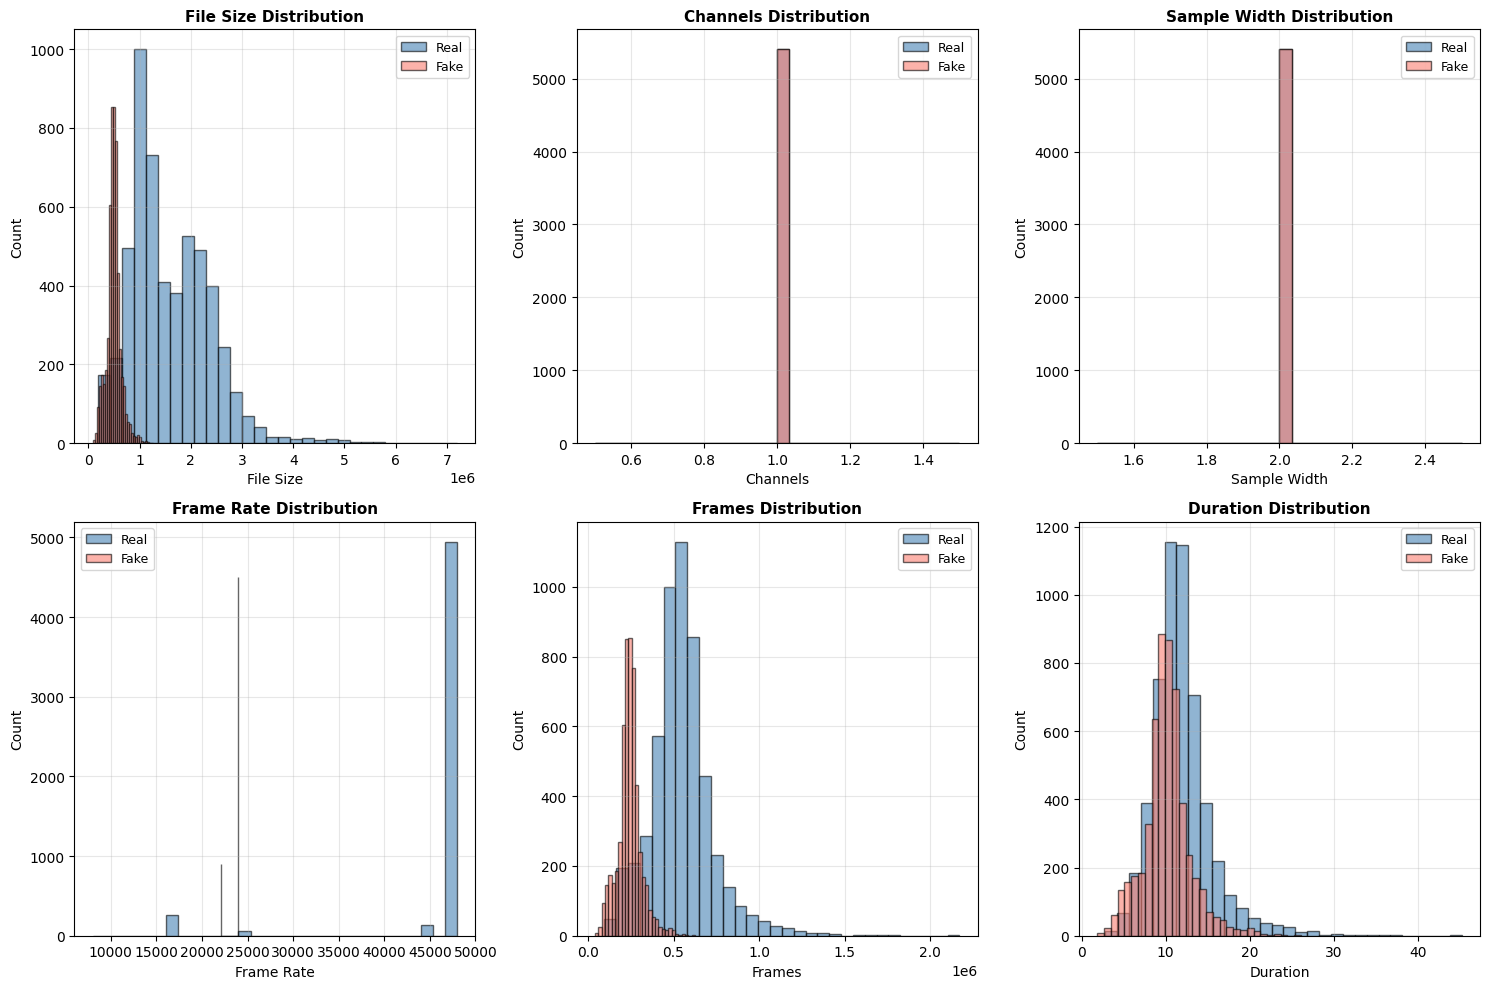


Visualization saved to Drive: metadata_distributions_danish.png


In [ ]:
print("\n" + "="*70)
print("METADATA DISTRIBUTIONS - DANISH DATA")
print("="*70)

feature_names = ['File Size', 'Channels', 'Sample Width', 'Frame Rate', 'Frames', 'Duration']

print("\nReal vs Fake metadata comparison:")
print("-" * 70)

for i, name in enumerate(feature_names):
    real_values = X_train_meta[y_train_meta == 1, i]
    fake_values = X_train_meta[y_train_meta == 0, i]

    real_mean = np.mean(real_values)
    fake_mean = np.mean(fake_values)
    real_std = np.std(real_values)
    fake_std = np.std(fake_values)

    print(f"\n{name}:")
    print(f"  Real: {real_mean:.2f} ± {real_std:.2f}")
    print(f"  Fake: {fake_mean:.2f} ± {fake_std:.2f}")
    print(f"  Diff: {abs(real_mean - fake_mean):.2f}")

    if name == "Frame Rate" and abs(real_mean - fake_mean) > 100:
        print(f"  LARGE DIFFERENCE in {name}!")
    elif name in ["File Size", "Frames"] and abs(real_mean - fake_mean) / max(real_mean, fake_mean) > 0.1:
        print(f"  LARGE DIFFERENCE in {name}!")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    ax = axes[i]

    real_values = X_train_meta[y_train_meta == 1, i]
    fake_values = X_train_meta[y_train_meta == 0, i]

    ax.hist(real_values, bins=30, alpha=0.6, label='Real', color='steelblue', edgecolor='black')
    ax.hist(fake_values, bins=30, alpha=0.6, label='Fake', color='salmon', edgecolor='black')

    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{name} Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/metadata_distributions_danish.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to Drive: metadata_distributions_danish.png")
print("="*70)

##Acoustic feature analysis


Connect to drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


Load data

In [ ]:
import os
import shutil

drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"
MAX_PER_FOLDER = 50

SPLIT_NAME_MAP = {
    "train": "train",
    "validation": "val",
    "test": "test"
}

if os.path.exists(local_path):
    shutil.rmtree(local_path)
    print("Deleted existing folder")

os.makedirs(local_path)
for split, split_short in SPLIT_NAME_MAP.items():
    for label in ["real", "fake"]:
        src = os.path.join(drive_path, split, f"{label}_{split_short}_audio")
        dst = os.path.join(local_path, split, f"{label}_{split_short}_audio")
        os.makedirs(dst, exist_ok=True)
        files = sorted([f for f in os.listdir(src) if f.endswith('.wav')])[:MAX_PER_FOLDER]
        for f in files:
            shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        print(f"  Copied {len(files)} files: {split}/{label}")
print("Done!")

Deleted existing folder
  Copied 50 files: train/real
  Copied 50 files: train/fake
  Copied 50 files: validation/real
  Copied 50 files: validation/fake
  Copied 50 files: test/real
  Copied 50 files: test/fake
Done!


Shared setup

In [ ]:
import os
import shutil
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import binomtest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

DA_AUDIO_PATH = "/content/da_audio"
MAX_SAMPLES_PER_CLASS = 50
SR = 16000

SPLIT_NAME_MAP = {
    "train": "train",
    "validation": "val",
    "test": "test"
}

def collect_files(base_path, split, max_per_class=MAX_SAMPLES_PER_CLASS):
    split_short = SPLIT_NAME_MAP[split]
    real_dir = os.path.join(base_path, split, f"real_{split_short}_audio")
    fake_dir = os.path.join(base_path, split, f"fake_{split_short}_audio")
    real_files = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')])
    fake_files = sorted([os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')])
    if max_per_class:
        real_files = real_files[:max_per_class]
        fake_files = fake_files[:max_per_class]
    files  = real_files + fake_files
    labels = [1]*len(real_files) + [0]*len(fake_files)
    print(f"  {split}: {len(real_files)} real + {len(fake_files)} fake")
    return files, labels

def load_audio(path, sr=SR, duration=5):
    audio, _ = librosa.load(path, sr=sr, mono=True, duration=duration)
    target = sr * duration
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    return audio[:target]

def linear_probe(X, y, cv=5):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
    mean_acc = scores.mean()
    std_acc  = scores.std()
    n = len(y)
    k = int(mean_acc * n)
    binom_p = binomtest(k, n, p=0.5, alternative='greater').pvalue
    print(f"  CV accuracy: {mean_acc:.4f} +/- {std_acc:.4f}")
    print(f"  Binomial test vs chance: p={binom_p:.4f} ({'significant' if binom_p < 0.05 else 'not significant'})")
    return mean_acc, std_acc, binom_p

all_files, all_labels = [], []
for split in ["train", "validation", "test"]:
    f, l = collect_files(DA_AUDIO_PATH, split)
    all_files += f
    all_labels += l
print(f"\nTotal: {len(all_files)} files")

  train: 50 real + 50 fake
  validation: 50 real + 50 fake
  test: 50 real + 50 fake

Total: 300 files


###H2: Spectral and microphone characteristics

Extracting H2 features...

SPECTRAL FEATURE COMPARISON (Real vs Fake)

spectral_centroid_mean:
  Real:       1810.2362 +/- 365.4352
  Fake:       1796.4057 +/- 165.9206
  Difference: -0.76%
  t-test:     t=0.422, p=0.6733 (not significant)
  Cohen's d:  0.049 (small effect)

spectral_rolloff_mean:
  Real:       3271.4782 +/- 648.7070
  Fake:       3344.7176 +/- 242.8428
  Difference: +2.24%
  t-test:     t=-1.295, p=0.1963 (not significant)
  Cohen's d:  -0.150 (small effect)

spectral_bandwidth_mean:
  Real:       1477.7694 +/- 226.5179
  Fake:       1594.8147 +/- 61.4991
  Difference: +7.92%
  t-test:     t=-6.107, p=0.0000 (significant)
  Cohen's d:  -0.708 (medium effect)

zero_crossing_rate_mean:
  Real:       0.1674 +/- 0.0433
  Fake:       0.1447 +/- 0.0213
  Difference: -13.55%
  t-test:     t=5.756, p=0.0000 (significant)
  Cohen's d:  0.667 (medium effect)


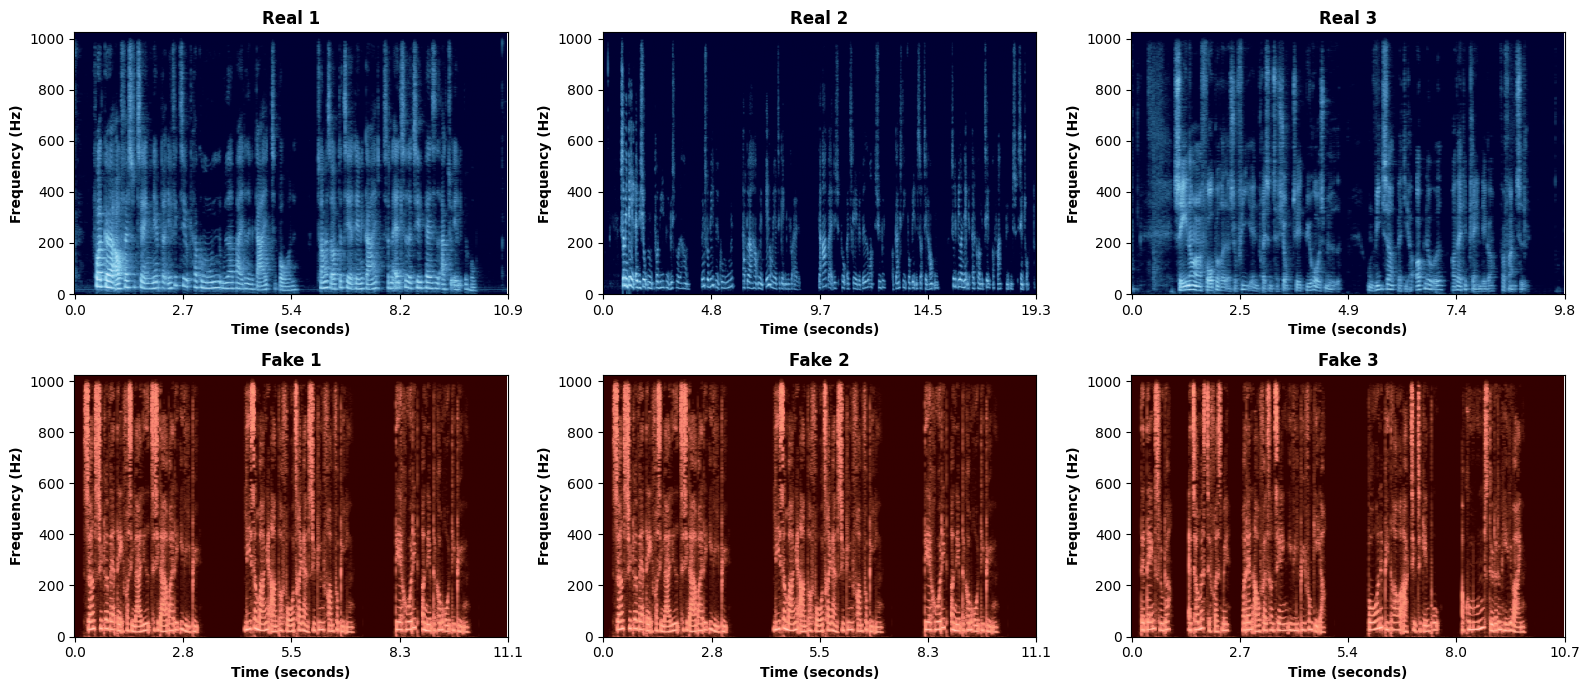

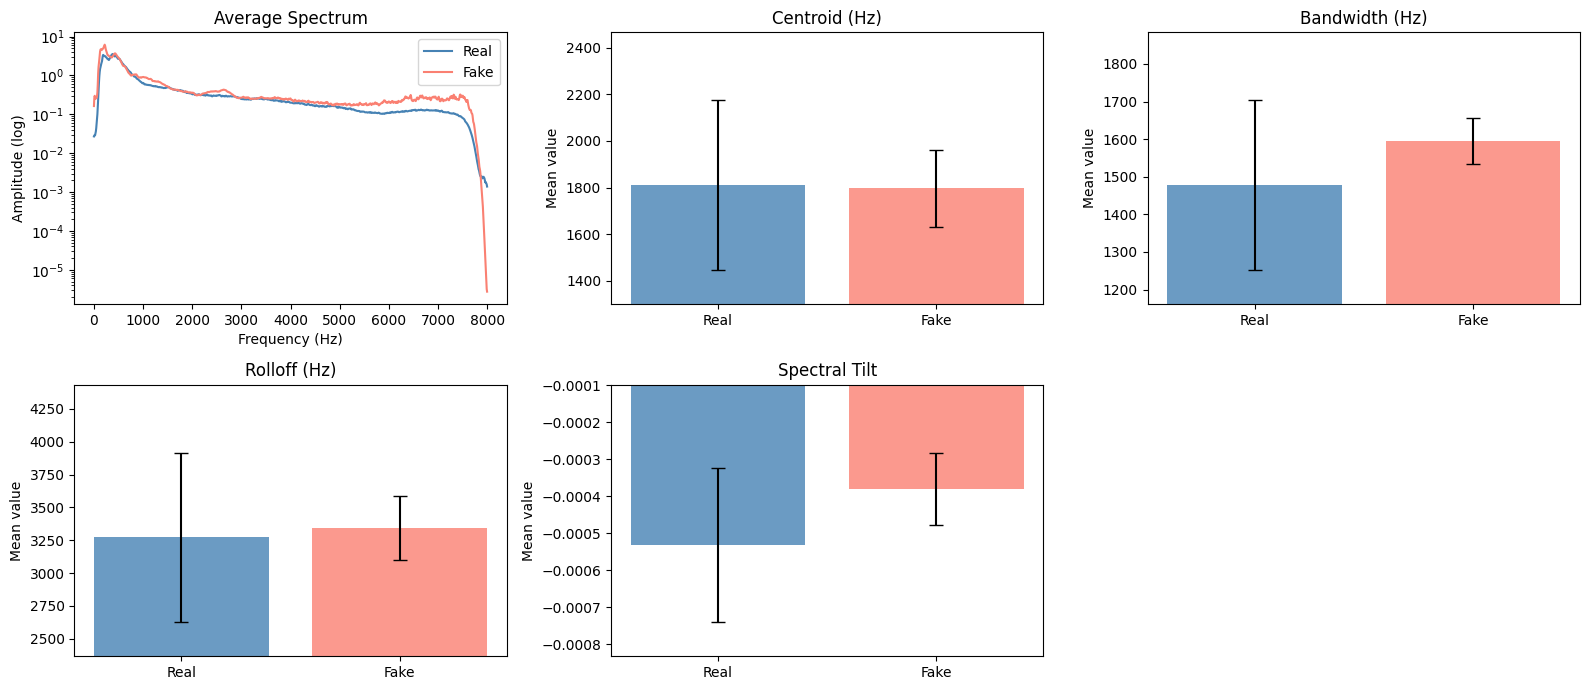

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

steelblue_colors = ['#000033', '#1a4d73', '#4682b4', '#87ceeb', '#e0f2ff']
steelblue_cmap   = LinearSegmentedColormap.from_list('steelblue', steelblue_colors)
salmon_colors    = ['#330000', '#732d1a', '#fa8072', '#ffa07a', '#ffe4e1']
salmon_cmap      = LinearSegmentedColormap.from_list('salmon', salmon_colors)

def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)

print("Extracting H2 features...")
real_features, fake_features   = [], []
real_specs, fake_specs         = [], []
real_slopes, fake_slopes       = [], []
real_centroids, fake_centroids = [], []
real_bws, fake_bws             = [], []
real_rolloffs, fake_rolloffs   = [], []
real_files_clean, fake_files_clean = [], []

for path, label in zip(all_files, all_labels):
    try:
        audio, sr = librosa.load(path, sr=16000, mono=True)
        S         = np.abs(librosa.stft(audio))
        S_mean    = S.mean(axis=1)
        freqs     = librosa.fft_frequencies(sr=16000)
        slope, *_ = stats.linregress(freqs, np.log(S_mean + 1e-10))
        centroid  = librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean()
        bw        = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean()
        rolloff   = librosa.feature.spectral_rolloff(y=audio, sr=sr, roll_percent=0.85)[0].mean()
        zcr       = librosa.feature.zero_crossing_rate(audio)[0].mean()
    except Exception as e:
        print(f"  Error processing {path}: {e}")
        continue

    feat = {
        'spectral_centroid_mean':  centroid,
        'spectral_rolloff_mean':   rolloff,
        'spectral_bandwidth_mean': bw,
        'zero_crossing_rate_mean': zcr,
    }

    if label == 1:
        real_features.append(feat)
        real_specs.append(S_mean)
        real_slopes.append(slope)
        real_centroids.append(centroid)
        real_bws.append(bw)
        real_rolloffs.append(rolloff)
        real_files_clean.append(path)
    else:
        fake_features.append(feat)
        fake_specs.append(S_mean)
        fake_slopes.append(slope)
        fake_centroids.append(centroid)
        fake_bws.append(bw)
        fake_rolloffs.append(rolloff)
        fake_files_clean.append(path)

real_df = pd.DataFrame(real_features)
fake_df = pd.DataFrame(fake_features)

print("\n" + "="*70)
print("SPECTRAL FEATURE COMPARISON (Real vs Fake)")
print("="*70)

for col in real_df.columns:
    real_mean = real_df[col].mean()
    fake_mean = fake_df[col].mean()
    real_std  = real_df[col].std()
    fake_std  = fake_df[col].std()
    diff_pct  = ((fake_mean - real_mean) / real_mean) * 100
    t, p      = stats.ttest_ind(real_df[col], fake_df[col])
    d         = cohens_d(real_df[col], fake_df[col])
    effect    = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'

    print(f"\n{col}:")
    print(f"  Real:       {real_mean:.4f} +/- {real_std:.4f}")
    print(f"  Fake:       {fake_mean:.4f} +/- {fake_std:.4f}")
    print(f"  Difference: {diff_pct:+.2f}%")
    print(f"  t-test:     t={t:.3f}, p={p:.4f} ({'significant' if p < 0.05 else 'not significant'})")
    print(f"  Cohen's d:  {d:.3f} ({effect} effect)")

vmin, vmax = -80, 0

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for i in range(3):
    audio_real, sr = librosa.load(real_files_clean[i], sr=16000, mono=True)
    D_real         = librosa.amplitude_to_db(np.abs(librosa.stft(audio_real)), ref=np.max)
    duration_real  = len(audio_real) / sr
    axes[0, i].imshow(D_real, aspect='auto', origin='lower', cmap=steelblue_cmap, vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f'Real {i+1}', fontweight='bold')
    axes[0, i].set_ylabel('Frequency (Hz)', fontweight='bold')
    axes[0, i].set_xlabel('Time (seconds)', fontweight='bold')
    axes[0, i].set_xticks(np.linspace(0, D_real.shape[1], 5))
    axes[0, i].set_xticklabels([f'{x:.1f}' for x in np.linspace(0, duration_real, 5)])

    audio_fake, sr = librosa.load(fake_files_clean[i], sr=16000, mono=True)
    D_fake         = librosa.amplitude_to_db(np.abs(librosa.stft(audio_fake)), ref=np.max)
    duration_fake  = len(audio_fake) / sr
    axes[1, i].imshow(D_fake, aspect='auto', origin='lower', cmap=salmon_cmap, vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f'Fake {i+1}', fontweight='bold')
    axes[1, i].set_ylabel('Frequency (Hz)', fontweight='bold')
    axes[1, i].set_xlabel('Time (seconds)', fontweight='bold')
    axes[1, i].set_xticks(np.linspace(0, D_fake.shape[1], 5))
    axes[1, i].set_xticklabels([f'{x:.1f}' for x in np.linspace(0, duration_fake, 5)])

plt.tight_layout()
plt.show()

feature_names  = ['Centroid (Hz)', 'Bandwidth (Hz)', 'Rolloff (Hz)', 'Spectral Tilt']
real_vals_list = [real_centroids, real_bws, real_rolloffs, real_slopes]
fake_vals_list = [fake_centroids, fake_bws, fake_rolloffs, fake_slopes]

freqs          = librosa.fft_frequencies(sr=16000)
real_mean_spec = np.mean(real_specs, axis=0)
fake_mean_spec = np.mean(fake_specs, axis=0)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

axes[0, 0].semilogy(freqs, real_mean_spec, label='Real', color='steelblue')
axes[0, 0].semilogy(freqs, fake_mean_spec, label='Fake', color='salmon')
axes[0, 0].set_xlabel('Frequency (Hz)')
axes[0, 0].set_ylabel('Amplitude (log)')
axes[0, 0].set_title('Average Spectrum')
axes[0, 0].legend()

plot_positions = [(0,1), (0,2), (1,0), (1,1)]

for idx, (name, real_vals, fake_vals) in enumerate(zip(feature_names, real_vals_list, fake_vals_list)):
    real_mean = np.mean(real_vals)
    fake_mean = np.mean(fake_vals)
    real_std  = np.std(real_vals)
    fake_std  = np.std(fake_vals)

    row, col = plot_positions[idx]
    ax = axes[row, col]

    ax.bar(['Real', 'Fake'], [real_mean, fake_mean],
           color=['steelblue', 'salmon'], alpha=0.8)
    ax.errorbar(['Real', 'Fake'], [real_mean, fake_mean],
                yerr=[real_std, fake_std],
                fmt='none', color='black', capsize=5)
    ax.set_title(name)
    ax.set_ylabel('Mean value')

    y_min   = min(real_mean - real_std, fake_mean - fake_std)
    y_max   = max(real_mean + real_std, fake_mean + fake_std)
    padding = abs(y_max - y_min) * 0.2
    ax.set_ylim(y_min - padding, y_max + padding * 2)

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

###H3: Recording quality

Extracting H3 features...

BITRATE & ENCODING COMPARISON:

Bit Rate:
  Real mean:  1054464 bps
  Fake mean:  384043 bps
  Difference: -63.58%

File Size:
  Real mean:  1603358 +/- 875642 bytes
  Fake mean:  599064 +/- 116311 bytes
  Difference: -62.64%
  t-test:     t=13.925, p=0.0000 (significant)
  Cohen's d:  1.613 (large effect)

Codec:
  Real: {'pcm_s16le': 150}
  Fake: {'pcm_s16le': 150}

SIGNAL-TO-NOISE RATIO (SNR):

SNR (dB):
  Real mean:  53.80 +/- 11.24 dB
  Fake mean:  55.62 +/- 17.74 dB
  Difference: 1.82 dB
  t-test:     t=-1.025, p=0.3063 (not significant)
  Cohen's d:  -0.123 (small effect)


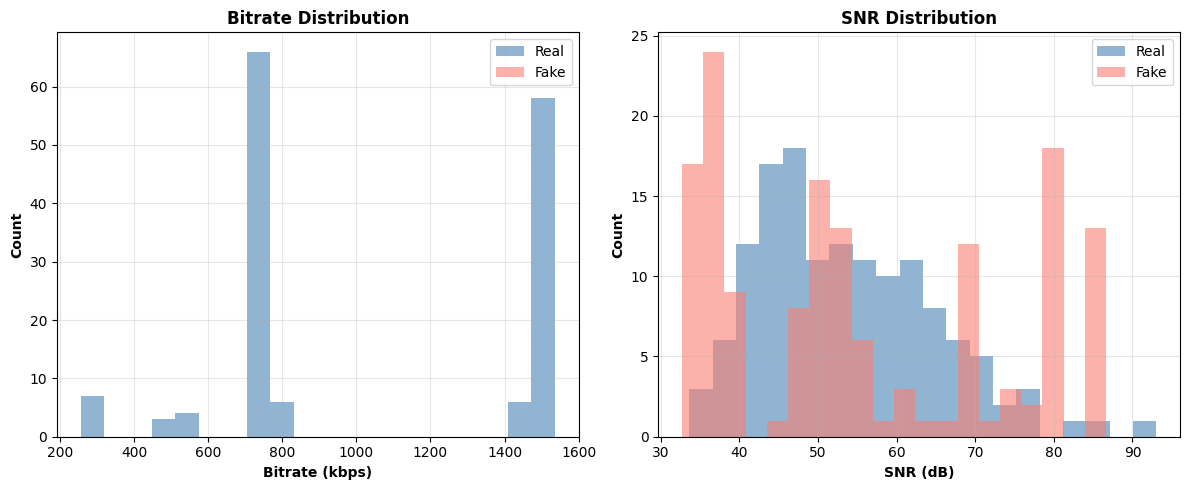

In [ ]:
import subprocess
import json

def get_audio_metadata(file_path):
    try:
        cmd = [
            'ffprobe',
            '-v', 'quiet',
            '-print_format', 'json',
            '-show_format',
            '-show_streams',
            file_path
        ]
        result = subprocess.run(cmd, capture_output=True, text=True)
        data = json.loads(result.stdout)
        stream = data['streams'][0]
        format_info = data['format']
        return {
            'bit_rate':    int(format_info.get('bit_rate', 0)),
            'sample_rate': int(stream.get('sample_rate', 0)),
            'channels':    int(stream.get('channels', 0)),
            'codec':       stream.get('codec_name', 'unknown'),
            'duration':    float(format_info.get('duration', 0)),
            'size':        int(format_info.get('size', 0))
        }
    except:
        return None

def calculate_snr(audio):
    sorted_audio     = np.sort(np.abs(audio))
    signal_threshold = sorted_audio[int(len(sorted_audio) * 0.75)]
    signal_samples   = audio[np.abs(audio) > signal_threshold]
    noise_threshold  = sorted_audio[int(len(sorted_audio) * 0.25)]
    noise_samples    = audio[np.abs(audio) < noise_threshold]
    if len(signal_samples) > 0 and len(noise_samples) > 0:
        signal_power = np.mean(signal_samples ** 2)
        noise_power  = np.mean(noise_samples ** 2)
        if noise_power > 0:
            return 10 * np.log10(signal_power / noise_power)
    return None

def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)

print("Extracting H3 features...")
real_metadata, fake_metadata = [], []
real_snr, fake_snr           = [], []

for path, label in zip(all_files, all_labels):
    meta     = get_audio_metadata(path)
    audio, _ = librosa.load(path, sr=None, mono=True)
    snr      = calculate_snr(audio)

    if label == 1:
        if meta:
            real_metadata.append(meta)
        if snr is not None:
            real_snr.append(snr)
    else:
        if meta:
            fake_metadata.append(meta)
        if snr is not None:
            fake_snr.append(snr)

real_meta_df = pd.DataFrame(real_metadata)
fake_meta_df = pd.DataFrame(fake_metadata)

t_size, p_size = stats.ttest_ind(real_meta_df['size'], fake_meta_df['size'])
d_size         = cohens_d(real_meta_df['size'], fake_meta_df['size'])
effect_size    = 'large' if abs(d_size) > 0.8 else 'medium' if abs(d_size) > 0.5 else 'small'

t_snr, p_snr = stats.ttest_ind(real_snr, fake_snr)
d_snr        = cohens_d(real_snr, fake_snr)
effect_snr   = 'large' if abs(d_snr) > 0.8 else 'medium' if abs(d_snr) > 0.5 else 'small'

print("\n" + "="*70)
print("BITRATE & ENCODING COMPARISON:")
print("="*70)

print(f"\nBit Rate:")
print(f"  Real mean:  {real_meta_df['bit_rate'].mean():.0f} bps")
print(f"  Fake mean:  {fake_meta_df['bit_rate'].mean():.0f} bps")
print(f"  Difference: {((fake_meta_df['bit_rate'].mean() - real_meta_df['bit_rate'].mean()) / real_meta_df['bit_rate'].mean() * 100):.2f}%")

print(f"\nFile Size:")
print(f"  Real mean:  {real_meta_df['size'].mean():.0f} +/- {real_meta_df['size'].std():.0f} bytes")
print(f"  Fake mean:  {fake_meta_df['size'].mean():.0f} +/- {fake_meta_df['size'].std():.0f} bytes")
print(f"  Difference: {((fake_meta_df['size'].mean() - real_meta_df['size'].mean()) / real_meta_df['size'].mean() * 100):.2f}%")
print(f"  t-test:     t={t_size:.3f}, p={p_size:.4f} ({'significant' if p_size < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_size:.3f} ({effect_size} effect)")

print(f"\nCodec:")
print(f"  Real: {real_meta_df['codec'].value_counts().to_dict()}")
print(f"  Fake: {fake_meta_df['codec'].value_counts().to_dict()}")

print("\n" + "="*70)
print("SIGNAL-TO-NOISE RATIO (SNR):")
print("="*70)

print(f"\nSNR (dB):")
print(f"  Real mean:  {np.mean(real_snr):.2f} +/- {np.std(real_snr):.2f} dB")
print(f"  Fake mean:  {np.mean(fake_snr):.2f} +/- {np.std(fake_snr):.2f} dB")
print(f"  Difference: {(np.mean(fake_snr) - np.mean(real_snr)):.2f} dB")
print(f"  t-test:     t={t_snr:.3f}, p={p_snr:.4f} ({'significant' if p_snr < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_snr:.3f} ({effect_snr} effect)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(real_meta_df['bit_rate']/1000, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[0].hist(fake_meta_df['bit_rate']/1000, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[0].set_xlabel('Bitrate (kbps)', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Bitrate Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(real_snr, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[1].hist(fake_snr, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[1].set_xlabel('SNR (dB)', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('SNR Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

###H4: Background noise

Extracting H4 features...

BACKGROUND NOISE COMPARISON:

Noise Floor (RMS):
  Real mean:  0.003459 +/- 0.000476
  Fake mean:  0.003323 +/- 0.000623
  Difference: -3.93%
  t-test:     t=2.117, p=0.0351 (significant)
  Cohen's d:  0.245 (small effect)

Quiet Regions (%):
  Real mean:  50.49 +/- 9.17%
  Fake mean:  41.43 +/- 7.02%
  Difference: -9.07 percentage points
  t-test:     t=9.583, p=0.0000 (significant)
  Cohen's d:  1.110 (large effect)


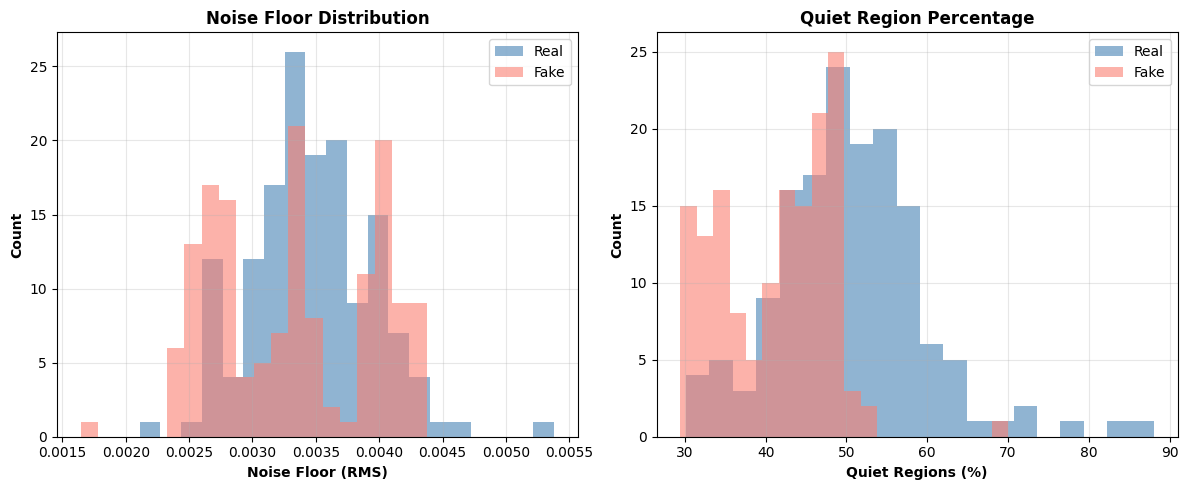

In [ ]:
def analyze_background_noise(file_path, threshold=0.01):
    audio, sr = librosa.load(file_path, sr=16000, mono=True)
    quiet_mask  = np.abs(audio) < threshold
    quiet_audio = audio[quiet_mask]
    if len(quiet_audio) > 100:
        return {
            'noise_floor_rms':  np.sqrt(np.mean(quiet_audio ** 2)),
            'quiet_percentage': (np.sum(quiet_mask) / len(audio)) * 100,
        }
    return None

def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)

print("Extracting H4 features...")
real_noise, fake_noise = [], []

for path, label in zip(all_files, all_labels):
    noise = analyze_background_noise(path)
    if noise is None:
        continue
    if label == 1:
        real_noise.append(noise)
    else:
        fake_noise.append(noise)

real_noise_floor = [n['noise_floor_rms']  for n in real_noise]
fake_noise_floor = [n['noise_floor_rms']  for n in fake_noise]
real_quiet_pct   = [n['quiet_percentage'] for n in real_noise]
fake_quiet_pct   = [n['quiet_percentage'] for n in fake_noise]

t_nf, p_nf = stats.ttest_ind(real_noise_floor, fake_noise_floor)
d_nf        = cohens_d(real_noise_floor, fake_noise_floor)
effect_nf   = 'large' if abs(d_nf) > 0.8 else 'medium' if abs(d_nf) > 0.5 else 'small'

t_qp, p_qp = stats.ttest_ind(real_quiet_pct, fake_quiet_pct)
d_qp        = cohens_d(real_quiet_pct, fake_quiet_pct)
effect_qp   = 'large' if abs(d_qp) > 0.8 else 'medium' if abs(d_qp) > 0.5 else 'small'

print("\n" + "="*70)
print("BACKGROUND NOISE COMPARISON:")
print("="*70)

print(f"\nNoise Floor (RMS):")
print(f"  Real mean:  {np.mean(real_noise_floor):.6f} +/- {np.std(real_noise_floor):.6f}")
print(f"  Fake mean:  {np.mean(fake_noise_floor):.6f} +/- {np.std(fake_noise_floor):.6f}")
print(f"  Difference: {((np.mean(fake_noise_floor) - np.mean(real_noise_floor)) / np.mean(real_noise_floor) * 100):+.2f}%")
print(f"  t-test:     t={t_nf:.3f}, p={p_nf:.4f} ({'significant' if p_nf < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_nf:.3f} ({effect_nf} effect)")

print(f"\nQuiet Regions (%):")
print(f"  Real mean:  {np.mean(real_quiet_pct):.2f} +/- {np.std(real_quiet_pct):.2f}%")
print(f"  Fake mean:  {np.mean(fake_quiet_pct):.2f} +/- {np.std(fake_quiet_pct):.2f}%")
print(f"  Difference: {(np.mean(fake_quiet_pct) - np.mean(real_quiet_pct)):+.2f} percentage points")
print(f"  t-test:     t={t_qp:.3f}, p={p_qp:.4f} ({'significant' if p_qp < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_qp:.3f} ({effect_qp} effect)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(real_noise_floor, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[0].hist(fake_noise_floor, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[0].set_xlabel('Noise Floor (RMS)', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Noise Floor Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(real_quiet_pct, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[1].hist(fake_quiet_pct, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[1].set_xlabel('Quiet Regions (%)', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Quiet Region Percentage', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

###H5: Room acoustics

Extracting H5 features...

ROOM ACOUSTICS COMPARISON:

RT60 (Reverberation Time):
  Real mean:  2.625 +/- 1.736 seconds
  Fake mean:  3.232 +/- 2.586 seconds
  Difference: +23.14%
  t-test:     t=-2.230, p=0.0266 (significant)
  Cohen's d:  -0.276 (small effect)

Echo Count:
  Real mean:  1.62 +/- 0.83
  Fake mean:  1.09 +/- 0.49
  Difference: -0.53
  t-test:     t=6.654, p=0.0000 (significant)
  Cohen's d:  0.771 (medium effect)

Echo Strength:
  Real mean:  0.2667 +/- 0.1271
  Fake mean:  0.3420 +/- 0.2959
  Difference: +28.25%
  t-test:     t=-2.856, p=0.0046 (significant)
  Cohen's d:  -0.331 (small effect)


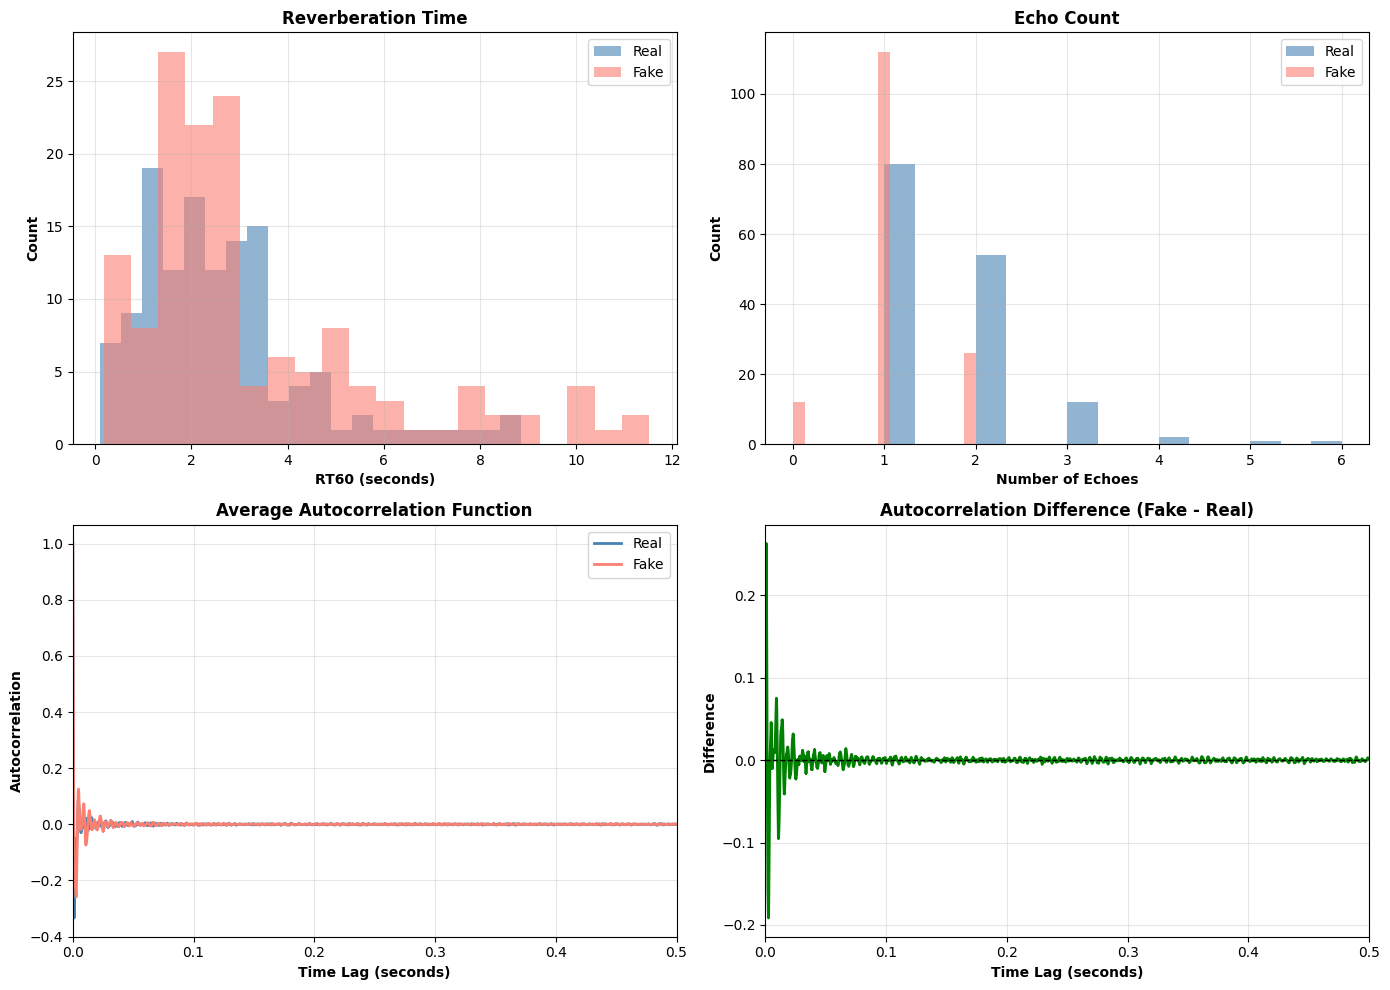

In [ ]:
from scipy.signal import correlate, find_peaks

def estimate_rt60(audio, sr):
    audio_squared   = audio ** 2
    window_size     = int(sr * 0.05)
    energy          = np.convolve(audio_squared, np.ones(window_size)/window_size, mode='same')
    energy_db       = 10 * np.log10(energy + 1e-10)
    max_energy      = np.max(energy_db)
    threshold       = max_energy - 60
    max_idx         = np.argmax(energy_db)
    below_threshold = np.where(energy_db[max_idx:] < threshold)[0]
    if len(below_threshold) > 0:
        return below_threshold[0] / sr
    return None

def analyze_autocorrelation(audio, sr):
    autocorr = correlate(audio, audio, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    autocorr = autocorr / autocorr[0]
    peaks, _ = find_peaks(autocorr[:int(sr*0.5)], height=0.1, distance=int(sr*0.02))
    return {
        'num_echoes':    len(peaks),
        'echo_strength': np.mean(autocorr[peaks]) if len(peaks) > 0 else 0,
        'autocorr':      autocorr[:int(sr*0.5)]
    }

def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)

print("Extracting H5 features...")
real_rt60, fake_rt60         = [], []
real_echo, fake_echo         = [], []
real_autocorr, fake_autocorr = [], []

for path, label in zip(all_files, all_labels):
    audio, sr = librosa.load(path, sr=16000, mono=True)
    rt60      = estimate_rt60(audio, sr)
    echo_data = analyze_autocorrelation(audio, sr)

    if label == 1:
        if rt60 is not None:
            real_rt60.append(rt60)
        real_echo.append(echo_data)
        real_autocorr.append(echo_data['autocorr'])
    else:
        if rt60 is not None:
            fake_rt60.append(rt60)
        fake_echo.append(echo_data)
        fake_autocorr.append(echo_data['autocorr'])

real_echo_count    = [e['num_echoes']    for e in real_echo]
fake_echo_count    = [e['num_echoes']    for e in fake_echo]
real_echo_strength = [e['echo_strength'] for e in real_echo]
fake_echo_strength = [e['echo_strength'] for e in fake_echo]

t_rt60, p_rt60 = stats.ttest_ind(real_rt60, fake_rt60)
d_rt60         = cohens_d(real_rt60, fake_rt60)
effect_rt60    = 'large' if abs(d_rt60) > 0.8 else 'medium' if abs(d_rt60) > 0.5 else 'small'

t_ec, p_ec = stats.ttest_ind(real_echo_count, fake_echo_count)
d_ec       = cohens_d(real_echo_count, fake_echo_count)
effect_ec  = 'large' if abs(d_ec) > 0.8 else 'medium' if abs(d_ec) > 0.5 else 'small'

t_es, p_es = stats.ttest_ind(real_echo_strength, fake_echo_strength)
d_es       = cohens_d(real_echo_strength, fake_echo_strength)
effect_es  = 'large' if abs(d_es) > 0.8 else 'medium' if abs(d_es) > 0.5 else 'small'

print("\n" + "="*70)
print("ROOM ACOUSTICS COMPARISON:")
print("="*70)

print(f"\nRT60 (Reverberation Time):")
print(f"  Real mean:  {np.mean(real_rt60):.3f} +/- {np.std(real_rt60):.3f} seconds")
print(f"  Fake mean:  {np.mean(fake_rt60):.3f} +/- {np.std(fake_rt60):.3f} seconds")
print(f"  Difference: {((np.mean(fake_rt60) - np.mean(real_rt60)) / np.mean(real_rt60) * 100):+.2f}%")
print(f"  t-test:     t={t_rt60:.3f}, p={p_rt60:.4f} ({'significant' if p_rt60 < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_rt60:.3f} ({effect_rt60} effect)")

print(f"\nEcho Count:")
print(f"  Real mean:  {np.mean(real_echo_count):.2f} +/- {np.std(real_echo_count):.2f}")
print(f"  Fake mean:  {np.mean(fake_echo_count):.2f} +/- {np.std(fake_echo_count):.2f}")
print(f"  Difference: {(np.mean(fake_echo_count) - np.mean(real_echo_count)):+.2f}")
print(f"  t-test:     t={t_ec:.3f}, p={p_ec:.4f} ({'significant' if p_ec < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_ec:.3f} ({effect_ec} effect)")

print(f"\nEcho Strength:")
print(f"  Real mean:  {np.mean(real_echo_strength):.4f} +/- {np.std(real_echo_strength):.4f}")
print(f"  Fake mean:  {np.mean(fake_echo_strength):.4f} +/- {np.std(fake_echo_strength):.4f}")
print(f"  Difference: {((np.mean(fake_echo_strength) - np.mean(real_echo_strength)) / np.mean(real_echo_strength) * 100):+.2f}%")
print(f"  t-test:     t={t_es:.3f}, p={p_es:.4f} ({'significant' if p_es < 0.05 else 'not significant'})")
print(f"  Cohen's d:  {d_es:.3f} ({effect_es} effect)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(real_rt60, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[0, 0].hist(fake_rt60, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[0, 0].set_xlabel('RT60 (seconds)', fontweight='bold')
axes[0, 0].set_ylabel('Count', fontweight='bold')
axes[0, 0].set_title('Reverberation Time', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(real_echo_count, bins=15, alpha=0.6, label='Real', color='steelblue')
axes[0, 1].hist(fake_echo_count, bins=15, alpha=0.6, label='Fake', color='salmon')
axes[0, 1].set_xlabel('Number of Echoes', fontweight='bold')
axes[0, 1].set_ylabel('Count', fontweight='bold')
axes[0, 1].set_title('Echo Count', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

real_avg_autocorr = np.mean(real_autocorr, axis=0)
fake_avg_autocorr = np.mean(fake_autocorr, axis=0)
time_lags         = np.arange(len(real_avg_autocorr)) / 16000

axes[1, 0].plot(time_lags, real_avg_autocorr, linewidth=2, label='Real', color='steelblue')
axes[1, 0].plot(time_lags, fake_avg_autocorr, linewidth=2, label='Fake', color='salmon')
axes[1, 0].set_xlabel('Time Lag (seconds)', fontweight='bold')
axes[1, 0].set_ylabel('Autocorrelation', fontweight='bold')
axes[1, 0].set_title('Average Autocorrelation Function', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim([0, 0.5])

autocorr_diff = fake_avg_autocorr - real_avg_autocorr
axes[1, 1].plot(time_lags, autocorr_diff, linewidth=2, color='green')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Time Lag (seconds)', fontweight='bold')
axes[1, 1].set_ylabel('Difference', fontweight='bold')
axes[1, 1].set_title('Autocorrelation Difference (Fake - Real)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

#Dataset fix attempts

##Sample rate

Import and connect to drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
import librosa
import soundfile as sf
import torch
from torch.utils.data import Dataset
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Imports complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Mounted at /content/drive
Imports complete!
PyTorch version: 2.10.0+cu128
CUDA available: True


Resampling to 16KHZ

In [ ]:
print("="*70)
print("STEP 1: RESAMPLING ALL AUDIO TO 16KHZ")
print("="*70)

def resample_file(input_path, output_path, target_sr=16000):
    """Resample audio file to target sample rate"""
    try:
        audio, sr = librosa.load(input_path, sr=None, mono=True)

        if sr != target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

        sf.write(output_path, audio, target_sr)
        return True
    except Exception as e:
        print(f"Error processing {input_path}: {e}")
        return False

original_path = "/content/drive/MyDrive/Da_Audio"
fixed_path = "/content/drive/MyDrive/Da_Audio_Fixed_16kHz"

print("\nCreating directory structure...")

dir_mapping = {
    'train': {
        'real': 'real_train_audio',
        'fake': 'fake_train_audio'
    },
    'validation': {
        'real': 'real_val_audio',
        'fake': 'fake_val_audio'
    },
    'test': {
        'real': 'real_test_audio',
        'fake': 'fake_test_audio'
    }
}

for split in ['train', 'validation', 'test']:
    for audio_type in ['real', 'fake']:
        dir_name = dir_mapping[split][audio_type]
        full_path = os.path.join(fixed_path, split, dir_name)
        os.makedirs(full_path, exist_ok=True)
        print(f"  Created: {full_path}")

print("\n" + "="*70)
print("RESAMPLING FILES...")
print("="*70)

total_files = 0
failed_files = 0

for split in ['train', 'validation', 'test']:
    print(f"\n{split.upper()}:")

    for audio_type in ['real', 'fake']:
        dir_name = dir_mapping[split][audio_type]
        input_dir = os.path.join(original_path, split, dir_name)
        output_dir = os.path.join(fixed_path, split, dir_name)

        if not os.path.exists(input_dir):
            print(f"  WARNING: {input_dir} not found, skipping...")
            continue

        files = [f for f in os.listdir(input_dir) if f.endswith('.wav')]
        print(f"  {audio_type}: Processing {len(files)} files...")

        for file in tqdm(files, desc=f"  Resampling {audio_type}"):
            input_file = os.path.join(input_dir, file)
            output_file = os.path.join(output_dir, file)

            if resample_file(input_file, output_file, target_sr=16000):
                total_files += 1
            else:
                failed_files += 1

print("\n" + "="*70)
print("RESAMPLING COMPLETE!")
print("="*70)
print(f"Successfully resampled: {total_files} files")
print(f"Failed: {failed_files} files")
print(f"Saved to: {fixed_path}")
print("="*70)

STEP 1: RESAMPLING ALL AUDIO TO 16KHZ

Creating directory structure...
  Created: /content/drive/MyDrive/Da_Audio_Fixed_16kHz/train/real_train_audio
  Created: /content/drive/MyDrive/Da_Audio_Fixed_16kHz/train/fake_train_audio
  Created: /content/drive/MyDrive/Da_Audio_Fixed_16kHz/validation/real_val_audio
  Created: /content/drive/MyDrive/Da_Audio_Fixed_16kHz/validation/fake_val_audio
  Created: /content/drive/MyDrive/Da_Audio_Fixed_16kHz/test/real_test_audio
  Created: /content/drive/MyDrive/Da_Audio_Fixed_16kHz/test/fake_test_audio

RESAMPLING FILES...

TRAIN:
  real: Processing 5405 files...


  Resampling real: 100%|██████████| 5405/5405 [1:07:41<00:00,  1.33it/s]


  fake: Processing 5405 files...


  Resampling fake: 100%|██████████| 5405/5405 [1:03:24<00:00,  1.42it/s]



VALIDATION:
  real: Processing 1088 files...


...


TEST:
  real: Processing 1100 files...


  Resampling real: 100%|██████████| 1100/1100 [14:30<00:00,  1.26it/s]


  fake: Processing 1100 files...


  Resampling fake: 100%|██████████| 1100/1100 [13:53<00:00,  1.32it/s]


RESAMPLING COMPLETE!
Successfully resampled: 15186 files
Failed: 0 files
Saved to: /content/drive/MyDrive/Da_Audio_Fixed_16kHz


Check correct resampling

In [ ]:
print("="*70)
print("STEP 2: VERIFYING RESAMPLE")
print("="*70)

import random

fixed_train = os.path.join(fixed_path, "train")
fixed_test = os.path.join(fixed_path, "test")

sample_size = 100

sample_rates = {}

for split_name, split_path in [('train', fixed_train), ('test', fixed_test)]:
    for audio_type in ['real', 'fake']:
        dir_name = f"{audio_type}_{split_name}_audio"
        directory = os.path.join(split_path, dir_name)

        files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.wav')]
        sample_files = random.sample(files, min(sample_size, len(files)))

        rates = []
        for file in sample_files:
            sr = librosa.get_samplerate(file)
            rates.append(sr)

        key = f"{audio_type}_{split_name}"
        sample_rates[key] = rates

print("\nSample Rate Verification:")
print("-" * 70)

all_correct = True
for name, rates in sample_rates.items():
    mean_sr = np.mean(rates)
    all_16k = all(sr == 16000 for sr in rates)
    status = "GOOD" if all_16k else "BAD"
    print(f"{status} {name:15s}: {mean_sr:.0f} Hz (min: {min(rates)}, max: {max(rates)})")

    if not all_16k:
        all_correct = False

print("-" * 70)

if all_correct:
    print("\nSUCCESS: All sampled files are exactly 16kHz!")
    print("Dataset is ready for training!")
else:
    print("\nWARNING: Some files are not 16kHz!")
    print("Check resampling process")

print("="*70)

STEP 2: VERIFYING RESAMPLE

Sample Rate Verification:
----------------------------------------------------------------------
GOOD real_train     : 16000 Hz (min: 16000, max: 16000)
GOOD fake_train     : 16000 Hz (min: 16000, max: 16000)
GOOD real_test      : 16000 Hz (min: 16000, max: 16000)
GOOD fake_test      : 16000 Hz (min: 16000, max: 16000)
----------------------------------------------------------------------

SUCCESS: All sampled files are exactly 16kHz!
Dataset is ready for training!


Data on local storage

In [ ]:
print("="*70)
print("STEP 3: COPYING FIXED DATA TO LOCAL STORAGE")
print("="*70)

local_fixed_path = "/content/da_audio_fixed"

if os.path.exists(local_fixed_path):
    print("Removing old local data...")
    shutil.rmtree(local_fixed_path)

print("Copying fixed data from Drive to local storage...")
print("(This will take a few minutes)")

shutil.copytree(fixed_path, local_fixed_path)

print("\nData copied!")

train_path = os.path.join(local_fixed_path, "train")
val_path = os.path.join(local_fixed_path, "validation")
test_path = os.path.join(local_fixed_path, "test")

print(f"\nLocal paths:")
print(f"  Train: {train_path}")
print(f"  Val:   {val_path}")
print(f"  Test:  {test_path}")

for split_name, split_path in [("Train", train_path), ("Val", val_path), ("Test", test_path)]:
    real_dir = os.path.join(split_path, f"real_{split_name.lower()}_audio")
    fake_dir = os.path.join(split_path, f"fake_{split_name.lower()}_audio")

    real_count = len([f for f in os.listdir(real_dir) if f.endswith('.wav')])
    fake_count = len([f for f in os.listdir(fake_dir) if f.endswith('.wav')])

    print(f"{split_name}: {real_count} real + {fake_count} fake = {real_count + fake_count} total")

print("="*70)

STEP 3: COPYING FIXED DATA TO LOCAL STORAGE
Copying fixed data from Drive to local storage...
(This will take a few minutes)

Data copied!

Local paths:
  Train: /content/da_audio_fixed/train
  Val:   /content/da_audio_fixed/validation
  Test:  /content/da_audio_fixed/test
Train: 5405 real + 5405 fake = 10810 total
Val: 1088 real + 1088 fake = 2176 total
Test: 1100 real + 1100 fake = 2200 total


Load feature extraction

In [ ]:
model_name = "facebook/wav2vec2-large-xlsr-53"

print(f"Loading Wav2Vec 2.0 feature extractor from {model_name}...")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

print("Feature extractor loaded!")
print(f"   Sampling rate: {feature_extractor.sampling_rate}")

Loading Wav2Vec 2.0 feature extractor from facebook/wav2vec2-large-xlsr-53...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Feature extractor loaded!
   Sampling rate: 16000


Dataset class

In [ ]:
class DanishDeepfakeDataset(Dataset):
    def __init__(self, data_path, split_name, feature_extractor, max_samples=None):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 10

        real_dir = os.path.join(data_path, f"real_{split_name}_audio")
        fake_dir = os.path.join(data_path, f"fake_{split_name}_audio")

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')]

        self.file_paths = real_files + fake_files
        self.labels = [1] * len(real_files) + [0] * len(fake_files)

        if max_samples:
            indices = np.random.choice(len(self.file_paths), min(max_samples, len(self.file_paths)), replace=False)
            self.file_paths = [self.file_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

        print(f"   Loaded {len(self.file_paths)} samples ({sum(self.labels)} real, {len(self.labels) - sum(self.labels)} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class defined!")

Dataset class defined!


In [ ]:
print("\n" + "="*70)
print("CREATING DATASETS FROM FIXED DATA")
print("="*70)

train_dataset = DanishDeepfakeDataset(train_path, "train", feature_extractor)
val_dataset = DanishDeepfakeDataset(val_path, "val", feature_extractor)
test_dataset = DanishDeepfakeDataset(test_path, "test", feature_extractor)

print(f"\nDatasets created!")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")
print("="*70)


CREATING DATASETS FROM FIXED DATA
   Loaded 10810 samples (5405 real, 5405 fake)
   Loaded 2176 samples (1088 real, 1088 fake)
   Loaded 2200 samples (1100 real, 1100 fake)

Datasets created!
   Train: 10810 samples
   Val:   2176 samples
   Test:  2200 samples


Load model

In [ ]:
print(f"\nLoading Wav2Vec 2.0 model from {model_name}...")

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("Model loaded!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


Loading Wav2Vec 2.0 model from facebook/wav2vec2-large-xlsr-53...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
   Parameters: 315,701,634


Define metrics function and training configuration

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    auc = roc_auc_score(labels, probs)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

training_args = TrainingArguments(
    output_dir="/content/wav2vec_danish_fixed",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer configured!")

Trainer configured!


Train

In [ ]:
print("\n" + "="*70)
print("TRAINING WAV2VEC 2.0 ON FIXED DATA (16KHZ)")
print("="*70)
print("\nThis will take approximately 2 hours...")
print("You can monitor progress below.\n")

trainer.train()

print("\nTraining complete!")

save_path = "/content/drive/MyDrive/wav2vec_danish_fixed_16kHz_best"
trainer.save_model(save_path)
print(f"Best model saved to: {save_path}")
print("="*70)


TRAINING WAV2VEC 2.0 ON FIXED DATA (16KHZ)

This will take approximately 2 hours...
You can monitor progress below.



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.029077,0.000397,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.037866,0.001237,0.999540,1.000000,0.999081,0.999540,1.000000
3,0.009113,0.000441,0.999540,1.000000,0.999081,0.999540,1.000000
4,0.000151,0.000017,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.000097,0.000017,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/drive/MyDrive/wav2vec_danish_fixed_16kHz_best


Evaluation

In [ ]:
print("\n" + "="*70)
print("EVALUATING ON FIXED DATA TEST SET")
print("="*70)

test_results = trainer.predict(test_dataset)
logits = test_results.predictions
y_test = test_results.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_prob = probs[:, 1]
y_pred = np.argmax(logits, axis=-1)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*70)
print("WAV2VEC 2.0 - FIXED DATA (16KHZ) - TEST RESULTS")
print("="*70)
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Real   {cm[1,0]:<6}  {cm[1,1]:<6}")

print("\n" + "="*70)
print("COMPARISON WITH ORIGINAL:")
print("="*70)
print(f"Original (artifact data): 99.73%")
print(f"Fixed (16kHz clean):      {acc:.2%}")
print(f"Difference:               {(0.9973 - acc)*100:.2f} percentage points")
print("="*70)


EVALUATING ON FIXED DATA TEST SET



WAV2VEC 2.0 - FIXED DATA (16KHZ) - TEST RESULTS

Accuracy:  0.9973
Precision: 0.9955
Recall:    0.9991
F1-score:  0.9973
AUC:       0.9994

Confusion Matrix:
                Predicted
              Fake    Real
Actual Fake   1095    5     
       Real   1       1099  

COMPARISON WITH ORIGINAL:
Original (artifact data): 99.73%
Fixed (16kHz clean):      99.73%
Difference:               0.00 percentage points


Linear probe test

In [ ]:
print("\n" + "="*70)
print("LINEAR PROBE TEST - FIXED DATA")
print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def extract_features(dataset, batch_size=16):
    features = []
    labels = []

    print(f"Processing {len(dataset)} samples...")

    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_end = min(i + batch_size, len(dataset))
            batch_inputs = []
            batch_labels = []

            for j in range(i, batch_end):
                sample = dataset[j]
                batch_inputs.append(sample['input_values'])
                batch_labels.append(sample['labels'].item())

            batch_inputs = torch.stack(batch_inputs).to(device)

            outputs = model.wav2vec2(batch_inputs)
            hidden_states = outputs.last_hidden_state
            pooled = hidden_states.mean(dim=1)

            features.extend(pooled.cpu().numpy())
            labels.extend(batch_labels)

            if (batch_end) % 500 == 0:
                print(f"  Processed {batch_end}/{len(dataset)}...")

    return np.array(features), np.array(labels)

print("\nExtracting frozen features from TRAIN set...")
X_train, y_train = extract_features(train_dataset)

print("\nExtracting frozen features from TEST set...")
X_test, y_test_lr = extract_features(test_dataset)

print(f"\nFeature shapes:")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining logistic regression on frozen features...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
auc_lr = roc_auc_score(y_test_lr, y_prob_lr)
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)

print("\n" + "="*70)
print("LINEAR PROBE RESULTS - FIXED DATA:")
print("="*70)
print(f"\nFrozen features accuracy: {acc_lr:.4f}")
print(f"AUC:                      {auc_lr:.4f}")

print("\nConfusion Matrix (Frozen):")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm_lr[0,0]:<6}  {cm_lr[0,1]:<6}")
print(f"       Real   {cm_lr[1,0]:<6}  {cm_lr[1,1]:<6}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"Fine-tuned model:  {acc:.2%}")
print(f"Frozen features:   {acc_lr:.2%}")
print(f"Improvement:       {(acc - acc_lr)*100:.2f} percentage points")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)

if acc_lr > 0.98:
    print("\nCRITICAL: Still artifact-based")
    print("Frozen features > 98% means data still has artifacts")
elif acc_lr > 0.90:
    print("\nCONCERNING: High frozen accuracy")
    print("Some artifacts may remain")
elif acc_lr > 0.75:
    print("\nMODERATE: Some separability")
    print("Fine-tuning adds value but not dramatic")
else:
    print("\nEXCELLENT: Genuine learning!")
    print("Frozen < 75%, fine-tuning necessary")
    print("This shows legitimate deepfake detection!")

print("="*70)


LINEAR PROBE TEST - FIXED DATA

Extracting frozen features from TRAIN set...
Processing 10810 samples...
  Processed 2000/10810...
  Processed 4000/10810...
  Processed 6000/10810...
  Processed 8000/10810...
  Processed 10000/10810...

Extracting frozen features from TEST set...
Processing 2200 samples...
  Processed 2000/2200...

Feature shapes:
  Train: (10810, 1024)
  Test:  (2200, 1024)

Training logistic regression on frozen features...

LINEAR PROBE RESULTS - FIXED DATA:

Frozen features accuracy: 0.9973
AUC:                      0.9967

Confusion Matrix (Frozen):
                Predicted
              Fake    Real
Actual Fake   1094    6     
       Real   0       1100  

COMPARISON:
Fine-tuned model:  99.73%
Frozen features:   99.73%
Improvement:       0.00 percentage points

INTERPRETATION:

CRITICAL: Still artifact-based
Frozen features > 98% means data still has artifacts


File metadata check

In [ ]:
print("\n" + "="*70)
print("FILE METADATA CHECK - FIXED DATA")
print("="*70)

def get_file_metadata_fast(filepath):
    file_size = os.path.getsize(filepath)
    info = librosa.get_samplerate(filepath)
    duration = librosa.get_duration(path=filepath)
    n_frames = int(duration * info)
    return np.array([file_size, 1, 2, info, n_frames, duration])

X_train_meta = []
y_train_meta = []
X_test_meta = []
y_test_meta = []

print("\nSampling metadata from fixed dataset...")

real_train_dir = os.path.join(train_path, "real_train_audio")
fake_train_dir = os.path.join(train_path, "fake_train_audio")

real_files = [os.path.join(real_train_dir, f) for f in os.listdir(real_train_dir) if f.endswith('.wav')]
fake_files = [os.path.join(fake_train_dir, f) for f in os.listdir(fake_train_dir) if f.endswith('.wav')]

import random
random.seed(42)

sample_real = random.sample(real_files, min(1000, len(real_files)))
sample_fake = random.sample(fake_files, min(1000, len(fake_files)))

for filepath in sample_real:
    X_train_meta.append(get_file_metadata_fast(filepath))
    y_train_meta.append(1)

for filepath in sample_fake:
    X_train_meta.append(get_file_metadata_fast(filepath))
    y_train_meta.append(0)

real_test_dir = os.path.join(test_path, "real_test_audio")
fake_test_dir = os.path.join(test_path, "fake_test_audio")

real_files = [os.path.join(real_test_dir, f) for f in os.listdir(real_test_dir) if f.endswith('.wav')]
fake_files = [os.path.join(fake_test_dir, f) for f in os.listdir(fake_test_dir) if f.endswith('.wav')]

for filepath in real_files:
    X_test_meta.append(get_file_metadata_fast(filepath))
    y_test_meta.append(1)

for filepath in fake_files:
    X_test_meta.append(get_file_metadata_fast(filepath))
    y_test_meta.append(0)

X_train_meta = np.array(X_train_meta)
y_train_meta = np.array(y_train_meta)
X_test_meta = np.array(X_test_meta)
y_test_meta = np.array(y_test_meta)

scaler_meta = StandardScaler()
X_train_meta_scaled = scaler_meta.fit_transform(X_train_meta)
X_test_meta_scaled = scaler_meta.transform(X_test_meta)

lr_meta = LogisticRegression(max_iter=1000, random_state=42)
lr_meta.fit(X_train_meta_scaled, y_train_meta)

y_pred_meta = lr_meta.predict(X_test_meta_scaled)
acc_meta_fixed = accuracy_score(y_test_meta, y_pred_meta)

print("\n" + "="*70)
print("METADATA RESULTS - FIXED DATA:")
print("="*70)
print(f"\nFile metadata accuracy: {acc_meta_fixed:.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"Original data metadata: 92.59%")
print(f"Fixed data metadata:    {acc_meta_fixed:.2%}")
print(f"Improvement:            {(0.9259 - acc_meta_fixed)*100:.2f} percentage points")

if acc_meta_fixed < 0.60:
    print("\nSUCCESS: Metadata < 60%")
    print("Sample rate artifacts eliminated!")
else:
    print(f"\nWARNING: Metadata still {acc_meta_fixed:.0%}")
    print("Some artifacts may remain")

print("="*70)


FILE METADATA CHECK - FIXED DATA

Sampling metadata from fixed dataset...

METADATA RESULTS - FIXED DATA:

File metadata accuracy: 0.4550

COMPARISON:
Original data metadata: 92.59%
Fixed data metadata:    45.50%
Improvement:            47.09 percentage points

SUCCESS: Metadata < 60%
Sample rate artifacts eliminated!


Metadata feature analysis

In [ ]:
print("\n" + "="*70)
print("METADATA FEATURE ANALYSIS - WHAT'S THE ARTIFACT?")
print("="*70)

feature_names = ['File Size', 'Channels', 'Sample Width', 'Frame Rate', 'Frames', 'Duration']

print("\nReal vs Fake metadata comparison:")
print("-" * 70)

for i, name in enumerate(feature_names):
    real_values = X_train_meta[y_train_meta == 1, i]
    fake_values = X_train_meta[y_train_meta == 0, i]

    real_mean = np.mean(real_values)
    fake_mean = np.mean(fake_values)
    real_std = np.std(real_values)
    fake_std = np.std(fake_values)

    print(f"\n{name}:")
    print(f"  Real: {real_mean:.2f} ± {real_std:.2f}")
    print(f"  Fake: {fake_mean:.2f} ± {fake_std:.2f}")
    print(f"  Diff: {abs(real_mean - fake_mean):.2f}")

    if name == "Frame Rate" and abs(real_mean - fake_mean) > 100:
        print(f"  LARGE DIFFERENCE in {name}!")
    elif name in ["File Size", "Frames", "Duration"] and abs(real_mean - fake_mean) / max(real_mean, fake_mean) > 0.1:
        print(f"  LARGE DIFFERENCE in {name}!")

print("\n" + "="*70)
print("LOGISTIC REGRESSION COEFFICIENTS:")
print("="*70)

coefficients = lr_meta.coef_[0]
for name, coef in zip(feature_names, coefficients):
    print(f"  {name:15s}: {coef:8.4f}")

print("\nLargest coefficients = most discriminative features")
print("="*70)


METADATA FEATURE ANALYSIS - WHAT'S THE ARTIFACT?

Real vs Fake metadata comparison:
----------------------------------------------------------------------

File Size:
  Real: 380680.41 ± 109944.26
  Fake: 325191.32 ± 89056.24
  Diff: 55489.09
  LARGE DIFFERENCE in File Size!

Channels:
  Real: 1.00 ± 0.00
  Fake: 1.00 ± 0.00
  Diff: 0.00

Sample Width:
  Real: 2.00 ± 0.00
  Fake: 2.00 ± 0.00
  Diff: 0.00

Frame Rate:
  Real: 16000.00 ± 0.00
  Fake: 16000.00 ± 0.00
  Diff: 0.00

Frames:
  Real: 190318.20 ± 54972.13
  Fake: 162573.65 ± 44528.12
  Diff: 27744.54
  LARGE DIFFERENCE in Frames!

Duration:
  Real: 11.89 ± 3.44
  Fake: 10.16 ± 2.78
  Diff: 1.73
  LARGE DIFFERENCE in Duration!

LOGISTIC REGRESSION COEFFICIENTS:
  File Size      :   0.2080
  Channels       :   0.0000
  Sample Width   :   0.0000
  Frame Rate     :   0.0000
  Frames         :   0.2080
  Duration       :   0.2080

Largest coefficients = most discriminative features


##Normalization

Volume normalization plot

Mounted at /content/drive
ANALYZING AMPLITUDE DISTRIBUTION - 16kHz RESAMPLED DATA

Analyzing 200 real samples
Analyzing 200 fake samples

Processing Real samples...
  50/200 done
  100/200 done
  150/200 done
  200/200 done

Processing Fake samples...
  50/200 done
  100/200 done
  150/200 done
  200/200 done


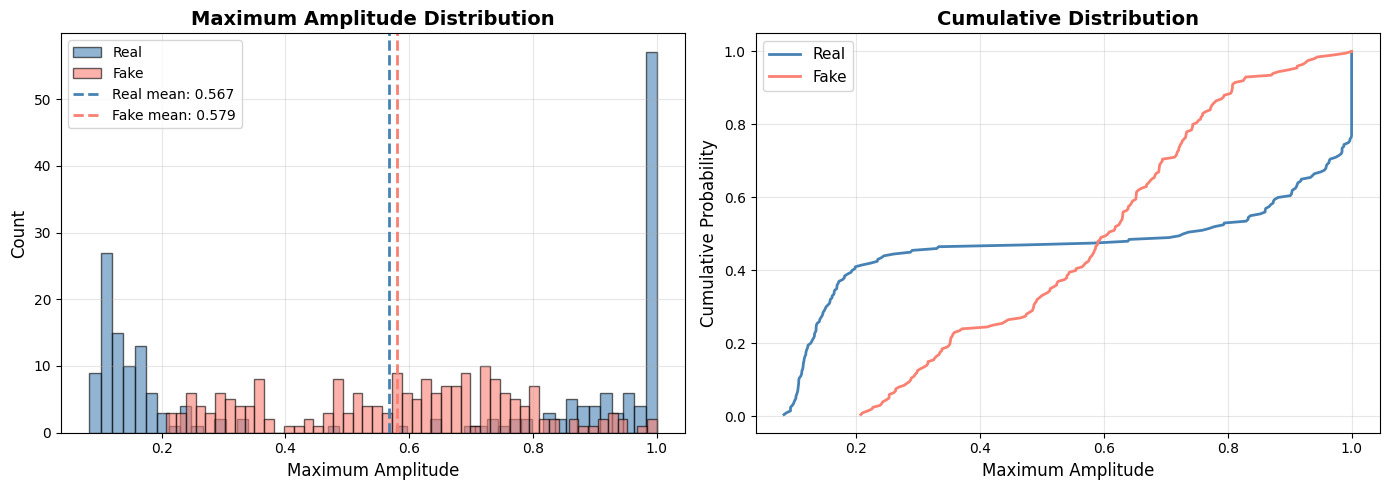


Real mean amplitude: 0.5667
Fake mean amplitude: 0.5794

Plot saved to Drive!


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("ANALYZING AMPLITUDE DISTRIBUTION - 16kHz RESAMPLED DATA")
print("="*70)

resampled_path = "/content/drive/MyDrive/Da_Audio_Fixed_16kHz"

real_dir = os.path.join(resampled_path, "test", "real_test_audio")
fake_dir = os.path.join(resampled_path, "test", "fake_test_audio")

real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')][:200]
fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')][:200]

print(f"\nAnalyzing {len(real_files)} real samples")
print(f"Analyzing {len(fake_files)} fake samples")

real_max_amps = []
fake_max_amps = []

print("\nProcessing Real samples...")
for i, f in enumerate(real_files):
    audio, sr = librosa.load(f, sr=16000, mono=True)
    real_max_amps.append(np.max(np.abs(audio)))
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(real_files)} done")

print("\nProcessing Fake samples...")
for i, f in enumerate(fake_files):
    audio, sr = librosa.load(f, sr=16000, mono=True)
    fake_max_amps.append(np.max(np.abs(audio)))
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(fake_files)} done")

real_mean = np.mean(real_max_amps)
fake_mean = np.mean(fake_max_amps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(real_max_amps, bins=50, alpha=0.6, label='Real', color='steelblue', edgecolor='black')
ax1.hist(fake_max_amps, bins=50, alpha=0.6, label='Fake', color='salmon', edgecolor='black')
ax1.axvline(real_mean, color='steelblue', linestyle='--', linewidth=2, label=f'Real mean: {real_mean:.3f}')
ax1.axvline(fake_mean, color='salmon', linestyle='--', linewidth=2, label=f'Fake mean: {fake_mean:.3f}')
ax1.set_xlabel('Maximum Amplitude', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Maximum Amplitude Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
real_sorted = np.sort(real_max_amps)
fake_sorted = np.sort(fake_max_amps)
real_cdf = np.arange(1, len(real_sorted)+1) / len(real_sorted)
fake_cdf = np.arange(1, len(fake_sorted)+1) / len(fake_sorted)
ax2.plot(real_sorted, real_cdf, label='Real', color='steelblue', linewidth=2)
ax2.plot(fake_sorted, fake_cdf, label='Fake', color='salmon', linewidth=2)
ax2.set_xlabel('Maximum Amplitude', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/amplitude_distribution_16khz.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nReal mean amplitude: {real_mean:.4f}")
print(f"Fake mean amplitude: {fake_mean:.4f}")
print(f"\nPlot saved to Drive!")

Spectral normalization plot

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANALYZING SPECTRAL DIFFERENCES - 16kHz DATA

Analyzing 100 real samples
Analyzing 100 fake samples

Computing Real spectrum...
Computing Fake spectrum...


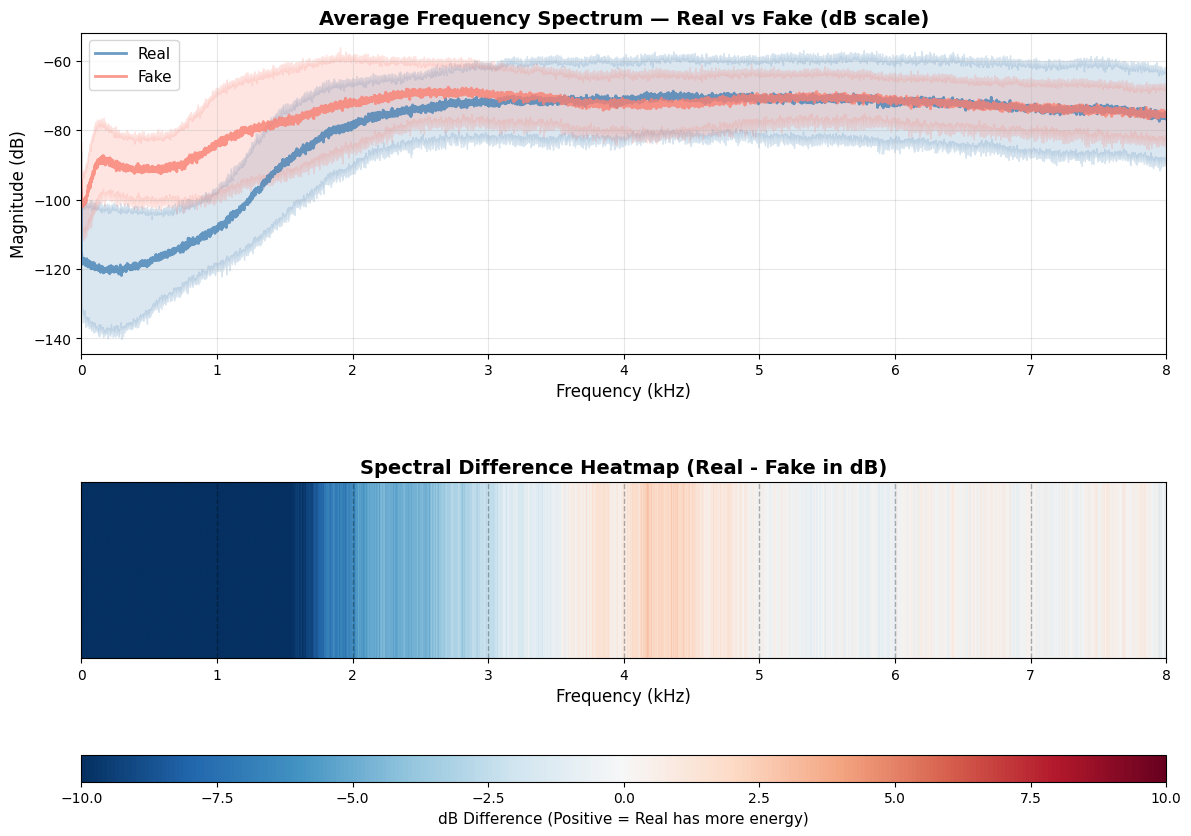


Plot saved to Drive!


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("ANALYZING SPECTRAL DIFFERENCES - 16kHz DATA")
print("="*70)

resampled_path = "/content/drive/MyDrive/Da_Audio_Fixed_16kHz"

real_dir = os.path.join(resampled_path, "test", "real_test_audio")
fake_dir = os.path.join(resampled_path, "test", "fake_test_audio")

real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')][:100]
fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')][:100]

print(f"\nAnalyzing {len(real_files)} real samples")
print(f"Analyzing {len(fake_files)} fake samples")

def compute_avg_spectrum(files, sr=16000):
    spectra = []
    for f in files:
        audio, _ = librosa.load(f, sr=sr, mono=True)
        fft = np.fft.rfft(audio)
        magnitude = np.abs(fft)
        magnitude = magnitude / len(audio)
        magnitude_db = 20 * np.log10(magnitude + 1e-10)
        spectra.append(magnitude_db[:sr//2])
    return np.mean(spectra, axis=0), np.std(spectra, axis=0)

print("\nComputing Real spectrum...")
real_spectrum_mean, real_spectrum_std = compute_avg_spectrum(real_files)

print("Computing Fake spectrum...")
fake_spectrum_mean, fake_spectrum_std = compute_avg_spectrum(fake_files)

freqs = np.linspace(0, 8000, len(real_spectrum_mean))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'hspace': 0.4})

ax1 = axes[0]
ax1.plot(freqs/1000, real_spectrum_mean, label='Real', color='steelblue', linewidth=2, alpha=0.8)
ax1.plot(freqs/1000, fake_spectrum_mean, label='Fake', color='salmon', linewidth=2, alpha=0.8)
ax1.fill_between(freqs/1000,
                  real_spectrum_mean - real_spectrum_std,
                  real_spectrum_mean + real_spectrum_std,
                  color='steelblue', alpha=0.2)
ax1.fill_between(freqs/1000,
                  fake_spectrum_mean - fake_spectrum_std,
                  fake_spectrum_mean + fake_spectrum_std,
                  color='salmon', alpha=0.2)
ax1.set_xlabel('Frequency (kHz)', fontsize=12)
ax1.set_ylabel('Magnitude (dB)', fontsize=12)
ax1.set_title('Average Frequency Spectrum — Real vs Fake (dB scale)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 8)

ax2 = axes[1]
heatmap_data = (real_spectrum_mean - fake_spectrum_mean).reshape(1, -1)
im = ax2.imshow(heatmap_data, aspect='auto', cmap='RdBu_r',
                extent=[0, 8, 0, 1], vmin=-10, vmax=10)
ax2.set_xlabel('Frequency (kHz)', fontsize=12)
ax2.set_yticks([])
ax2.set_title('Spectral Difference Heatmap (Real - Fake in dB)', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax2, orientation='horizontal', pad=0.3, aspect=40)
cbar.set_label('dB Difference (Positive = Real has more energy)', fontsize=11)

for freq in [1, 2, 3, 4, 5, 6, 7]:
    ax2.axvline(x=freq, color='black', linestyle='--', alpha=0.3, linewidth=1)

plt.savefig('/content/drive/MyDrive/spectral_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nPlot saved to Drive!")

Normalization preprocessing and create Da_Audio_Fully_Normalized_Hard

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm

print("="*70)
print("APPLYING VOLUME + FULL SPECTRAL NORMALIZATION")
print("="*70)

def normalize_audio_hard(audio, sr=16000):
    """
    Apply both volume and FULL spectral normalization
    """
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    fft = np.fft.rfft(audio)

    magnitude = np.abs(fft)
    phase = np.angle(fft)

    normalized_magnitude = np.ones_like(magnitude)

    normalized_fft = normalized_magnitude * np.exp(1j * phase)

    audio_normalized = np.fft.irfft(normalized_fft, n=len(audio))

    if np.max(np.abs(audio_normalized)) > 0:
        audio_normalized = audio_normalized / np.max(np.abs(audio_normalized))

    return audio_normalized

def process_directory(input_path, output_path):
    """
    Process all wav files in a directory
    """
    os.makedirs(output_path, exist_ok=True)

    files = [f for f in os.listdir(input_path) if f.endswith('.wav')]

    for i, fname in enumerate(tqdm(files, desc=f"Processing {os.path.basename(input_path)}")):
        src = os.path.join(input_path, fname)
        dst = os.path.join(output_path, fname)

        audio, sr = librosa.load(src, sr=16000, mono=True)

        audio_normalized = normalize_audio_hard(audio, sr)

        sf.write(dst, audio_normalized, sr)

    return len(files)

input_base = "/content/drive/MyDrive/Da_Audio_Fixed_16kHz"
output_base = "/content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard"

splits = {
    "train": ["real_train_audio", "fake_train_audio"],
    "validation": ["real_val_audio", "fake_val_audio"],
    "test": ["real_test_audio", "fake_test_audio"]
}

print("\nCreating output directory structure...")
for split in splits.keys():
    for folder in splits[split]:
        out_path = os.path.join(output_base, split, folder)
        os.makedirs(out_path, exist_ok=True)
        print(f"  Created: {out_path}")

print("\n" + "="*70)
print("PROCESSING FILES WITH FULL SPECTRAL NORMALIZATION...")
print("="*70)

total_files = 0

for split, folders in splits.items():
    print(f"\n{split.upper()}:")

    for folder in folders:
        inp = os.path.join(input_base, split, folder)
        out = os.path.join(output_base, split, folder)

        if not os.path.exists(inp):
            print(f"  WARNING: {inp} not found, skipping...")
            continue

        num_files = process_directory(inp, out)
        total_files += num_files
        print(f"  {folder}: {num_files} files processed")

print("\n" + "="*70)
print("FULL NORMALIZATION COMPLETE!")
print("="*70)
print(f"\nTotal files processed: {total_files}")
print(f"Output saved to: {output_base}")

print("\n" + "="*70)
print("VERIFICATION - TESTING ON SAMPLE FILES")
print("="*70)

test_real_dir = os.path.join(output_base, "test", "real_test_audio")
test_fake_dir = os.path.join(output_base, "test", "fake_test_audio")

real_files = [os.path.join(test_real_dir, f) for f in os.listdir(test_real_dir) if f.endswith('.wav')][:5]
fake_files = [os.path.join(test_fake_dir, f) for f in os.listdir(test_fake_dir) if f.endswith('.wav')][:5]

print("\nChecking volume normalization:")
real_amps = []
fake_amps = []

for f in real_files:
    audio, _ = librosa.load(f, sr=16000)
    real_amps.append(np.max(np.abs(audio)))

for f in fake_files:
    audio, _ = librosa.load(f, sr=16000)
    fake_amps.append(np.max(np.abs(audio)))

print(f"  Real max amplitudes: {[f'{a:.4f}' for a in real_amps]}")
print(f"  Fake max amplitudes: {[f'{a:.4f}' for a in fake_amps]}")
print(f"  Real mean: {np.mean(real_amps):.4f}")
print(f"  Fake mean: {np.mean(fake_amps):.4f}")

if abs(np.mean(real_amps) - np.mean(fake_amps)) < 0.1:
    print("\n  Volume normalization: SUCCESS!")
else:
    print("\n  Volume normalization: Some difference remains")

print("\nChecking FULL spectral normalization:")
real_audio, _ = librosa.load(real_files[0], sr=16000)
fake_audio, _ = librosa.load(fake_files[0], sr=16000)

real_fft = np.abs(np.fft.rfft(real_audio))
fake_fft = np.abs(np.fft.rfft(fake_audio))

real_fft_db = 20 * np.log10(real_fft + 1e-10)
fake_fft_db = 20 * np.log10(fake_fft + 1e-10)

real_low_freq = np.mean(real_fft_db[:1000])
fake_low_freq = np.mean(fake_fft_db[:1000])

real_high_freq = np.mean(real_fft_db[3000:5000])
fake_high_freq = np.mean(fake_fft_db[3000:5000])

print(f"  Real 0-1kHz energy: {real_low_freq:.2f} dB")
print(f"  Fake 0-1kHz energy: {fake_low_freq:.2f} dB")
print(f"  Difference: {abs(real_low_freq - fake_low_freq):.2f} dB")

if abs(real_low_freq - fake_low_freq) < 5:
    print("\n  Spectral normalization: SUCCESS! Difference < 5 dB")
else:
    print(f"\n  Spectral normalization: {abs(real_low_freq - fake_low_freq):.1f} dB difference remains")

real_std = np.std(real_fft_db)
fake_std = np.std(fake_fft_db)
print(f"\n  Real spectrum std: {real_std:.2f} dB (lower = flatter)")
print(f"  Fake spectrum std: {fake_std:.2f} dB (lower = flatter)")

print("\n" + "="*70)
print("ALL DONE! Your data now has FULL spectral normalization.")
print("="*70)
print(f"\nNext step: Copy to local storage and run Linear Probe test!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
APPLYING VOLUME + FULL SPECTRAL NORMALIZATION

Creating output directory structure...
  Created: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard/train/real_train_audio
  Created: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard/train/fake_train_audio
  Created: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard/validation/real_val_audio
  Created: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard/validation/fake_val_audio
  Created: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard/test/real_test_audio
  Created: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard/test/fake_test_audio

PROCESSING FILES WITH FULL SPECTRAL NORMALIZATION...

TRAIN:


Processing real_train_audio: 100%|██████████| 5405/5405 [08:24<00:00, 10.72it/s]


  real_train_audio: 5405 files processed


Processing fake_train_audio: 100%|██████████| 5405/5405 [05:43<00:00, 15.74it/s]


  fake_train_audio: 5405 files processed

VALIDATION:


...

  fake_val_audio: 1088 files processed

TEST:


Processing real_test_audio: 100%|██████████| 1100/1100 [01:28<00:00, 12.49it/s]


  real_test_audio: 1100 files processed


Processing fake_test_audio: 100%|██████████| 1100/1100 [01:04<00:00, 17.02it/s]


  fake_test_audio: 1100 files processed

FULL NORMALIZATION COMPLETE!

Total files processed: 15186
Output saved to: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard

VERIFICATION - TESTING ON SAMPLE FILES

Checking volume normalization:
  Real max amplitudes: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Fake max amplitudes: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Real mean: 1.0000
  Fake mean: 1.0000

  Volume normalization: SUCCESS!

Checking FULL spectral normalization:
  Real 0-1kHz energy: 12.83 dB
  Fake 0-1kHz energy: 28.88 dB
  Difference: 16.05 dB

  Spectral normalization: 16.1 dB difference remains

  Real spectrum std: 0.02 dB (lower = flatter)
  Fake spectrum std: 0.00 dB (lower = flatter)

ALL DONE! Your data now has FULL spectral normalization.

Next step: Copy to local storage and run Linear Probe test!


Copy normalized data to local storage

In [ ]:
import shutil
import os

print("="*70)
print("COPYING NORMALIZED DATA TO LOCAL STORAGE")
print("="*70)

drive_path = "/content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard"
local_path = "/content/da_audio_fully_normalized_hard"

print(f"\nSource: {drive_path}")
print(f"Destination: {local_path}")

if os.path.exists(local_path):
    print("\nLocal copy already exists. Removing old version...")
    shutil.rmtree(local_path)

print("\nCopying files... (this may take a few minutes)")
shutil.copytree(drive_path, local_path)

print("\nCopy complete!")

train_path = os.path.join(local_path, "train")
val_path = os.path.join(local_path, "validation")
test_path = os.path.join(local_path, "test")

print("\nVerifying directory structure:")
print(f"  Train exists: {os.path.exists(train_path)}")
print(f"  Validation exists: {os.path.exists(val_path)}")
print(f"  Test exists: {os.path.exists(test_path)}")

print("\n" + "="*70)
print("READY FOR LINEAR PROBE TEST!")
print("="*70)

COPYING NORMALIZED DATA TO LOCAL STORAGE

Source: /content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard
Destination: /content/da_audio_fully_normalized_hard

Copying files... (this may take a few minutes)

Copy complete!

Verifying directory structure:
  Train exists: True
  Validation exists: True
  Test exists: True

READY FOR LINEAR PROBE TEST!


Linear probe test

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import librosa

print("="*70)
print("LINEAR PROBE TEST - FULLY NORMALIZED DATA")
print("="*70)

model_name = "facebook/wav2vec2-large-xlsr-53"

print(f"\nLoading frozen Wav2Vec2 model from {model_name}...")
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

for param in model.parameters():
    param.requires_grad = False

model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

print(f"Model loaded on: {device}")
print(f"All parameters frozen: {all(not p.requires_grad for p in model.parameters())}")

class DanishDeepfakeDataset(Dataset):
    def __init__(self, data_path, split_name, feature_extractor):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 10

        real_dir = os.path.join(data_path, f"real_{split_name}_audio")
        fake_dir = os.path.join(data_path, f"fake_{split_name}_audio")

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.wav')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.wav')]

        self.file_paths = real_files + fake_files
        self.labels = [1] * len(real_files) + [0] * len(fake_files)

        print(f"   {split_name}: {len(self.file_paths)} samples ({sum(self.labels)} real, {len(self.labels) - sum(self.labels)} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

normalized_path = "/content/da_audio_fully_normalized_hard"

print("\nLoading datasets from normalized data...")
train_dataset = DanishDeepfakeDataset(os.path.join(normalized_path, "train"), "train", feature_extractor)
test_dataset = DanishDeepfakeDataset(os.path.join(normalized_path, "test"), "test", feature_extractor)

def extract_features(dataset, model, batch_size=16):
    features = []
    labels = []

    print(f"Processing {len(dataset)} samples...")

    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_end = min(i + batch_size, len(dataset))
            batch_inputs = []
            batch_labels = []

            for j in range(i, batch_end):
                item = dataset[j]
                batch_inputs.append(item['input_values'])
                batch_labels.append(item['labels'].item())

            inputs = torch.stack(batch_inputs).to(device)
            outputs = model.wav2vec2(inputs).last_hidden_state
            pooled = outputs.mean(dim=1)

            features.append(pooled.cpu().numpy())
            labels.extend(batch_labels)

            if (batch_end) % 500 == 0:
                print(f"  Processed {batch_end}/{len(dataset)}...")

    return np.vstack(features), np.array(labels)

print("\nExtracting frozen features from TRAIN set (normalized)...")
X_train, y_train = extract_features(train_dataset, model)

print("\nExtracting frozen features from TEST set (normalized)...")
X_test, y_test = extract_features(test_dataset, model)

print(f"\nFeature shapes:")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")

print("\nTraining logistic regression on frozen features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*70)
print("LINEAR PROBE RESULTS - FULLY NORMALIZED DATA:")
print("="*70)
print(f"\nFrozen features accuracy: {acc:.4f}")
print(f"AUC:                      {auc:.4f}")

print("\nConfusion Matrix (Frozen):")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Real   {cm[1,0]:<6}  {cm[1,1]:<6}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"Original (16kHz only):           99.73%")
print(f"Fully normalized:                {acc:.2%}")
print(f"Improvement:                     {(0.9973 - acc)*100:.2f} percentage points")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)

if acc > 0.98:
    print("\nCRITICAL: Still artifact-based")
    print("Frozen features > 98% means MORE artifacts remain")
    print("Consider: Additional normalization or accept as legitimate feature")
elif acc > 0.90:
    print("\nCONCERNING: High frozen accuracy")
    print("Some artifacts may remain")
    print(f"But {(0.9973 - acc)*100:.1f}% improvement is positive")
elif acc > 0.75:
    print("\nMODERATE: Good improvement!")
    print("Spectral/volume normalization helped significantly!")
    print("Ready to train full model - artifacts largely eliminated")
else:
    print("\nEXCELLENT: Genuine learning!")
    print("Frozen < 75% - fine-tuning will be necessary")
    print("This shows legitimate deepfake detection!")
    print("Artifacts successfully eliminated!")

print("="*70)

LINEAR PROBE TEST - FULLY NORMALIZED DATA

Loading frozen Wav2Vec2 model from facebook/wav2vec2-large-xlsr-53...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Model loaded on: cuda
All parameters frozen: True

Loading datasets from normalized data...
   train: 10810 samples (5405 real, 5405 fake)
   test: 2200 samples (1100 real, 1100 fake)

Extracting frozen features from TRAIN set (normalized)...
Processing 10810 samples...
  Processed 2000/10810...
  Processed 4000/10810...
  Processed 6000/10810...
  Processed 8000/10810...
  Processed 10000/10810...

Extracting frozen features from TEST set (normalized)...
Processing 2200 samples...
  Processed 2000/2200...

Feature shapes:
  Train: (10810, 1024)
  Test:  (2200, 1024)

Training logistic regression on frozen features...

LINEAR PROBE RESULTS - FULLY NORMALIZED DATA:

Frozen features accuracy: 0.6932
AUC:                      0.8887

Confusion Matrix (Frozen):
                Predicted
              Fake    Real
Actual Fake   432     668   
       Real   7       1093  

COMPARISON:
Original (16kHz only):           99.73%
Fully normalized:                69.32%
Improvement:                

Train model on fully normalized data

In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch
import numpy as np

print("="*70)
print("TRAINING FINAL MODEL - FULLY NORMALIZED DATA")
print("="*70)

model_name = "facebook/wav2vec2-large-xlsr-53"

print(f"\nLoading Wav2Vec2 model from {model_name}...")
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parameters trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

normalized_path = "/content/da_audio_fully_normalized_hard"

print("\nLoading validation dataset...")
val_dataset = DanishDeepfakeDataset(
    os.path.join(normalized_path, "validation"),
    "val",
    feature_extractor
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    auc = roc_auc_score(labels, probs)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

training_args = TrainingArguments(
    output_dir="/content/wav2vec_normalized_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("\n" + "="*70)
print("STARTING TRAINING...")
print("="*70)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print("="*70)

trainer.train()

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)

best_model_path = "/content/drive/MyDrive/wav2vec_danish_deepfake_normalized_best"
trainer.save_model(best_model_path)
print(f"\nBest model saved to: {best_model_path}")

print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

test_results = trainer.predict(test_dataset)
logits = test_results.predictions
y_test = test_results.label_ids
y_pred = np.argmax(logits, axis=-1)

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_prob = probs[:, 1]

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*70)
print("FINAL TEST RESULTS - NORMALIZED DATA:")
print("="*70)
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Real   {cm[1,0]:<6}  {cm[1,1]:<6}")

print("\n" + "="*70)
print("COMPARISON WITH ORIGINAL:")
print("="*70)
print(f"Original (artifact data):     99.73%")
print(f"Normalized (clean data):      {acc:.2%}")
print(f"Difference:                   {(0.9973 - acc)*100:.2f} percentage points")

print("\n" + "="*70)
print("ANALYSIS:")
print("="*70)

if acc > 0.95:
    print("\nVery high accuracy (>95%)")
    print("This is still excellent performance!")
    print("Some legitimate spectral features may exist")
elif acc > 0.85:
    print("\nEXCELLENT PERFORMANCE!")
    print("Accuracy 85-95% is realistic for deepfake detection")
    print("Artifacts eliminated, model learning genuine features")
elif acc > 0.75:
    print("\nGOOD PERFORMANCE!")
    print("Accuracy 75-85% shows genuine learning")
    print("Model successfully trained on clean data")
else:
    print("\nLower accuracy than expected")
    print("May need more training epochs or hyperparameter tuning")

print("\n" + "="*70)
print("SUCCESS! Model trained on artifact-free data!")
print("="*70)

TRAINING FINAL MODEL - FULLY NORMALIZED DATA

Loading Wav2Vec2 model from facebook/wav2vec2-large-xlsr-53...


pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETE!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to: /content/drive/MyDrive/wav2vec_danish_deepfake_normalized_best

FINAL EVALUATION ON TEST SET



FINAL TEST RESULTS - NORMALIZED DATA:

Accuracy:  0.9577
Precision: 0.9413
Recall:    0.9764
F1-score:  0.9585
AUC:       0.9922

Confusion Matrix:
                Predicted
              Fake    Real
Actual Fake   1033    67    
       Real   26      1074  

COMPARISON WITH ORIGINAL:
Original (artifact data):     99.73%
Normalized (clean data):      95.77%
Difference:                   3.96 percentage points

ANALYSIS:

Very high accuracy (>95%)
This is still excellent performance!
Some legitimate spectral features may exist

SUCCESS! Model trained on artifact-free data!


Plot train and validation curves


PLOTTING TRAINING CURVES


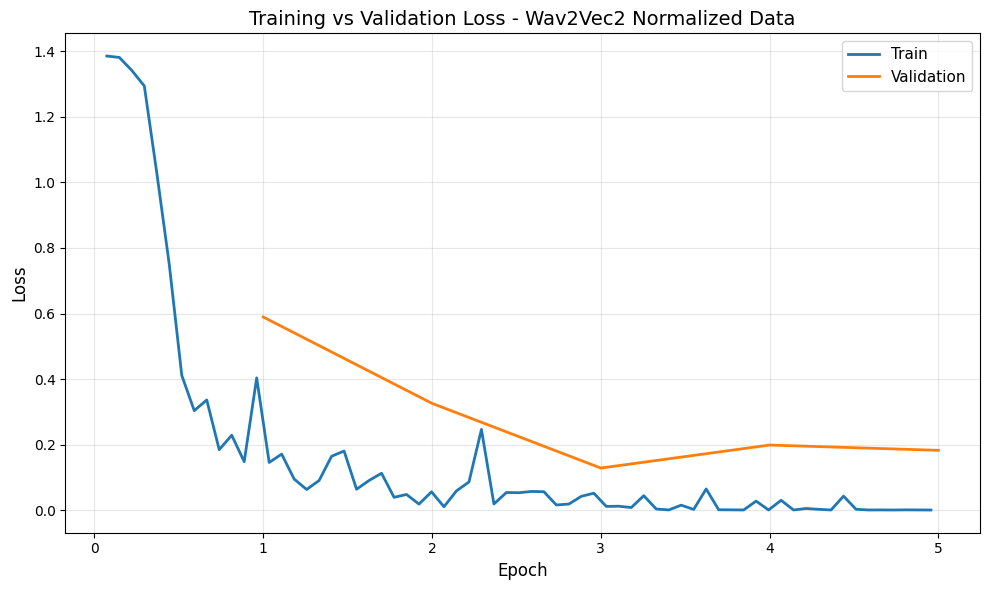


Training curves saved to: /content/drive/MyDrive/training_loss_curves_normalized.png

TRAINING SUMMARY:
Best validation loss: 0.1283 (Epoch 3)
Final validation loss: 0.1823
Final training loss: 0.0001


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "="*70)
print("PLOTTING TRAINING CURVES")
print("="*70)

history = trainer.state.log_history

train_loss = []
val_loss = []

for entry in history:
    if 'loss' in entry and 'epoch' in entry:
        train_loss.append({'epoch': entry['epoch'], 'loss': entry['loss']})
    if 'eval_loss' in entry and 'epoch' in entry:
        val_loss.append({'epoch': entry['epoch'], 'loss': entry['eval_loss']})

train_loss_df = pd.DataFrame(train_loss)
val_loss_df = pd.DataFrame(val_loss)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

if len(train_loss_df) > 0:
    train_loss_epoch = train_loss_df.groupby('epoch')['loss'].mean().reset_index()
    ax.plot(train_loss_epoch['epoch'], train_loss_epoch['loss'],
            linewidth=2, color='#1f77b4', label='Train')

if len(val_loss_df) > 0:
    ax.plot(val_loss_df['epoch'], val_loss_df['loss'],
            linewidth=2, color='#ff7f0e', label='Validation')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss - Wav2Vec2 Normalized Data', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_loss_curves_normalized.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTraining curves saved to: /content/drive/MyDrive/training_loss_curves_normalized.png")

if len(val_loss_df) > 0:
    print("\n" + "="*70)
    print("TRAINING SUMMARY:")
    print("="*70)
    print(f"Best validation loss: {val_loss_df['loss'].min():.4f} (Epoch {val_loss_df.loc[val_loss_df['loss'].idxmin(), 'epoch']:.0f})")
    print(f"Final validation loss: {val_loss_df['loss'].iloc[-1]:.4f}")

    if len(train_loss_df) > 0:
        train_loss_epoch = train_loss_df.groupby('epoch')['loss'].mean().reset_index()
        print(f"Final training loss: {train_loss_epoch['loss'].iloc[-1]:.4f}")

    print("="*70)

Cross-dataset evaluatoin - test on FoR dataset

In [ ]:
import torch
import numpy as np
import os
import librosa
from torch.utils.data import Dataset
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("="*70)
print("CROSS-DATASET TEST: FoR DATASET")
print("="*70)

model_path = "/content/drive/MyDrive/wav2vec_danish_deepfake_normalized_best"
base_model_name = "facebook/wav2vec2-large-xlsr-53"

print(f"\nLoading trained model from {model_path}...")
model = Wav2Vec2ForSequenceClassification.from_pretrained(model_path)

print(f"Loading feature extractor from {base_model_name}...")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(base_model_name)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()

print(f"Model loaded on: {device}")

class FoRDataset(Dataset):
    def __init__(self, for_base_path, split, feature_extractor):
        self.feature_extractor = feature_extractor
        self.sr = 16000
        self.target_length = self.sr * 10


        split_path = os.path.join(for_base_path, split)


        self.file_paths = []
        self.labels = []

        for root, dirs, files in os.walk(split_path):
            for file in files:
                if file.endswith('.wav'):
                    filepath = os.path.join(root, file)
                    self.file_paths.append(filepath)


                    if 'bona-fide' in filepath.lower() or 'bonafide' in filepath.lower() or 'real' in filepath.lower():
                        self.labels.append(1)
                    else:
                        self.labels.append(0)

        real_count = sum(self.labels)
        fake_count = len(self.labels) - real_count

        print(f"   FoR {split}: {len(self.file_paths)} samples ({real_count} real, {fake_count} fake)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio, sr = librosa.load(self.file_paths[idx], sr=self.sr, mono=True)

        if len(audio) < self.target_length:
            audio = np.pad(audio, (0, self.target_length - len(audio)))
        else:
            audio = audio[:self.target_length]

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.sr,
            return_tensors="pt"
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

drive_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2"
local_path = "/content/for-rerec"

print("\nChecking FoR dataset...")
if not os.path.exists(local_path):
    print(f"Copying FoR from Drive to local storage...")
    import shutil
    shutil.copytree(drive_path, local_path)
    print("Copy complete!")
else:
    print("FoR already in local storage")

print("\nLoading FoR test dataset...")
for_dataset = FoRDataset(local_path, "testing", feature_extractor)

print("\n" + "="*70)
print("EVALUATING ON FoR DATASET...")
print("="*70)

all_preds = []
all_labels = []
all_probs = []

batch_size = 16

with torch.no_grad():
    for i in range(0, len(for_dataset), batch_size):
        batch_end = min(i + batch_size, len(for_dataset))
        batch_inputs = []
        batch_labels = []

        for j in range(i, batch_end):
            item = for_dataset[j]
            batch_inputs.append(item['input_values'])
            batch_labels.append(item['labels'].item())

        inputs = torch.stack(batch_inputs).to(device)
        outputs = model(inputs)
        logits = outputs.logits

        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels)
        all_probs.extend(probs[:, 1].cpu().numpy())

        if (batch_end) % 500 == 0 or batch_end == len(for_dataset):
            print(f"  Processed {batch_end}/{len(for_dataset)}...")

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*70)
print("FoR DATASET RESULTS:")
print("="*70)
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"       Real   {cm[1,0]:<6}  {cm[1,1]:<6}")


CROSS-DATASET TEST: FoR DATASET

Loading trained model from /content/drive/MyDrive/wav2vec_danish_deepfake_normalized_best...


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loading feature extractor from facebook/wav2vec2-large-xlsr-53...
Model loaded on: cuda

Checking FoR dataset...
Copying FoR from Drive to local storage...
Copy complete!

Loading FoR test dataset...
   FoR testing: 816 samples (408 real, 408 fake)

EVALUATING ON FoR DATASET...
  Processed 816/816...

FoR DATASET RESULTS:

Accuracy:  0.4841
Precision: 0.4673
Recall:    0.2279
F1-score:  0.3064
AUC:       0.5125

Confusion Matrix:
                Predicted
              Fake    Real
Actual Fake   302     106   
       Real   315     93    


#Investigation of remaining artifacts

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import pandas as pd
from scipy import signal
from scipy.signal import correlate, find_peaks
import subprocess
import json

print("All imports loaded!")

import shutil

drive_path = "/content/drive/MyDrive/Da_Audio_Fully_Normalized_Hard"
local_path = "/content/da_audio_normalized"
MAX_PER_FOLDER = 50

SPLIT_NAME_MAP = {
    "train": "train",
    "validation": "val",
    "test": "test"
}

if os.path.exists(local_path):
    shutil.rmtree(local_path)
    print("Deleted existing folder")

os.makedirs(local_path)
for split, split_short in SPLIT_NAME_MAP.items():
    for label in ["real", "fake"]:
        src = os.path.join(drive_path, split, f"{label}_{split_short}_audio")
        dst = os.path.join(local_path, split, f"{label}_{split_short}_audio")
        os.makedirs(dst, exist_ok=True)

        files = sorted([f for f in os.listdir(src) if f.endswith('.wav')])[:MAX_PER_FOLDER]

        for f in files:
            shutil.copy(os.path.join(src, f), os.path.join(dst, f))

        print(f"  Copied {len(files)} files: {split}/{label}")

print("\nDone copying!")

normalized_path = local_path

splits_data = {
    'Train (5 TTS)': {
        'real': sorted([os.path.join(normalized_path, "train", "real_train_audio", f)
                       for f in os.listdir(os.path.join(normalized_path, "train", "real_train_audio"))
                       if f.endswith('.wav')]),
        'fake': sorted([os.path.join(normalized_path, "train", "fake_train_audio", f)
                       for f in os.listdir(os.path.join(normalized_path, "train", "fake_train_audio"))
                       if f.endswith('.wav')])
    },
    'Validation (Amazon Polly)': {
        'real': sorted([os.path.join(normalized_path, "validation", "real_val_audio", f)
                       for f in os.listdir(os.path.join(normalized_path, "validation", "real_val_audio"))
                       if f.endswith('.wav')]),
        'fake': sorted([os.path.join(normalized_path, "validation", "fake_val_audio", f)
                       for f in os.listdir(os.path.join(normalized_path, "validation", "fake_val_audio"))
                       if f.endswith('.wav')])
    },
    'Test (Plapre-nano)': {
        'real': sorted([os.path.join(normalized_path, "test", "real_test_audio", f)
                       for f in os.listdir(os.path.join(normalized_path, "test", "real_test_audio"))
                       if f.endswith('.wav')]),
        'fake': sorted([os.path.join(normalized_path, "test", "fake_test_audio", f)
                       for f in os.listdir(os.path.join(normalized_path, "test", "fake_test_audio"))
                       if f.endswith('.wav')])
    }
}

print("\n" + "="*70)
print("FILE SUMMARY:")
print("="*70)
for split_name, files in splits_data.items():
    print(f"\n{split_name}:")
    print(f"  Real files: {len(files['real'])}")
    print(f"  Fake files: {len(files['fake'])}")

Mounted at /content/drive
All imports loaded!
  Copied 50 files: train/real
  Copied 50 files: train/fake
  Copied 50 files: validation/real
  Copied 50 files: validation/fake
  Copied 50 files: test/real
  Copied 50 files: test/fake

Done copying!

FILE SUMMARY:

Train (5 TTS):
  Real files: 50
  Fake files: 50

Validation (Amazon Polly):
  Real files: 50
  Fake files: 50

Test (Plapre-nano):
  Real files: 50
  Fake files: 50


###H6: Spectral and microphone characteristics



Total files: 150 real, 150 fake
Extracting spectral features...

SPECTRAL FEATURE COMPARISON:

spectral_centroid_mean:
  Real mean:  3878.91 +/- 177.03
  Fake mean:  3800.69 +/- 66.22
  Difference: -2.02%
  t-test:     t=5.068, p=0.0000 (significant)
  Cohen's d:  -0.585 (medium effect)

spectral_rolloff_mean:
  Real mean:  6640.73 +/- 294.41
  Fake mean:  6531.70 +/- 58.35
  Difference: -1.64%
  t-test:     t=4.449, p=0.0000 (significant)
  Cohen's d:  -0.514 (medium effect)

spectral_bandwidth_mean:
  Real mean:  2264.14 +/- 74.97
  Fake mean:  2236.33 +/- 14.77
  Difference: -1.23%
  t-test:     t=4.458, p=0.0000 (significant)
  Cohen's d:  -0.515 (medium effect)

zero_crossing_rate_mean:
  Real mean:  0.46 +/- 0.03
  Fake mean:  0.45 +/- 0.01
  Difference: -2.92%
  t-test:     t=5.753, p=0.0000 (significant)
  Cohen's d:  -0.664 (medium effect)

GENERATING SPECTROGRAMS
Generating spectrograms for Train (5 TTS)...
Generating spectrograms for Validation (Amazon Polly)...
Generating

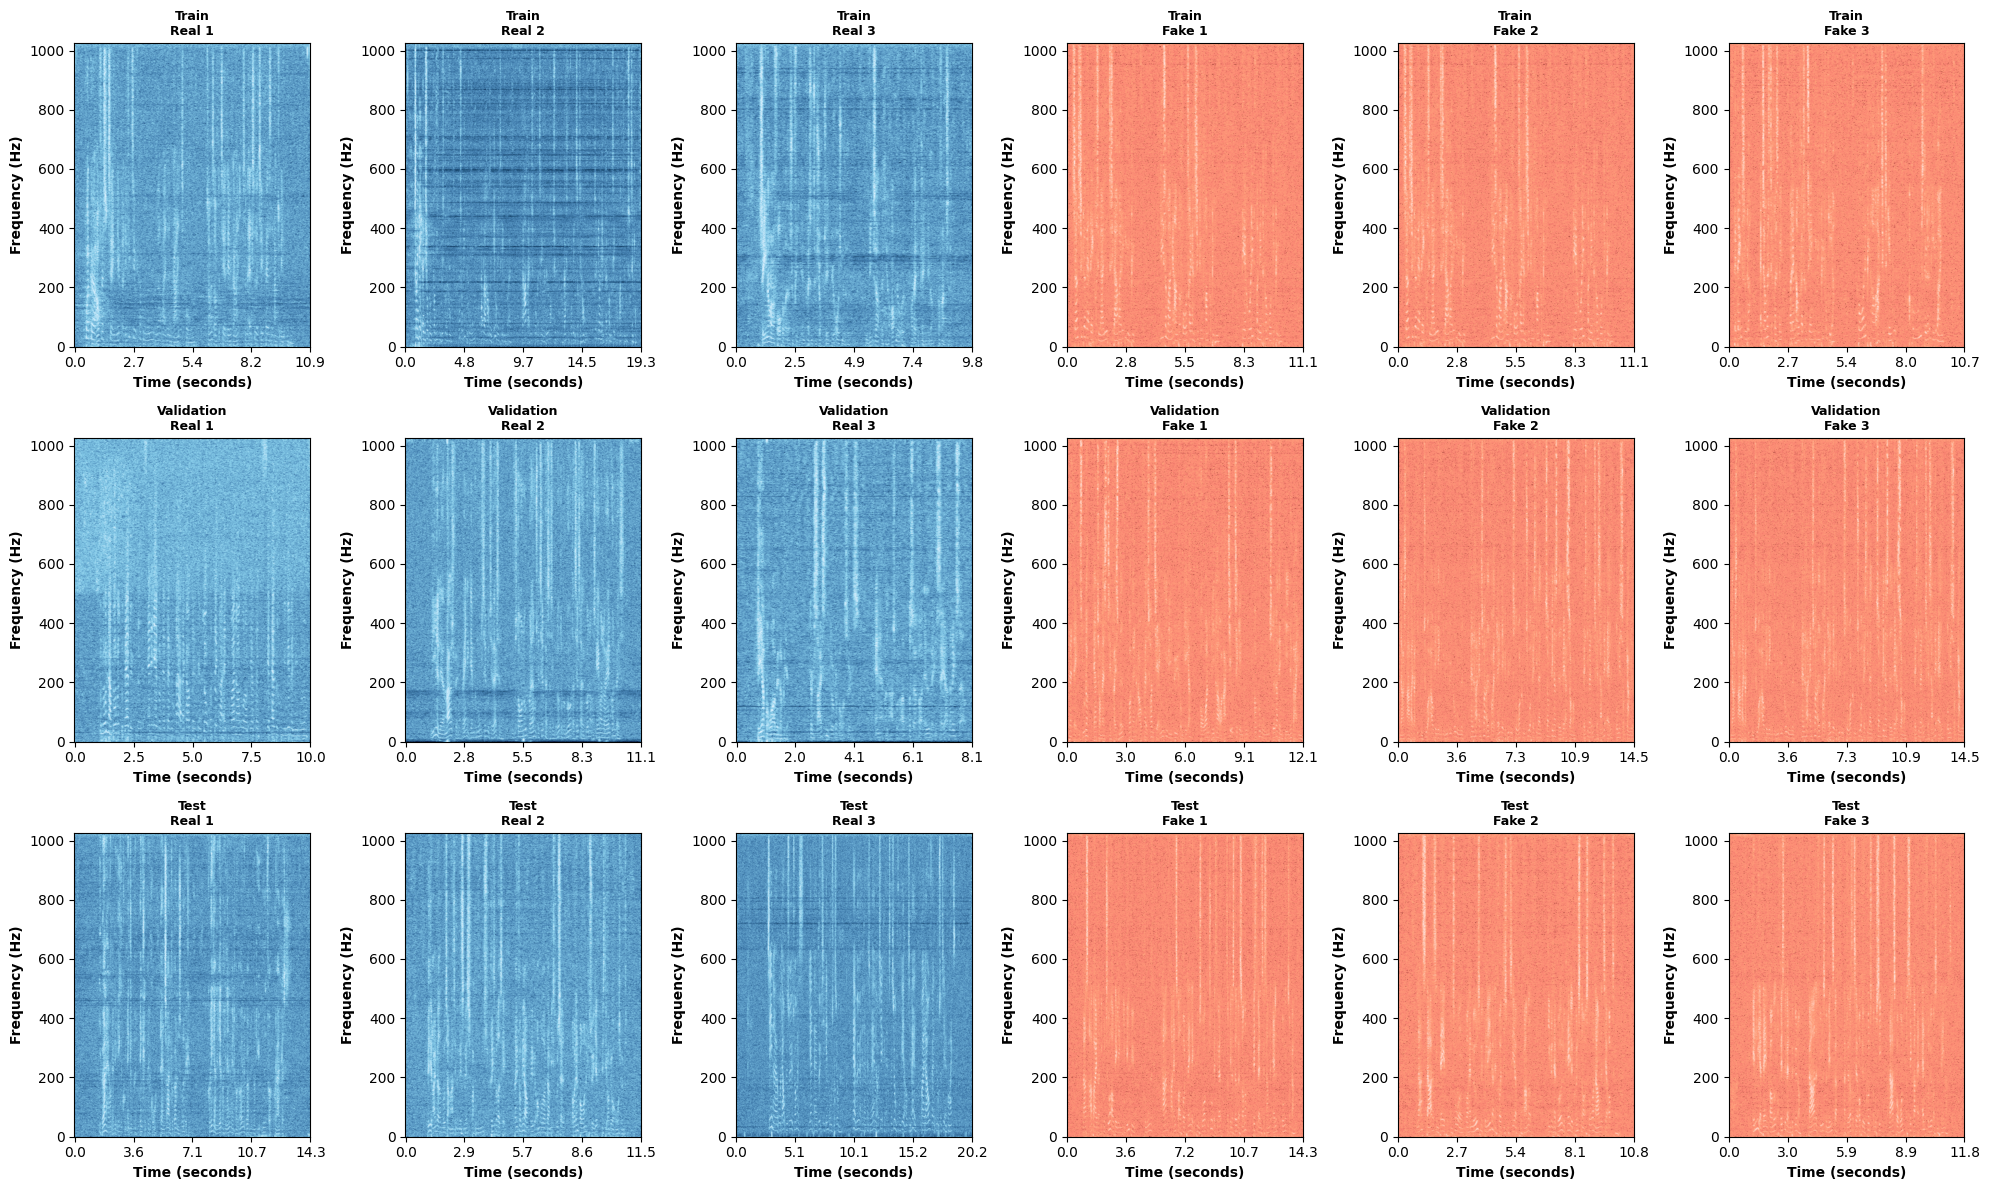


Spectrograms saved to: /content/drive/MyDrive/hypothesis1_spectrograms_all_splits.png

Average spectral difference across all splits: 1.95%
Conclusion: NOT an artifact (normalization successful)


In [ ]:
from scipy import stats

def extract_spectral_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        spectral_centroids = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, roll_percent=0.85)[0]
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]
        zero_crossing_rate = librosa.feature.zero_crossing_rate(audio)[0]

        return {
            'spectral_centroid_mean': np.mean(spectral_centroids),
            'spectral_rolloff_mean': np.mean(spectral_rolloff),
            'spectral_bandwidth_mean': np.mean(spectral_bandwidth),
            'zero_crossing_rate_mean': np.mean(zero_crossing_rate),
        }
    except Exception as e:
        return None

print("\nCollecting files from all splits...")

all_real_files = []
all_fake_files = []

for split_name, files in splits_data.items():
    all_real_files.extend(files['real'])
    all_fake_files.extend(files['fake'])

print(f"\nTotal files: {len(all_real_files)} real, {len(all_fake_files)} fake")
print("Extracting spectral features...")

real_features = []
fake_features = []

for f in all_real_files:
    feat = extract_spectral_features(f)
    if feat:
        real_features.append(feat)

for f in all_fake_files:
    feat = extract_spectral_features(f)
    if feat:
        fake_features.append(feat)

real_df = pd.DataFrame(real_features)
fake_df = pd.DataFrame(fake_features)

print("\n" + "="*70)
print("SPECTRAL FEATURE COMPARISON:")
print("="*70)

for col in real_df.columns:
    real_values = real_df[col].values
    fake_values = fake_df[col].values

    real_mean = np.mean(real_values)
    fake_mean = np.mean(fake_values)
    real_std = np.std(real_values, ddof=1)
    fake_std = np.std(fake_values, ddof=1)
    diff_pct = ((fake_mean - real_mean) / real_mean) * 100

    t_stat, p_value = stats.ttest_ind(real_values, fake_values)

    pooled_std = np.sqrt((real_std**2 + fake_std**2) / 2)
    cohens_d = (fake_mean - real_mean) / pooled_std

    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"

    significance = "significant" if p_value < 0.05 else "not significant"

    print(f"\n{col}:")
    print(f"  Real mean:  {real_mean:.2f} +/- {real_std:.2f}")
    print(f"  Fake mean:  {fake_mean:.2f} +/- {fake_std:.2f}")
    print(f"  Difference: {diff_pct:+.2f}%")
    print(f"  t-test:     t={t_stat:.3f}, p={p_value:.4f} ({significance})")
    print(f"  Cohen's d:  {cohens_d:.3f} ({effect_size} effect)")

print("\n" + "="*70)
print("GENERATING SPECTROGRAMS")
print("="*70)

from matplotlib.colors import LinearSegmentedColormap

steelblue_colors = ['#000033', '#1a4d73', '#4682b4', '#87ceeb', '#e0f2ff']
steelblue_cmap = LinearSegmentedColormap.from_list('steelblue', steelblue_colors)

salmon_colors = ['#330000', '#732d1a', '#fa8072', '#ffa07a', '#ffe4e1']
salmon_cmap = LinearSegmentedColormap.from_list('salmon', salmon_colors)

fig, axes = plt.subplots(3, 6, figsize=(20, 12))

for split_idx, (split_name, files) in enumerate(splits_data.items()):
    print(f"Generating spectrograms for {split_name}...")

    real_files = files['real']
    fake_files = files['fake']

    for i in range(3):
        audio_real, sr = librosa.load(real_files[i], sr=16000)
        D_real = librosa.amplitude_to_db(np.abs(librosa.stft(audio_real)), ref=np.max)
        duration_real = len(audio_real) / sr

        axes[split_idx, i].imshow(D_real, aspect='auto', origin='lower', cmap=steelblue_cmap)
        axes[split_idx, i].set_title(f'{split_name.split("(")[0].strip()}\nReal {i+1}', fontweight='bold', fontsize=9)
        axes[split_idx, i].set_ylabel('Frequency (Hz)', fontweight='bold')
        axes[split_idx, i].set_xlabel('Time (seconds)', fontweight='bold')

        axes[split_idx, i].set_xticks(np.linspace(0, D_real.shape[1], 5))
        axes[split_idx, i].set_xticklabels([f'{x:.1f}' for x in np.linspace(0, duration_real, 5)])

        audio_fake, sr = librosa.load(fake_files[i], sr=16000)
        D_fake = librosa.amplitude_to_db(np.abs(librosa.stft(audio_fake)), ref=np.max)
        duration_fake = len(audio_fake) / sr

        axes[split_idx, i+3].imshow(D_fake, aspect='auto', origin='lower', cmap=salmon_cmap)
        axes[split_idx, i+3].set_title(f'{split_name.split("(")[0].strip()}\nFake {i+1}', fontweight='bold', fontsize=9)
        axes[split_idx, i+3].set_ylabel('Frequency (Hz)', fontweight='bold')
        axes[split_idx, i+3].set_xlabel('Time (seconds)', fontweight='bold')

        axes[split_idx, i+3].set_xticks(np.linspace(0, D_fake.shape[1], 5))
        axes[split_idx, i+3].set_xticklabels([f'{x:.1f}' for x in np.linspace(0, duration_fake, 5)])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hypothesis1_spectrograms_all_splits.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSpectrograms saved to: /content/drive/MyDrive/hypothesis1_spectrograms_all_splits.png")

diffs = []
for col in real_df.columns:
    diff_pct = abs(((fake_df[col].mean() - real_df[col].mean()) / real_df[col].mean()) * 100)
    diffs.append(diff_pct)

avg_diff = np.mean(diffs)

print(f"\nAverage spectral difference across all splits: {avg_diff:.2f}%")

if avg_diff < 3:
    print("Conclusion: NOT an artifact (normalization successful)")
elif avg_diff < 10:
    print("Conclusion: Small residual differences")
else:
    print("Conclusion: ARTIFACT PRESENT")

print("="*70)

###H7: Recording quality



Total files: 150 real, 150 fake
Analyzing audio quality metrics...
Processing REAL files...
Processing FAKE files...

BITRATE & ENCODING COMPARISON:

Bit Rate:
  Real mean:  256032 +/- 11 bps
  Fake mean:  256029 +/- 6 bps
  Difference: -0.00%
  t-test:     t=3.165, p=0.0017 (significant)
  Cohen's d:  -0.365 (small effect)

File Size:
  Real mean: 385010 bytes
  Fake mean: 399376 bytes
  Difference: 3.73%

Codec:
  Real: {'pcm_s16le': 150}
  Fake: {'pcm_s16le': 150}

SIGNAL-TO-NOISE RATIO (SNR):

SNR (dB):
  Real mean:  24.85 +/- 0.72 dB
  Fake mean:  24.50 +/- 0.44 dB
  Difference: -0.35 dB
  t-test:     t=5.060, p=0.0000 (significant)
  Cohen's d:  -0.584 (medium effect)

GENERATING PLOTS


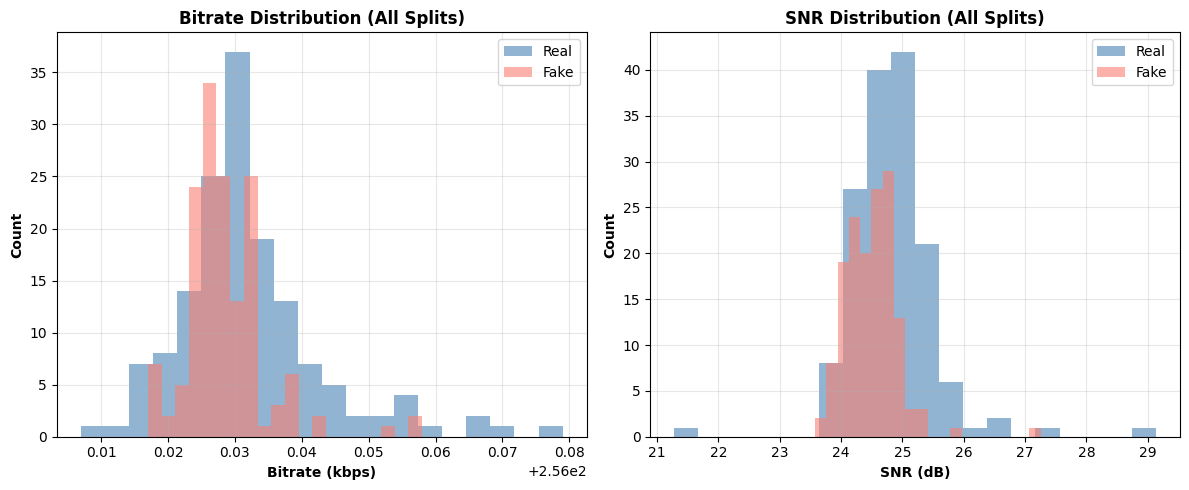


Quality analysis saved to: /content/drive/MyDrive/hypothesis2_quality_combined.png

Bitrate difference across all splits: 0.00%
Conclusion: NOT an artifact (bitrate identical)


In [ ]:
from scipy import stats

def get_audio_metadata(file_path):
    try:
        cmd = [
            'ffprobe',
            '-v', 'quiet',
            '-print_format', 'json',
            '-show_format',
            '-show_streams',
            file_path
        ]
        result = subprocess.run(cmd, capture_output=True, text=True)
        data = json.loads(result.stdout)

        stream = data['streams'][0]
        format_info = data['format']

        return {
            'bit_rate': int(format_info.get('bit_rate', 0)),
            'sample_rate': int(stream.get('sample_rate', 0)),
            'channels': int(stream.get('channels', 0)),
            'codec': stream.get('codec_name', 'unknown'),
            'duration': float(format_info.get('duration', 0)),
            'size': int(format_info.get('size', 0))
        }
    except:
        return None

def calculate_snr(audio):
    sorted_audio = np.sort(np.abs(audio))
    signal_threshold = sorted_audio[int(len(sorted_audio) * 0.75)]
    signal_samples = audio[np.abs(audio) > signal_threshold]
    noise_threshold = sorted_audio[int(len(sorted_audio) * 0.25)]
    noise_samples = audio[np.abs(audio) < noise_threshold]

    if len(signal_samples) > 0 and len(noise_samples) > 0:
        signal_power = np.mean(signal_samples ** 2)
        noise_power = np.mean(noise_samples ** 2)

        if noise_power > 0:
            snr_db = 10 * np.log10(signal_power / noise_power)
            return snr_db
    return None

print("\nCollecting files from all splits...")

all_real_files = []
all_fake_files = []

for split_name, files in splits_data.items():
    all_real_files.extend(files['real'])
    all_fake_files.extend(files['fake'])

print(f"\nTotal files: {len(all_real_files)} real, {len(all_fake_files)} fake")
print("Analyzing audio quality metrics...")

real_metadata = []
fake_metadata = []
real_snr = []
fake_snr = []

print("Processing REAL files...")
for f in all_real_files:
    meta = get_audio_metadata(f)
    if meta:
        real_metadata.append(meta)

    audio, sr = librosa.load(f, sr=None, mono=True)
    snr = calculate_snr(audio)
    if snr:
        real_snr.append(snr)

print("Processing FAKE files...")
for f in all_fake_files:
    meta = get_audio_metadata(f)
    if meta:
        fake_metadata.append(meta)

    audio, sr = librosa.load(f, sr=None, mono=True)
    snr = calculate_snr(audio)
    if snr:
        fake_snr.append(snr)

real_meta_df = pd.DataFrame(real_metadata)
fake_meta_df = pd.DataFrame(fake_metadata)

print("\n" + "="*70)
print("BITRATE & ENCODING COMPARISON:")
print("="*70)

real_bitrate = real_meta_df['bit_rate'].values
fake_bitrate = fake_meta_df['bit_rate'].values

real_br_mean = np.mean(real_bitrate)
fake_br_mean = np.mean(fake_bitrate)
real_br_std = np.std(real_bitrate, ddof=1)
fake_br_std = np.std(fake_bitrate, ddof=1)
br_diff_pct = ((fake_br_mean - real_br_mean) / real_br_mean) * 100

t_stat_br, p_value_br = stats.ttest_ind(real_bitrate, fake_bitrate)
pooled_std_br = np.sqrt((real_br_std**2 + fake_br_std**2) / 2)
cohens_d_br = (fake_br_mean - real_br_mean) / pooled_std_br

if abs(cohens_d_br) < 0.2:
    effect_size_br = "negligible"
elif abs(cohens_d_br) < 0.5:
    effect_size_br = "small"
elif abs(cohens_d_br) < 0.8:
    effect_size_br = "medium"
else:
    effect_size_br = "large"

significance_br = "significant" if p_value_br < 0.05 else "not significant"

print(f"\nBit Rate:")
print(f"  Real mean:  {real_br_mean:.0f} +/- {real_br_std:.0f} bps")
print(f"  Fake mean:  {fake_br_mean:.0f} +/- {fake_br_std:.0f} bps")
print(f"  Difference: {br_diff_pct:+.2f}%")
print(f"  t-test:     t={t_stat_br:.3f}, p={p_value_br:.4f} ({significance_br})")
print(f"  Cohen's d:  {cohens_d_br:.3f} ({effect_size_br} effect)")

print(f"\nFile Size:")
print(f"  Real mean: {real_meta_df['size'].mean():.0f} bytes")
print(f"  Fake mean: {fake_meta_df['size'].mean():.0f} bytes")
print(f"  Difference: {((fake_meta_df['size'].mean() - real_meta_df['size'].mean()) / real_meta_df['size'].mean() * 100):.2f}%")

print(f"\nCodec:")
print(f"  Real: {real_meta_df['codec'].value_counts().to_dict()}")
print(f"  Fake: {fake_meta_df['codec'].value_counts().to_dict()}")

print("\n" + "="*70)
print("SIGNAL-TO-NOISE RATIO (SNR):")
print("="*70)

real_snr_arr = np.array(real_snr)
fake_snr_arr = np.array(fake_snr)

real_snr_mean = np.mean(real_snr_arr)
fake_snr_mean = np.mean(fake_snr_arr)
real_snr_std = np.std(real_snr_arr, ddof=1)
fake_snr_std = np.std(fake_snr_arr, ddof=1)
snr_diff = fake_snr_mean - real_snr_mean

t_stat_snr, p_value_snr = stats.ttest_ind(real_snr_arr, fake_snr_arr)
pooled_std_snr = np.sqrt((real_snr_std**2 + fake_snr_std**2) / 2)
cohens_d_snr = (fake_snr_mean - real_snr_mean) / pooled_std_snr

if abs(cohens_d_snr) < 0.2:
    effect_size_snr = "negligible"
elif abs(cohens_d_snr) < 0.5:
    effect_size_snr = "small"
elif abs(cohens_d_snr) < 0.8:
    effect_size_snr = "medium"
else:
    effect_size_snr = "large"

significance_snr = "significant" if p_value_snr < 0.05 else "not significant"

print(f"\nSNR (dB):")
print(f"  Real mean:  {real_snr_mean:.2f} +/- {real_snr_std:.2f} dB")
print(f"  Fake mean:  {fake_snr_mean:.2f} +/- {fake_snr_std:.2f} dB")
print(f"  Difference: {snr_diff:+.2f} dB")
print(f"  t-test:     t={t_stat_snr:.3f}, p={p_value_snr:.4f} ({significance_snr})")
print(f"  Cohen's d:  {cohens_d_snr:.3f} ({effect_size_snr} effect)")

print("\n" + "="*70)
print("GENERATING PLOTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(real_meta_df['bit_rate']/1000, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[0].hist(fake_meta_df['bit_rate']/1000, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[0].set_xlabel('Bitrate (kbps)', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Bitrate Distribution (All Splits)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(real_snr, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[1].hist(fake_snr, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[1].set_xlabel('SNR (dB)', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('SNR Distribution (All Splits)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hypothesis2_quality_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nQuality analysis saved to: /content/drive/MyDrive/hypothesis2_quality_combined.png")

print(f"\nBitrate difference across all splits: {abs(br_diff_pct):.2f}%")

if abs(br_diff_pct) < 1:
    print("Conclusion: NOT an artifact (bitrate identical)")
elif abs(br_diff_pct) < 5:
    print("Conclusion: Small difference")
else:
    print("Conclusion: ARTIFACT PRESENT")

print("="*70)

###H8: Background noise



Total files: 150 real, 150 fake
Analyzing background noise...

BACKGROUND NOISE COMPARISON:

Noise Floor (RMS):
  Real mean:  0.005668 +/- 0.000284
  Fake mean:  0.005739 +/- 0.000022
  Difference: +1.25%
  t-test:     t=-3.048, p=0.0025 (significant)
  Cohen's d:  0.352 (small effect)

Quiet Regions (%):
  Real mean:  27.49 +/- 12.69%
  Fake mean:  18.89 +/- 3.81%
  Difference: -8.61 percentage points
  t-test:     t=7.955, p=0.0000 (significant)
  Cohen's d:  -0.919 (large effect)

GENERATING PLOTS


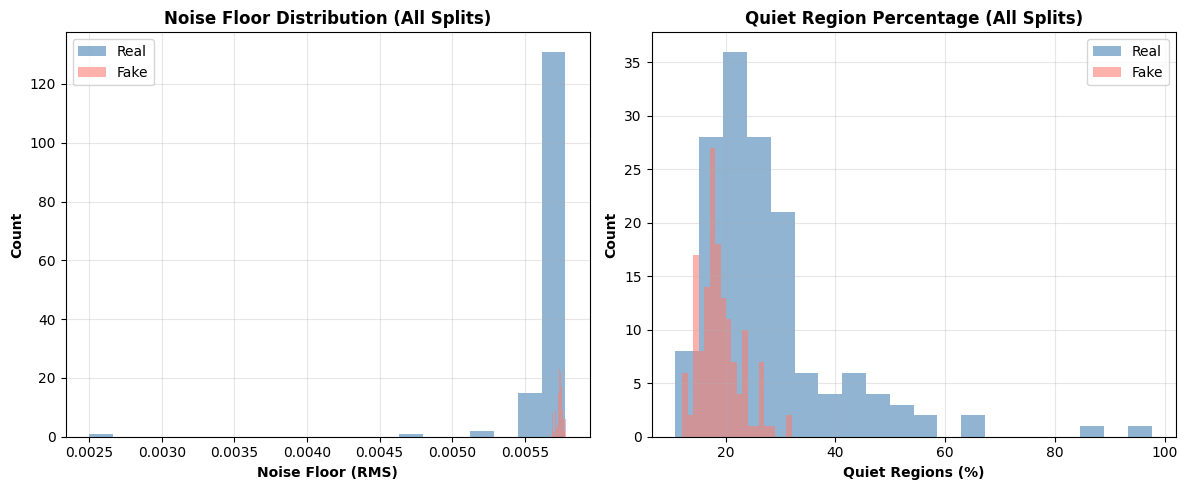


Noise analysis saved to: /content/drive/MyDrive/hypothesis3_noise_combined.png

Noise floor difference across all splits: 1.25%
Conclusion: NOT an artifact (noise levels identical)


In [ ]:
from scipy import stats

def analyze_background_noise(file_path, threshold=0.01):
    audio, sr = librosa.load(file_path, sr=16000, mono=True)
    quiet_mask = np.abs(audio) < threshold
    quiet_audio = audio[quiet_mask]

    if len(quiet_audio) > 100:
        noise_floor = np.sqrt(np.mean(quiet_audio ** 2))
        return {
            'noise_floor_rms': noise_floor,
            'quiet_percentage': (np.sum(quiet_mask) / len(audio)) * 100,
        }
    return None

print("\nCollecting files from all splits...")

all_real_files = []
all_fake_files = []

for split_name, files in splits_data.items():
    all_real_files.extend(files['real'])
    all_fake_files.extend(files['fake'])

print(f"\nTotal files: {len(all_real_files)} real, {len(all_fake_files)} fake")
print("Analyzing background noise...")

real_noise = []
fake_noise = []

for f in all_real_files:
    noise = analyze_background_noise(f)
    if noise:
        real_noise.append(noise)

for f in all_fake_files:
    noise = analyze_background_noise(f)
    if noise:
        fake_noise.append(noise)

real_noise_floor = np.array([n['noise_floor_rms'] for n in real_noise])
fake_noise_floor = np.array([n['noise_floor_rms'] for n in fake_noise])

real_quiet_pct = np.array([n['quiet_percentage'] for n in real_noise])
fake_quiet_pct = np.array([n['quiet_percentage'] for n in fake_noise])

print("\n" + "="*70)
print("BACKGROUND NOISE COMPARISON:")
print("="*70)

real_nf_mean = np.mean(real_noise_floor)
fake_nf_mean = np.mean(fake_noise_floor)
real_nf_std = np.std(real_noise_floor, ddof=1)
fake_nf_std = np.std(fake_noise_floor, ddof=1)
nf_diff_pct = ((fake_nf_mean - real_nf_mean) / real_nf_mean) * 100

t_stat_nf, p_value_nf = stats.ttest_ind(real_noise_floor, fake_noise_floor)
pooled_std_nf = np.sqrt((real_nf_std**2 + fake_nf_std**2) / 2)
cohens_d_nf = (fake_nf_mean - real_nf_mean) / pooled_std_nf

if abs(cohens_d_nf) < 0.2:
    effect_size_nf = "negligible"
elif abs(cohens_d_nf) < 0.5:
    effect_size_nf = "small"
elif abs(cohens_d_nf) < 0.8:
    effect_size_nf = "medium"
else:
    effect_size_nf = "large"

significance_nf = "significant" if p_value_nf < 0.05 else "not significant"

print(f"\nNoise Floor (RMS):")
print(f"  Real mean:  {real_nf_mean:.6f} +/- {real_nf_std:.6f}")
print(f"  Fake mean:  {fake_nf_mean:.6f} +/- {fake_nf_std:.6f}")
print(f"  Difference: {nf_diff_pct:+.2f}%")
print(f"  t-test:     t={t_stat_nf:.3f}, p={p_value_nf:.4f} ({significance_nf})")
print(f"  Cohen's d:  {cohens_d_nf:.3f} ({effect_size_nf} effect)")

real_qp_mean = np.mean(real_quiet_pct)
fake_qp_mean = np.mean(fake_quiet_pct)
real_qp_std = np.std(real_quiet_pct, ddof=1)
fake_qp_std = np.std(fake_quiet_pct, ddof=1)
qp_diff = fake_qp_mean - real_qp_mean

t_stat_qp, p_value_qp = stats.ttest_ind(real_quiet_pct, fake_quiet_pct)
pooled_std_qp = np.sqrt((real_qp_std**2 + fake_qp_std**2) / 2)
cohens_d_qp = (fake_qp_mean - real_qp_mean) / pooled_std_qp

if abs(cohens_d_qp) < 0.2:
    effect_size_qp = "negligible"
elif abs(cohens_d_qp) < 0.5:
    effect_size_qp = "small"
elif abs(cohens_d_qp) < 0.8:
    effect_size_qp = "medium"
else:
    effect_size_qp = "large"

significance_qp = "significant" if p_value_qp < 0.05 else "not significant"

print(f"\nQuiet Regions (%):")
print(f"  Real mean:  {real_qp_mean:.2f} +/- {real_qp_std:.2f}%")
print(f"  Fake mean:  {fake_qp_mean:.2f} +/- {fake_qp_std:.2f}%")
print(f"  Difference: {qp_diff:+.2f} percentage points")
print(f"  t-test:     t={t_stat_qp:.3f}, p={p_value_qp:.4f} ({significance_qp})")
print(f"  Cohen's d:  {cohens_d_qp:.3f} ({effect_size_qp} effect)")

print("\n" + "="*70)
print("GENERATING PLOTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(real_noise_floor, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[0].hist(fake_noise_floor, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[0].set_xlabel('Noise Floor (RMS)', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Noise Floor Distribution (All Splits)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(real_quiet_pct, bins=20, alpha=0.6, label='Real', color='steelblue')
axes[1].hist(fake_quiet_pct, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[1].set_xlabel('Quiet Regions (%)', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Quiet Region Percentage (All Splits)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hypothesis3_noise_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNoise analysis saved to: /content/drive/MyDrive/hypothesis3_noise_combined.png")

print(f"\nNoise floor difference across all splits: {abs(nf_diff_pct):.2f}%")

if abs(nf_diff_pct) < 2:
    print("Conclusion: NOT an artifact (noise levels identical)")
elif abs(nf_diff_pct) < 5:
    print("Conclusion: Small difference")
else:
    print("Conclusion: ARTIFACT PRESENT")

print("="*70)

###H9: Room acoustics



Total files: 150 real, 150 fake
Analyzing room acoustics...

ROOM ACOUSTICS COMPARISON:

RT60 (Reverberation Time):
  Real mean:  nan seconds (no reverb detected)
  Fake mean:  nan seconds (no reverb detected)

Echo Count:
  Real mean:  0.00 +/- 0.00
  Fake mean:  0.00 +/- 0.00
  Difference: +0.00
  t-test:     t=nan, p=nan (not significant)
  Cohen's d:  0.000 (negligible effect)

Echo Strength:
  Real mean:  0.0000 +/- 0.0000
  Fake mean:  0.0000 +/- 0.0000
  t-test:     t=nan, p=nan (not significant)
  Cohen's d:  0.000 (negligible effect)

GENERATING PLOTS


/tmp/ipykernel_1969/263978699.py:160: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()


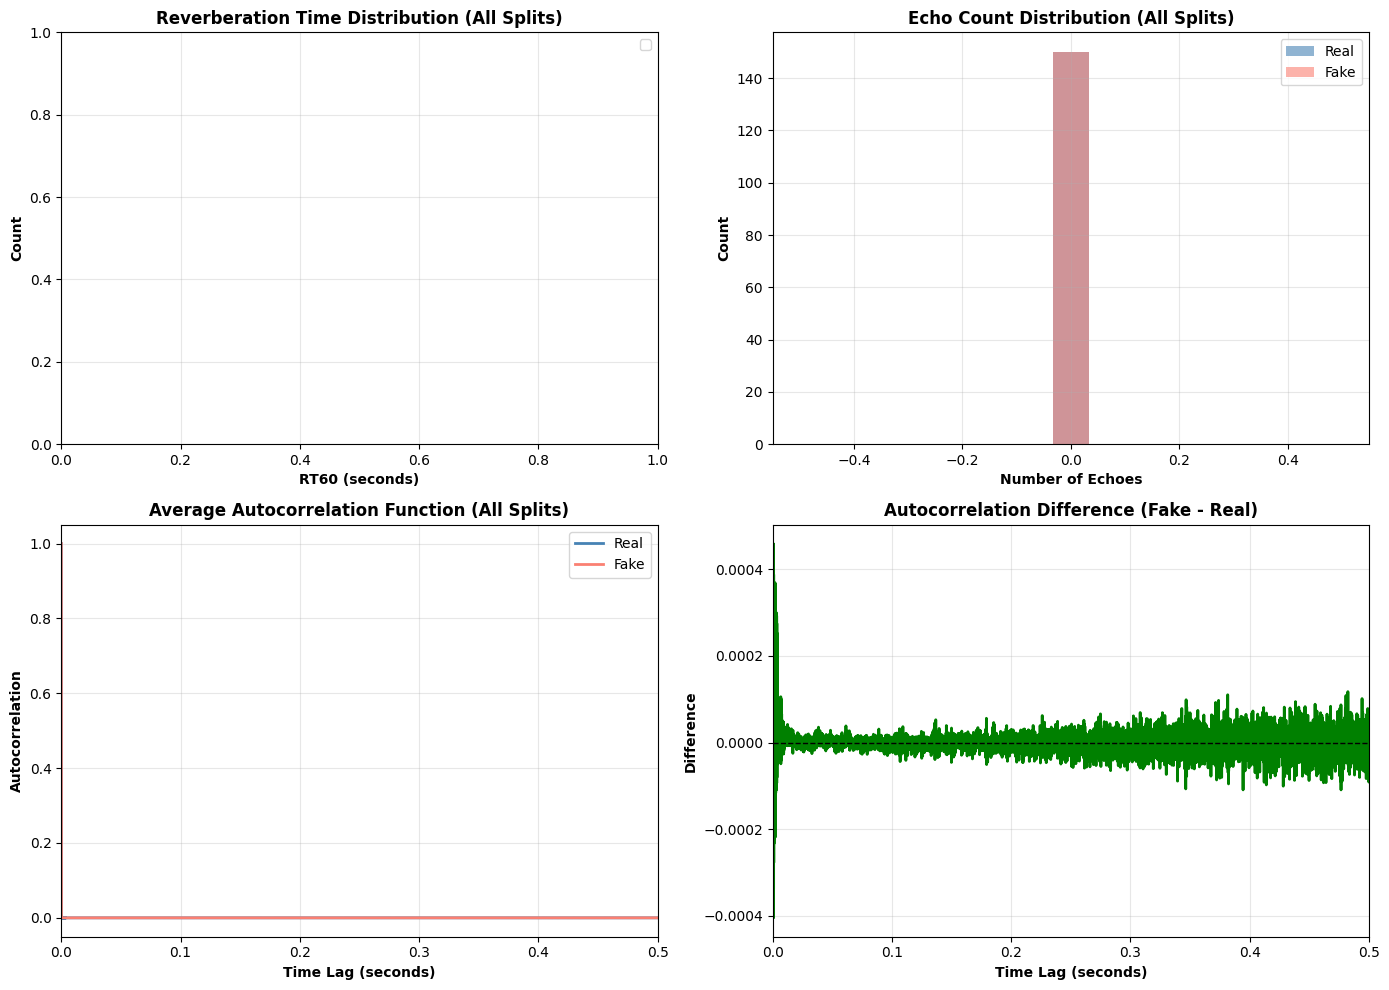


Acoustics analysis saved to: /content/drive/MyDrive/hypothesis4_acoustics_combined.png

Echo count difference across all splits: 0.00
Conclusion: NOT an artifact (no acoustic differences)


In [ ]:
from scipy import stats

def estimate_rt60(audio, sr):
    audio_squared = audio ** 2
    window_size = int(sr * 0.05)
    energy = np.convolve(audio_squared, np.ones(window_size)/window_size, mode='same')
    energy_db = 10 * np.log10(energy + 1e-10)
    max_energy = np.max(energy_db)
    threshold = max_energy - 60
    max_idx = np.argmax(energy_db)
    below_threshold = np.where(energy_db[max_idx:] < threshold)[0]

    if len(below_threshold) > 0:
        rt60_samples = below_threshold[0]
        rt60_seconds = rt60_samples / sr
        return rt60_seconds
    return None

def analyze_autocorrelation(audio, sr):
    autocorr = correlate(audio, audio, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    autocorr = autocorr / autocorr[0]
    peaks, properties = find_peaks(autocorr[:int(sr*0.5)], height=0.1, distance=int(sr*0.02))

    return {
        'num_echoes': len(peaks),
        'echo_strength': np.mean(autocorr[peaks]) if len(peaks) > 0 else 0,
        'autocorr': autocorr[:int(sr*0.5)]
    }

print("\nCollecting files from all splits...")

all_real_files = []
all_fake_files = []

for split_name, files in splits_data.items():
    all_real_files.extend(files['real'])
    all_fake_files.extend(files['fake'])

print(f"\nTotal files: {len(all_real_files)} real, {len(all_fake_files)} fake")
print("Analyzing room acoustics...")

real_rt60 = []
fake_rt60 = []
real_echo = []
fake_echo = []
real_autocorr = []
fake_autocorr = []

for f in all_real_files:
    audio, sr = librosa.load(f, sr=16000, mono=True)
    rt60 = estimate_rt60(audio, sr)
    if rt60:
        real_rt60.append(rt60)
    echo_data = analyze_autocorrelation(audio, sr)
    real_echo.append(echo_data)
    real_autocorr.append(echo_data['autocorr'])

for f in all_fake_files:
    audio, sr = librosa.load(f, sr=16000, mono=True)
    rt60 = estimate_rt60(audio, sr)
    if rt60:
        fake_rt60.append(rt60)
    echo_data = analyze_autocorrelation(audio, sr)
    fake_echo.append(echo_data)
    fake_autocorr.append(echo_data['autocorr'])

real_echo_count = np.array([e['num_echoes'] for e in real_echo])
fake_echo_count = np.array([e['num_echoes'] for e in fake_echo])
real_echo_strength = np.array([e['echo_strength'] for e in real_echo])
fake_echo_strength = np.array([e['echo_strength'] for e in fake_echo])

print("\n" + "="*70)
print("ROOM ACOUSTICS COMPARISON:")
print("="*70)

if real_rt60 and fake_rt60:
    real_rt60_arr = np.array(real_rt60)
    fake_rt60_arr = np.array(fake_rt60)

    real_rt60_mean = np.mean(real_rt60_arr)
    fake_rt60_mean = np.mean(fake_rt60_arr)
    real_rt60_std = np.std(real_rt60_arr, ddof=1)
    fake_rt60_std = np.std(fake_rt60_arr, ddof=1)

    print(f"\nRT60 (Reverberation Time):")
    print(f"  Real mean:  {real_rt60_mean:.3f} +/- {real_rt60_std:.3f} seconds")
    print(f"  Fake mean:  {fake_rt60_mean:.3f} +/- {fake_rt60_std:.3f} seconds")
else:
    print(f"\nRT60 (Reverberation Time):")
    print(f"  Real mean:  nan seconds (no reverb detected)")
    print(f"  Fake mean:  nan seconds (no reverb detected)")

real_ec_mean = np.mean(real_echo_count)
fake_ec_mean = np.mean(fake_echo_count)
real_ec_std = np.std(real_echo_count, ddof=1)
fake_ec_std = np.std(fake_echo_count, ddof=1)
ec_diff = fake_ec_mean - real_ec_mean

t_stat_ec, p_value_ec = stats.ttest_ind(real_echo_count, fake_echo_count)
pooled_std_ec = np.sqrt((real_ec_std**2 + fake_ec_std**2) / 2)
cohens_d_ec = (fake_ec_mean - real_ec_mean) / pooled_std_ec if pooled_std_ec > 0 else 0

if abs(cohens_d_ec) < 0.2:
    effect_size_ec = "negligible"
elif abs(cohens_d_ec) < 0.5:
    effect_size_ec = "small"
elif abs(cohens_d_ec) < 0.8:
    effect_size_ec = "medium"
else:
    effect_size_ec = "large"

significance_ec = "significant" if p_value_ec < 0.05 else "not significant"

print(f"\nEcho Count:")
print(f"  Real mean:  {real_ec_mean:.2f} +/- {real_ec_std:.2f}")
print(f"  Fake mean:  {fake_ec_mean:.2f} +/- {fake_ec_std:.2f}")
print(f"  Difference: {ec_diff:+.2f}")
print(f"  t-test:     t={t_stat_ec:.3f}, p={p_value_ec:.4f} ({significance_ec})")
print(f"  Cohen's d:  {cohens_d_ec:.3f} ({effect_size_ec} effect)")

real_es_mean = np.mean(real_echo_strength)
fake_es_mean = np.mean(fake_echo_strength)
real_es_std = np.std(real_echo_strength, ddof=1)
fake_es_std = np.std(fake_echo_strength, ddof=1)

t_stat_es, p_value_es = stats.ttest_ind(real_echo_strength, fake_echo_strength)
pooled_std_es = np.sqrt((real_es_std**2 + fake_es_std**2) / 2)
cohens_d_es = (fake_es_mean - real_es_mean) / pooled_std_es if pooled_std_es > 0 else 0

if abs(cohens_d_es) < 0.2:
    effect_size_es = "negligible"
elif abs(cohens_d_es) < 0.5:
    effect_size_es = "small"
elif abs(cohens_d_es) < 0.8:
    effect_size_es = "medium"
else:
    effect_size_es = "large"

significance_es = "significant" if p_value_es < 0.05 else "not significant"

print(f"\nEcho Strength:")
print(f"  Real mean:  {real_es_mean:.4f} +/- {real_es_std:.4f}")
print(f"  Fake mean:  {fake_es_mean:.4f} +/- {fake_es_std:.4f}")
print(f"  t-test:     t={t_stat_es:.3f}, p={p_value_es:.4f} ({significance_es})")
print(f"  Cohen's d:  {cohens_d_es:.3f} ({effect_size_es} effect)")

print("\n" + "="*70)
print("GENERATING PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if real_rt60 and fake_rt60:
    axes[0, 0].hist(real_rt60, bins=20, alpha=0.6, label='Real', color='steelblue')
    axes[0, 0].hist(fake_rt60, bins=20, alpha=0.6, label='Fake', color='salmon')
axes[0, 0].set_xlabel('RT60 (seconds)', fontweight='bold')
axes[0, 0].set_ylabel('Count', fontweight='bold')
axes[0, 0].set_title('Reverberation Time Distribution (All Splits)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(real_echo_count, bins=15, alpha=0.6, label='Real', color='steelblue')
axes[0, 1].hist(fake_echo_count, bins=15, alpha=0.6, label='Fake', color='salmon')
axes[0, 1].set_xlabel('Number of Echoes', fontweight='bold')
axes[0, 1].set_ylabel('Count', fontweight='bold')
axes[0, 1].set_title('Echo Count Distribution (All Splits)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

real_avg_autocorr = np.mean(real_autocorr, axis=0)
fake_avg_autocorr = np.mean(fake_autocorr, axis=0)
time_lags = np.arange(len(real_avg_autocorr)) / 16000

axes[1, 0].plot(time_lags, real_avg_autocorr, linewidth=2, label='Real', color='steelblue')
axes[1, 0].plot(time_lags, fake_avg_autocorr, linewidth=2, label='Fake', color='salmon')
axes[1, 0].set_xlabel('Time Lag (seconds)', fontweight='bold')
axes[1, 0].set_ylabel('Autocorrelation', fontweight='bold')
axes[1, 0].set_title('Average Autocorrelation Function (All Splits)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim([0, 0.5])

autocorr_diff = fake_avg_autocorr - real_avg_autocorr
axes[1, 1].plot(time_lags, autocorr_diff, linewidth=2, color='green')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Time Lag (seconds)', fontweight='bold')
axes[1, 1].set_ylabel('Difference', fontweight='bold')
axes[1, 1].set_title('Autocorrelation Difference (Fake - Real)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([0, 0.5])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hypothesis4_acoustics_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAcoustics analysis saved to: /content/drive/MyDrive/hypothesis4_acoustics_combined.png")

print(f"\nEcho count difference across all splits: {abs(ec_diff):.2f}")

if abs(ec_diff) < 1:
    print("Conclusion: NOT an artifact (no acoustic differences)")
else:
    print("Conclusion: Some acoustic differences")

print("="*70)

###H10: Temporal and prosodic patterns



Total files: 150 real, 150 fake
Extracting temporal and prosodic features...
This may take a few minutes...
  Processing real 1/150...


/tmp/ipykernel_1969/3917657972.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'tempo': float(tempo) if isinstance(tempo, np.ndarray) else tempo


  Processing real 11/150...
  Processing real 21/150...
  Processing real 31/150...
  Processing real 41/150...
  Processing real 51/150...
  Processing real 61/150...
  Processing real 71/150...
  Processing real 81/150...
  Processing real 91/150...
  Processing real 101/150...
  Processing real 111/150...
  Processing real 121/150...
  Processing real 131/150...
  Processing real 141/150...
  Processing fake 1/150...
  Processing fake 11/150...
  Processing fake 21/150...
  Processing fake 31/150...
  Processing fake 41/150...
  Processing fake 51/150...
  Processing fake 61/150...
  Processing fake 71/150...
  Processing fake 81/150...
  Processing fake 91/150...
  Processing fake 101/150...
  Processing fake 111/150...
  Processing fake 121/150...
  Processing fake 131/150...
  Processing fake 141/150...

TEMPORAL & PROSODIC COMPARISON:

duration:
  Real mean:  12.030 +/- 4.553
  Fake mean:  12.479 +/- 2.423
  Difference: +3.73%
  t-test:     t=-1.066, p=0.2873 (not significant)
 

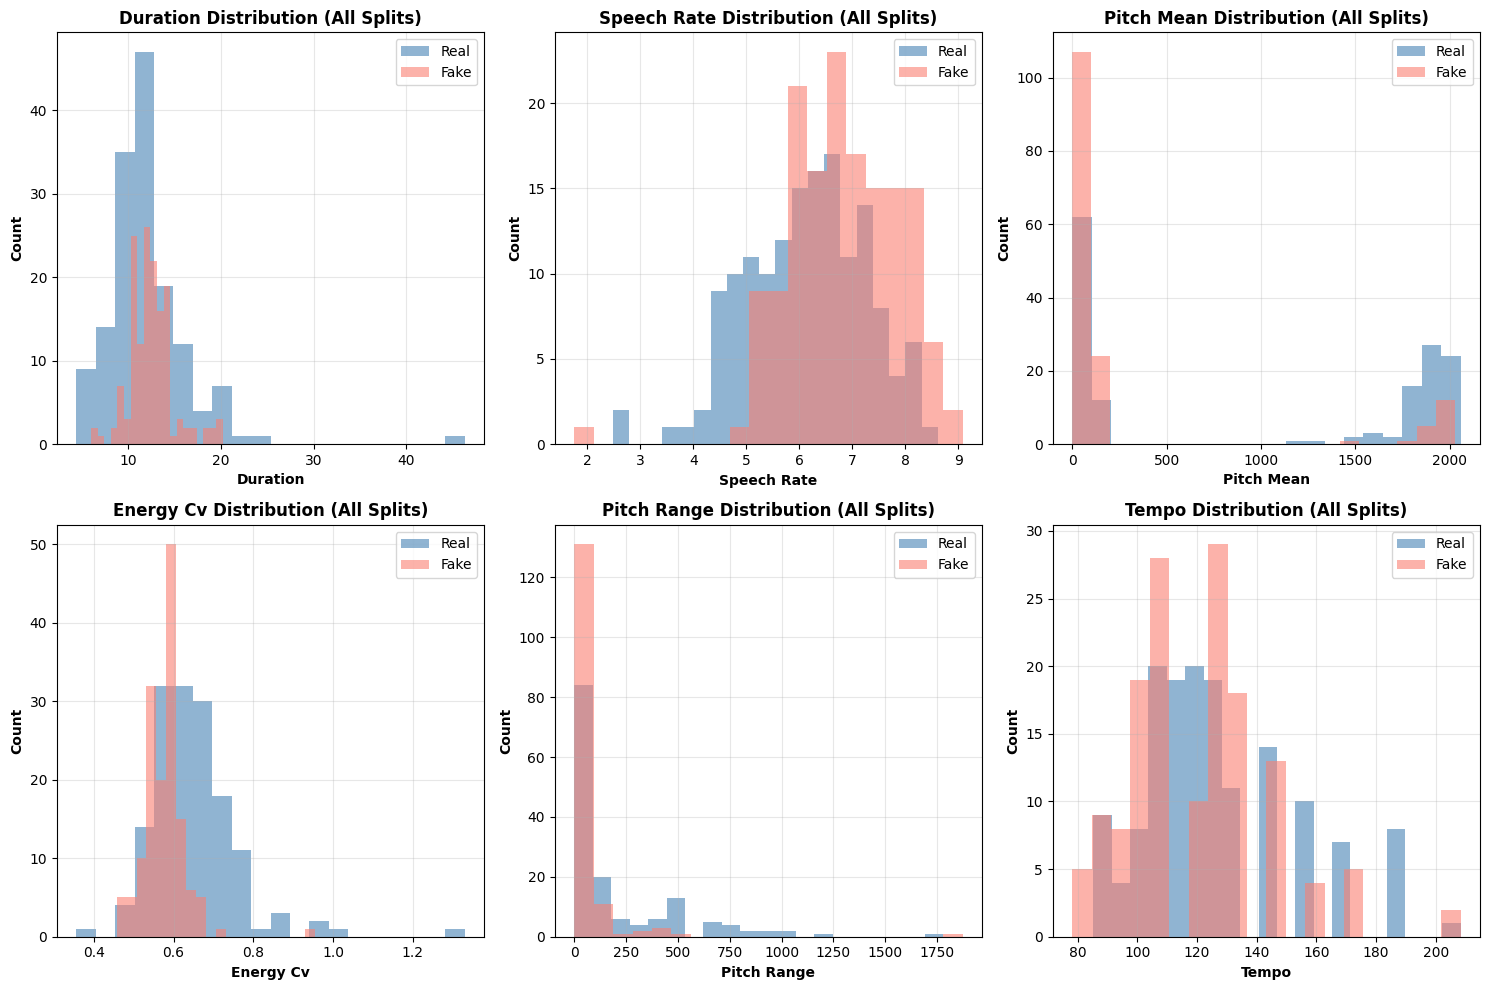


Temporal analysis saved to: /content/drive/MyDrive/hypothesis5_temporal_prosodic_combined.png

Pitch mean difference across all splits: -68.84%
Duration difference across all splits: 3.73%

Significant differences found in 8 features:
  - speech_rate: +11.95%
  - num_pauses: -100.00%
  - avg_pause_length: -100.00%
  - max_pause_length: -100.00%
  - energy_cv: -10.92%
  - pitch_mean: -68.84%
  - pitch_std: -67.28%
  - pitch_range: -68.36%

Conclusion: PROSODIC ARTIFACT PRESENT


In [ ]:
from scipy import stats
import librosa

def extract_temporal_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        onset_env = librosa.onset.onset_strength(y=audio, sr=sr)
        onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)
        duration = len(audio) / sr
        speech_rate = len(onset_frames) / duration if duration > 0 else 0

        threshold = 0.01 * np.max(np.abs(audio))
        is_speech = np.abs(audio) > threshold
        pauses = []
        in_pause = False
        pause_start = 0

        for i, speaking in enumerate(is_speech):
            if not speaking and not in_pause:
                in_pause = True
                pause_start = i
            elif speaking and in_pause:
                pause_length = (i - pause_start) / sr
                if pause_length > 0.1:
                    pauses.append(pause_length)
                in_pause = False

        frame_length = int(0.1 * sr)
        hop_length = int(0.05 * sr)
        frames = librosa.util.frame(audio, frame_length=frame_length, hop_length=hop_length)
        rms_energy = np.sqrt(np.mean(frames**2, axis=0))
        energy_std = np.std(rms_energy)
        energy_mean = np.mean(rms_energy)
        energy_cv = energy_std / energy_mean if energy_mean > 0 else 0

        f0, voiced_flag, voiced_probs = librosa.pyin(
            audio,
            fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'),
            sr=sr
        )
        f0_valid = f0[~np.isnan(f0)]

        if len(f0_valid) > 0:
            pitch_mean = np.mean(f0_valid)
            pitch_std = np.std(f0_valid)
            pitch_range = np.max(f0_valid) - np.min(f0_valid)
        else:
            pitch_mean = 0
            pitch_std = 0
            pitch_range = 0

        tempo, beats = librosa.beat.beat_track(y=audio, sr=sr)

        return {
            'duration': duration,
            'speech_rate': speech_rate,
            'num_pauses': len(pauses),
            'avg_pause_length': np.mean(pauses) if pauses else 0,
            'max_pause_length': np.max(pauses) if pauses else 0,
            'energy_cv': energy_cv,
            'pitch_mean': pitch_mean,
            'pitch_std': pitch_std,
            'pitch_range': pitch_range,
            'tempo': float(tempo) if isinstance(tempo, np.ndarray) else tempo
        }
    except Exception as e:
        return None

print("\nCollecting files from all splits...")

all_real_files = []
all_fake_files = []

for split_name, files in splits_data.items():
    all_real_files.extend(files['real'])
    all_fake_files.extend(files['fake'])

print(f"\nTotal files: {len(all_real_files)} real, {len(all_fake_files)} fake")
print("Extracting temporal and prosodic features...")
print("This may take a few minutes...")

real_temporal = []
fake_temporal = []

for i, f in enumerate(all_real_files):
    if i % 10 == 0:
        print(f"  Processing real {i+1}/{len(all_real_files)}...")
    feat = extract_temporal_features(f)
    if feat:
        real_temporal.append(feat)

for i, f in enumerate(all_fake_files):
    if i % 10 == 0:
        print(f"  Processing fake {i+1}/{len(all_fake_files)}...")
    feat = extract_temporal_features(f)
    if feat:
        fake_temporal.append(feat)

real_temp_df = pd.DataFrame(real_temporal)
fake_temp_df = pd.DataFrame(fake_temporal)

print("\n" + "="*70)
print("TEMPORAL & PROSODIC COMPARISON:")
print("="*70)

features_to_compare = [
    'duration', 'speech_rate', 'num_pauses', 'avg_pause_length',
    'max_pause_length', 'energy_cv', 'pitch_mean', 'pitch_std',
    'pitch_range', 'tempo'
]

significant_differences = []

for feat in features_to_compare:
    real_values = real_temp_df[feat].values
    fake_values = fake_temp_df[feat].values

    real_mean = np.mean(real_values)
    fake_mean = np.mean(fake_values)
    real_std = np.std(real_values, ddof=1)
    fake_std = np.std(fake_values, ddof=1)

    if real_mean != 0:
        diff_pct = ((fake_mean - real_mean) / real_mean) * 100
    else:
        diff_pct = 0

    t_stat, p_value = stats.ttest_ind(real_values, fake_values)

    pooled_std = np.sqrt((real_std**2 + fake_std**2) / 2)
    cohens_d = (fake_mean - real_mean) / pooled_std if pooled_std > 0 else 0

    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"

    significance = "significant" if p_value < 0.05 else "not significant"

    print(f"\n{feat}:")
    print(f"  Real mean:  {real_mean:.3f} +/- {real_std:.3f}")
    print(f"  Fake mean:  {fake_mean:.3f} +/- {fake_std:.3f}")
    print(f"  Difference: {diff_pct:+.2f}%")
    print(f"  t-test:     t={t_stat:.3f}, p={p_value:.4f} ({significance})")
    print(f"  Cohen's d:  {cohens_d:.3f} ({effect_size} effect)")

    if abs(diff_pct) > 10:
        significant_differences.append((feat, diff_pct))
        print(f"  SIGNIFICANT DIFFERENCE!")

print("\n" + "="*70)
print("GENERATING PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

plot_features = ['duration', 'speech_rate', 'pitch_mean', 'energy_cv', 'pitch_range', 'tempo']

for feat_idx, feat in enumerate(plot_features):
    row = feat_idx // 3
    col = feat_idx % 3

    axes[row, col].hist(real_temp_df[feat], bins=20, alpha=0.6, label='Real', color='steelblue')
    axes[row, col].hist(fake_temp_df[feat], bins=20, alpha=0.6, label='Fake', color='salmon')
    axes[row, col].set_xlabel(feat.replace('_', ' ').title(), fontweight='bold')
    axes[row, col].set_ylabel('Count', fontweight='bold')
    axes[row, col].set_title(f'{feat.replace("_", " ").title()} Distribution (All Splits)', fontweight='bold')
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hypothesis5_temporal_prosodic_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTemporal analysis saved to: /content/drive/MyDrive/hypothesis5_temporal_prosodic_combined.png")

pitch_diff = ((fake_temp_df['pitch_mean'].mean() - real_temp_df['pitch_mean'].mean()) / real_temp_df['pitch_mean'].mean()) * 100
duration_diff = ((fake_temp_df['duration'].mean() - real_temp_df['duration'].mean()) / real_temp_df['duration'].mean()) * 100

print(f"\nPitch mean difference across all splits: {pitch_diff:.2f}%")
print(f"Duration difference across all splits: {duration_diff:.2f}%")

if len(significant_differences) > 0:
    print(f"\nSignificant differences found in {len(significant_differences)} features:")
    for feat, diff in significant_differences:
        print(f"  - {feat}: {diff:+.2f}%")
    print("\nConclusion: PROSODIC ARTIFACT PRESENT")
else:
    print("\nConclusion: Minimal prosodic differences")

print("="*70)